## Figure 2b, 5
## Supplementary Figure 1a-c, e, f, 11

## Helper codes: run below cells before any of the other cells. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as patches

from scipy.stats import linregress, nbinom, poisson, norm, sem, wilcoxon, spearmanr, mannwhitneyu, gamma, pearsonr, lognorm, binom, gmean, rankdata
from scipy.optimize import minimize
from scipy.special import factorial, gamma
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson, GeneralizedPoisson
from statsmodels.distributions.discrete import genpoisson_p
import pickle
import joblib
from copy import deepcopy as dc
import math
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
import seaborn as sns

from umap import UMAP
import networkx as nx
from statsmodels.stats.multitest import multipletests
import pingouin as pg
from itertools import combinations
import warnings
from time import time

c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# loading variables

# ABO Neuropixels
with open('resp_matrix_ep_RS_all_32sess_allensdk.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_RS = resp_matrix_ep_RS_all['list_rate_RS'].copy()
    list_rate_RS_dr = resp_matrix_ep_RS_all['list_rate_RS_dr'].copy()
    list_rate_all = resp_matrix_ep_RS_all['list_rate_all'].copy()
    list_rate_all_dr = resp_matrix_ep_RS_all['list_rate_all_dr'].copy()
    list_slopes_RS_an_loglog = resp_matrix_ep_RS_all['list_slopes_RS_an_loglog'].copy()
    list_slopes_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_all_att_loglog'].copy()
    list_slopes_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_all_an_loglog'].copy()
    list_slopes_stat_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_stat_all_an_loglog'].copy()
    list_slopes_mov_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_mov_all_an_loglog'].copy()
    list_slopes_all_att_loglog_RRneuron = resp_matrix_ep_RS_all['list_slopes_all_att_loglog_RRneuron'].copy()
    list_slopes_all_an_loglog_RRneuron = resp_matrix_ep_RS_all['list_slopes_all_an_loglog_RRneuron'].copy()

    sess_inds_qual_RS = resp_matrix_ep_RS_all['sess_inds_qual_RS'].copy()
    sess_inds_qual_RS_dr = resp_matrix_ep_RS_all['sess_inds_qual_RS_dr'].copy()
    sess_inds_qual_all = resp_matrix_ep_RS_all['sess_inds_qual_all'].copy()
    sess_inds_qual_all_dr = resp_matrix_ep_RS_all['sess_inds_qual_all_dr'].copy()

    # print(resp_matrix_ep_RS_all['tree_variables'])

with open('invalid_unit_sess.pickle', 'rb') as f:
    invalid_unit_sess = pickle.load(f)

    list_invalid_units_visp = invalid_unit_sess['list_invalid_units_visp'].copy()
    list_invalid_units_HVA = invalid_unit_sess['list_invalid_units_HVA'].copy()
    list_invalid_sess_visp = invalid_unit_sess['list_invalid_sess_visp'].copy()
    list_invalid_sess_HVA = invalid_unit_sess['list_invalid_sess_HVA'].copy()
    sess_inds_mapBO = invalid_unit_sess['sess_inds_mapBO'].copy()

In [3]:
def compute_mean_var_trial(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1)
        trial_var = np.var(trial_rate, axis=1, ddof=1)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = pd.concat([trial_mean] * label_cnt_dict[trial_type], axis=1)
        list_trial_var[trial_ind] = pd.concat([trial_var] * label_cnt_dict[trial_type], axis=1)

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [4]:
def compute_mean_var_trial_collapse(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = trial_mean.copy()
        list_trial_var[trial_ind] = trial_var.copy()

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [5]:
# %%
# Function to compute cosine similarity
def cos_sim(x, y):
    # x and y are 1D vectors

    # Remove NaN
    x, y = np.array(x), np.array(y)
    bool_notnan = np.logical_and(~np.isnan(x), ~np.isnan(y))
    x, y = x[bool_notnan].copy(), y[bool_notnan].copy()

    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

In [6]:
def annotate_lineplot_significance(significant_values, axes, ax_ind, line_height_ratio, color):

    if len(significant_values) > 0:

        # Initialize start and end points of lines
        start = None
        lines = []
        dots = []

        # Loop through sorted significant_values to group them into lines or dots
        for i in range(len(significant_values) - 1):
            if start is None:
                start = significant_values[i]

            # Check if the next value is part of the same line
            if significant_values[i + 1] - significant_values[i] > 0.1 + 1e-9:  # Threshold for a gap; add pseudo-value to avoid floating point issue
                if start == significant_values[i]:
                    dots.append(start)  # Isolated point
                else:
                    lines.append((start, significant_values[i]))  # Line segment
                start = None

        # Check the last value
        if start is None:
            dots.append(significant_values[-1])
        else:
            lines.append((start, significant_values[-1]))

        # Plot lines and dots
        for line in lines:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)  # Draw a line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
                
        for dot in dots:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)  # Draw a very short line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)

In [7]:
def get_upper_whisker(data, whis=1.5):
    """Calculates the top of the upper whisker (ignoring hidden outliers)."""
    data = np.array(data)
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    upper_bound = q3 + whis * iqr
    valid_points = data[data <= upper_bound]
    
    return np.nanmax(valid_points) if len(valid_points) > 0 else np.nanmax(data)

def add_significance_bars(ax, comparisons, y_max_values, x_positions=None, p_values=None, colors=None,
                          gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, fontsize=10, ignore_ns=True):

    if p_values is None: p_values = ['*' for _ in comparisons]
    if x_positions is None: x_positions = np.arange(len(y_max_values))
    if colors is None: colors = ['k' for _ in comparisons]
    if ignore_ns:
        pval_thres = 0.05
    else:
        pval_thres = 1
    
    # Sort Comparisons: Distance first, then height
    def sort_key(item):
        (idx1, idx2), _ = item
        x_min, x_max = min(idx1, idx2), max(idx1, idx2)
        dist = x_max - x_min
        height = max(y_max_values[x_min : x_max + 1])
        return (dist, height)

    combined = list(zip(comparisons, p_values))
    combined.sort(key=sort_key)
    sorted_comparisons, sorted_p_values = zip(*combined)
    
    # Scale Factors
    y_min, y_max = np.nanmin(y_max_values), np.nanmax(y_max_values)
    y_range = y_max - y_min if y_max != y_min else 1.0

    # Get physical figure size in inches
    fig = ax.get_figure()
    fig_height_inch = fig.get_figheight()
    
    # Get axis height in fraction of figure (e.g., 0.8)
    bbox = ax.get_position()
    ax_height_inch = fig_height_inch * bbox.height

    # Get current Y-axis range (data units)
    y_min, y_max = ax.get_ylim()
    y_range_real = y_max - y_min

    # Conversion: (Points / 72 inch/pt) * (Data Range / Axis Height inches)
    text_height_data = (fontsize / 72) * (y_range_real / ax_height_inch)
    
    # Define gaps relative to the text size
    clearance = text_height_data * gap_below_line
    text_height = text_height_data
    
    # Initialize Interval Skyline
    # If we have N columns, we have N-1 gaps.
    n_columns = len(y_max_values)
    interval_skyline = [0] * (n_columns - 1)
    
    # Draw Bars
    for com_ind, ((idx1, idx2), pval) in enumerate(zip(sorted_comparisons, sorted_p_values)):
        if pval <= pval_thres:
            x1, x2 = min(idx1, idx2), max(idx1, idx2)
            
            # Check Data Height
            data_peak = np.nanmax(y_max_values[x1 : x2 + 1])
            
            # Check Interval Height
            if x1 < x2:
                interval_peak = np.nanmax(interval_skyline[x1:x2]) if interval_skyline[x1:x2] else 0
            else:
                interval_peak = 0
                
            # Determine drawing height
            # Must clear both the data and the previous bars below it
            y_line = np.nanmax([data_peak, interval_peak]) + clearance
            
            # if adjacent bars have same height, move up the second one
            if com_ind >= 1:
                idx1_prev, idx2_prev = sorted_comparisons[com_ind-1]
                x1_prev, x2_prev = min(idx1_prev, idx2_prev), max(idx1_prev, idx2_prev)
                pval_prev = sorted_p_values[com_ind-1]
                if x2 - x1 == 1 and x2_prev - x1_prev == 1 and x1 == x2_prev and pval_prev <= pval_thres:
                    y_line_prev = interval_skyline[x1_prev] - text_height
                    if np.isclose(y_line, y_line_prev):
                        y_line += clearance * bottomline_offset

            # Draw Line
            x_pos1, x_pos2 = x_positions[x1], x_positions[x2]
            line_x = [x_pos1, x_pos2]
            line_y = [y_line, y_line]
            ax.plot(line_x, line_y, lw=1.5, c=colors[com_ind])
        
            # Add Text
            text_y = y_line + (clearance * gap_below_text)
            if pval < 0.001:
                asterisk = '***'
            elif pval < 0.01:
                asterisk = '**'
            elif pval < 0.05:
                asterisk = '*'
            else:
                asterisk = f'p={pval:.2f}'
            ax.text((x_pos1 + x_pos2) * 0.5, text_y, asterisk, ha='center', va='bottom', color=colors[com_ind])
            
            # Update Interval Skyline
            new_height = y_line + text_height
            for k in range(x1, x2):
                interval_skyline[k] = new_height

    return ax

In [8]:
def heatmap_cbar(data, figsize_hm=(4, 4), figsize_all=(5, 4),
                 cmap="rocket", vmin=None, vmax=None, heatmap_kws=None, cbar_kws=None):
    """
    Make figsize=figsize_all where:
      - heatmap matches seaborn heatmap in figsize_hm with cbar=False
      - colorbar width + gap match seaborn heatmap in figsize_all with cbar=True
    """
    heatmap_kws = {} if heatmap_kws is None else dict(heatmap_kws)
    cbar_kws    = {} if cbar_kws is None else dict(cbar_kws)

    if vmin is None: vmin = np.nanmin(data)
    if vmax is None: vmax = np.nanmax(data)

    def bbox_in_inches(fig, ax):
        fig.canvas.draw()
        b = ax.get_position() # figure-fraction
        fw, fh = fig.get_size_inches()
        return (b.x0 * fw, b.y0 * fh, b.width * fw, b.height * fh)

    # Reference A: figsize_hm, cbar=False → heatmap axes box
    figA, axA = plt.subplots(figsize=figsize_hm)
    sns.heatmap(data, ax=axA, cbar=False, cmap=cmap, vmin=vmin, vmax=vmax, **heatmap_kws)
    hm_x0, hm_y0, hm_w, hm_h = bbox_in_inches(figA, axA)
    plt.close(figA)

    # Reference B: figsize_all, cbar=True → colorbar width + gap
    figB, axB = plt.subplots(figsize=figsize_all)
    hmB = sns.heatmap(data, ax=axB, cbar=True, cmap=cmap, vmin=vmin, vmax=vmax,
                      cbar_kws=cbar_kws, **heatmap_kws)
    caxB = hmB.figure.axes[-1]
    hmB_x0, hmB_y0, hmB_w, hmB_h = bbox_in_inches(figB, axB)
    cbB_x0, cbB_y0, cbB_w, cbB_h = bbox_in_inches(figB, caxB)
    gap = cbB_x0 - (hmB_x0 + hmB_w) # inches
    cbar_w = cbB_w # inches
    plt.close(figB)

    # Final: figsize_all with manual axes placement
    fig = plt.figure(figsize=figsize_all)
    fw, fh = fig.get_size_inches()

    ax_hm = fig.add_axes([hm_x0/fw, hm_y0/fh, hm_w/fw, hm_h/fh])

    cb_x0 = hm_x0 + hm_w + gap
    ax_cb = fig.add_axes([cb_x0/fw, hm_y0/fh, cbar_w/fw, hm_h/fh])

    sns.heatmap(data, ax=ax_hm, cbar=True, cbar_ax=ax_cb, cmap=cmap,
                vmin=vmin, vmax=vmax, cbar_kws=cbar_kws, **heatmap_kws)

    return fig, ax_hm, ax_cb

In [9]:
# # Collect sampled spike counts for each session (Gaussian copula)
# method = 'resc_r'
# n_samples = 50
# num_sess = 32
# use_rrep = False
# if not use_rrep: # one r for each combination of neuron and stimulus
#     method += '_rcomb'

# num_trial_types = 119

# list_rate_nb2 = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     file_name = 'rate_nb_copula_ABO_sep_' + method + '_' + str(n_samples) + 'samples_' + str(sess_ind) + '.pickle'
#     with open(file_name, 'rb') as f:
#         rate_nb_copula_ABO = pickle.load(f)
#         list_rate_nb2[sess_ind] = rate_nb_copula_ABO['list_rate_nb'].copy()

# save_file_name = 'rate_nb_copula_ABO_sep_' + method + '_' + str(n_samples) + 'samples_realR_all.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': 'list_rate_nb2', 'list_rate_nb2': list_rate_nb2}, f)

In [10]:
# # Collect sampled spike counts for each session (independent)
# n_samples = 50
# num_sess = 32

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_trial_types = 119

# list_rate_katz_asis = np.empty(num_sess, dtype=object)
# list_rate_katz_RRneuron2 = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     file_name = 'rate_katz_indep_ABO_sep_RRneuron_' + str(n_samples) + 'samples_' + str(sess_ind) + '.pickle'
#     with open(file_name, 'rb') as f:
#         rate_nb_indep_ABO = pickle.load(f)
#         list_rate_katz_asis[sess_ind] = rate_nb_indep_ABO['list_rate_katz_asis'].copy()
#         list_rate_katz_RRneuron2[sess_ind] = rate_nb_indep_ABO['list_rate_katz_RRneuron'].copy()

# save_file_name = 'rate_katz_indep_ABO_sep_RRneuron_' + str(n_samples) + 'samples_realR_all3.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_katz_asis', 'list_rate_katz_RRneuron2'],
#                  'list_rate_katz_asis': list_rate_katz_asis, 'list_rate_katz_RRneuron2': list_rate_katz_RRneuron2}, f)

## Codes for figures

## Figure 2b

In [11]:
# # Linear Fitting Slope across trial types (ABO Neuropixels all neurons) (loglog line) (residual-rescaled data)

# num_sess = 32
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# # Iterate over all sessions
# list_slopes_all_att_loglog_RRneuron = np.empty((num_sess, len(list_target_slopes)), dtype=object)
# for sess_ind, rate in enumerate(list_rate_all):
#     print(f'session index: {sess_ind}')
    
#     rate_sorted = rate.sort_index(axis=1)
#     stm = rate_sorted.columns.copy()

#     # Multiply by delta t to convert to spike counts
#     rate_sorted = rate_sorted * 0.25

#     # Create a counting dictionary for each stimulus
#     all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#     stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#     # Compute mean & variance for each stimulus
#     rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
#     rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

#     list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], columns=rate_sorted_mean_coll.columns)

#     # Convert 0 to NaN (verified that cases of mean=0 and var=0 coincide exactly)
#     rate_sorted_mean_coll[rate_sorted_mean_coll == 0] = np.nan
#     rate_sorted_var_coll[rate_sorted_var_coll == 0] = np.nan
        
#     for slope_ind, target_slope in enumerate(list_target_slopes):
#         # print(f'sess_ind: {sess_ind}, target slope {target_slope:.1f}')

#         # calculate target variance
#         var_estim_dr = pd.DataFrame(np.zeros((1, rate_sorted_var_coll.shape[1])), \
#                                 columns=rate_sorted_var_coll.columns)
#         for trial_type in rate_sorted_var_coll.columns:
#             var_estim_dr.loc[:, trial_type] = \
#                 np.nanmean(rate_sorted_var.loc[:, trial_type].values.flatten()) # nanmean
#         # var_estim_dr = np.repeat(var_estim_dr, all_stm_counts, axis=1)
#         # print(var_estim_dr)

#         # offset = var_estim_dr.div(rate_sorted_var_coll.pow(target_slope/list_slopes_dr.iloc[0, :], axis=1).mean(axis=0))\
#         # .mul(pow(10, target_slope * list_slopes_dr.iloc[1, :] / list_slopes_dr.iloc[0, :])) # collapsed
#         offset = pow(10, (list_slopes_dr.iloc[0, :]-target_slope) * np.nanmean(np.log10(rate_sorted_mean_coll), axis=0) + list_slopes_dr.iloc[1, :])

#         var_rs_noisy = \
#             pow(10, np.log10(rate_sorted_var_coll).sub(list_slopes_dr.iloc[1, :], axis=1)\
#                 .div(list_slopes_dr.iloc[0, :], axis=1).mul(target_slope).add(np.log10(np.array(offset)), axis=1)) # collapsed
#         var_rs_noisy = np.repeat(np.array(var_rs_noisy), all_stm_counts, axis=1)

#         # Compute changed residual and add back to the mean
#         rate_sorted_resid_dr = rate_sorted - rate_sorted_mean
#         # rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
#         #     .mul(np.sqrt(rate_sorted_mean)).mul(np.sqrt(FF_estim_dr), axis=1)
#         rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
#             .mul(np.sqrt(var_rs_noisy))
#         # print(rate_resid_RRneuron_dr)
#         rate_RRneuron_dr = rate_sorted_mean + rate_resid_RRneuron_dr
#         rate_RRneuron_dr[rate_RRneuron_dr.isna()] = 0 # convert NaN to 0!

#         # Compute mean and variance of slope-changed data
#         rate_mean_RRneuron_coll, rate_var_RRneuron_coll = \
#             compute_mean_var_trial_collapse(stm_cnt_dict, rate_RRneuron_dr)
#         rate_mean_RRneuron, rate_var_RRneuron = \
#             compute_mean_var_trial(stm_cnt_dict, rate_RRneuron_dr)        
                
#         # Calculate and collect linear slopes for all neurons
#         slopes = np.zeros((2, rate_mean_RRneuron_coll.shape[0]))
#         for neu_ind in rate_mean_RRneuron_coll.index:

#             # loglog scale
#             bool_mean_notzero = rate_mean_RRneuron_coll.loc[neu_ind] > 0
#             popt = np.polyfit(np.log10(rate_mean_RRneuron.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                 np.log10(rate_var_RRneuron.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
            
#             slopes[:, neu_ind] = popt.copy()
                
#         list_slopes_all_att_loglog_RRneuron[sess_ind, slope_ind] = slopes.copy()

In [12]:
# # Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (residual-rescaled data)

# num_sess = 32
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# # Iterate over all sessions
# list_slopes_all_an_loglog_RRneuron = np.empty((num_sess, len(list_target_slopes)), dtype=object)
# for sess_ind, rate in enumerate(list_rate_all):
#     print(f'session index: {sess_ind}')
    
#     rate_sorted = rate.sort_index(axis=1)
#     stm = rate_sorted.columns.copy()

#     # Multiply by delta t to convert to spike counts
#     rate_sorted = rate_sorted * 0.25

#     # Create a counting dictionary for each stimulus
#     all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#     stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#     # Compute mean & variance for each stimulus
#     rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
#     rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

#     list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], columns=rate_sorted_mean_coll.columns)

#     # Convert 0 to NaN (verified that cases of mean=0 and var=0 coincide exactly)
#     rate_sorted_mean_coll[rate_sorted_mean_coll == 0] = np.nan
#     rate_sorted_var_coll[rate_sorted_var_coll == 0] = np.nan
        
#     for slope_ind, target_slope in enumerate(list_target_slopes):
#         # print(f'sess_ind: {sess_ind}, target slope {target_slope:.1f}')

#         # calculate target variance
#         var_estim_dr = pd.DataFrame(np.zeros((1, rate_sorted_var_coll.shape[1])), \
#                                 columns=rate_sorted_var_coll.columns)
#         for trial_type in rate_sorted_var_coll.columns:
#             var_estim_dr.loc[:, trial_type] = \
#                 np.nanmean(rate_sorted_var.loc[:, trial_type].values.flatten()) # nanmean
#         # var_estim_dr = np.repeat(var_estim_dr, all_stm_counts, axis=1)
#         # print(var_estim_dr)

#         # offset = var_estim_dr.div(rate_sorted_var_coll.pow(target_slope/list_slopes_dr.iloc[0, :], axis=1).mean(axis=0))\
#         # .mul(pow(10, target_slope * list_slopes_dr.iloc[1, :] / list_slopes_dr.iloc[0, :])) # collapsed
#         offset = pow(10, (list_slopes_dr.iloc[0, :]-target_slope) * np.nanmean(np.log10(rate_sorted_mean_coll), axis=0) + list_slopes_dr.iloc[1, :])

#         var_rs_noisy = \
#             pow(10, np.log10(rate_sorted_var_coll).sub(list_slopes_dr.iloc[1, :], axis=1)\
#                 .div(list_slopes_dr.iloc[0, :], axis=1).mul(target_slope).add(np.log10(np.array(offset)), axis=1)) # collapsed
#         var_rs_noisy = np.repeat(np.array(var_rs_noisy), all_stm_counts, axis=1)

#         # Compute changed residual and add back to the mean            
#         rate_sorted_resid_dr = rate_sorted - rate_sorted_mean
#         # rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
#         #     .mul(np.sqrt(rate_sorted_mean)).mul(np.sqrt(FF_estim_dr), axis=1)
#         rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
#             .mul(np.sqrt(var_rs_noisy))
#         # print(rate_resid_RRneuron_dr)
#         rate_RRneuron_dr = rate_sorted_mean + rate_resid_RRneuron_dr
#         rate_RRneuron_dr[rate_RRneuron_dr.isna()] = 0 # convert NaN to 0!

#         # Compute mean and variance of slope-changed data
#         rate_mean_RRneuron_coll, rate_var_RRneuron_coll = \
#             compute_mean_var_trial_collapse(stm_cnt_dict, rate_RRneuron_dr)
#         rate_mean_RRneuron, rate_var_RRneuron = \
#             compute_mean_var_trial(stm_cnt_dict, rate_RRneuron_dr)        
                
#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_mean_RRneuron_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_mean_RRneuron_coll.columns):
#             # loglog scale
#             bool_mean_notzero = rate_mean_RRneuron_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_mean_RRneuron.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_var_RRneuron.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
#             slopes[:, trial_type_ind] = popt.copy()
                
#         list_slopes_all_an_loglog_RRneuron[sess_ind, slope_ind] = slopes.copy()

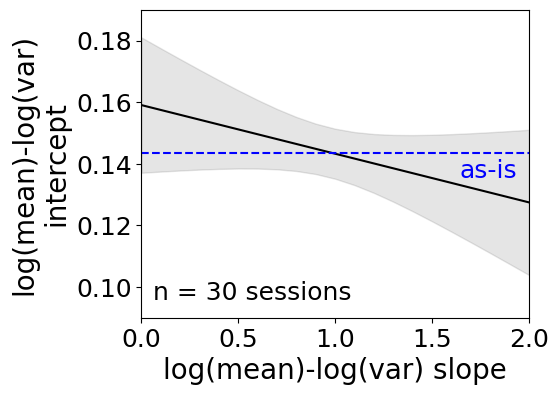

In [13]:
# intercept vs. slope (residual-rescaled data)
num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
list_intcpt_att_RRneuron2 = np.full((num_sess, len(list_target_slopes)), np.nan)
list_intcpt_an_RRneuron2 = np.full((num_sess, len(list_target_slopes)), np.nan)
for sess_ind in range(num_sess):
    for slope_ind in range(len(list_target_slopes)):
        list_intcpt_att_RRneuron2[sess_ind, slope_ind] = np.nanmean(list_slopes_all_att_loglog_RRneuron[sess_ind, slope_ind][1])
        list_intcpt_an_RRneuron2[sess_ind, slope_ind] = np.nanmean(list_slopes_all_an_loglog_RRneuron[sess_ind, slope_ind][1])
list_intcpt_att_asis = np.array([np.nanmean(slopes[1]) for slopes in list_slopes_all_att_loglog])
list_intcpt_an_asis = np.array([np.nanmean(slopes[1]) for slopes in list_slopes_all_an_loglog])

# exclude session 0, 6
bool_sess = ~np.isin(range(num_sess), [0, 6])
list_intcpt_att_asis = list_intcpt_att_asis[bool_sess]
list_intcpt_an_asis = list_intcpt_an_asis[bool_sess]
list_intcpt_att_RRneuron2 = list_intcpt_att_RRneuron2[bool_sess]
list_intcpt_an_RRneuron2 = list_intcpt_an_RRneuron2[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_intcpt = np.mean(list_intcpt_an_RRneuron2, axis=0)
list_errs_intcpt = sem(list_intcpt_an_RRneuron2, axis=0)

axes[0].plot(list_target_slopes, list_means_intcpt, color='k')
axes[0].fill_between(list_target_slopes, list_means_intcpt-list_errs_intcpt, list_means_intcpt+list_errs_intcpt, color='k', alpha=0.1)

# as-is average
axes[0].axhline(np.nanmean(list_intcpt_an_asis), color='b', linestyle='--')

# significance
list_pvals_intcpt = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_intcpt[slope_ind] = list(wilcoxon(list_intcpt_an_asis, list_intcpt_an_RRneuron2[:, slope_ind], nan_policy='omit'))[1]
list_pvals_intcpt = np.array(multipletests(list_pvals_intcpt, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_intcpt = list_target_slopes[list_pvals_intcpt < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_intcpt, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('log(mean)-log(var)\nintercept', fontsize=20)
axes[0].tick_params('both', labelsize=18)

axes[0].set_xlim(0, 2)
axes[0].set_ylim(0.09, 0.19)
height = (np.mean(list_intcpt_an_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
axes[0].annotate(f'n = {list_intcpt_an_RRneuron2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\intcpt.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\intcpt.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# save_file_name = 'slopes_an_RRneuron_nbp_all.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_slopes_all_an_loglog_RRneuron', 'list_slopes_all_an_loglog_nbp50', 'list_slopes_all_an_loglog_nbp500'],
#                     'list_slopes_all_an_loglog_RRneuron': list_slopes_all_an_loglog_RRneuron,
#                     'list_slopes_all_an_loglog_nbp50': list_slopes_all_an_loglog_nbp50, 'list_slopes_all_an_loglog_nbp500': list_slopes_all_an_loglog_nbp500}, f)

## Figure 5a NB+P

In [15]:
# # Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (poisson pseudo-data)
# n_samples = 50
# num_trial_types = 119

# # Iterate over all sessions
# num_sess = 32
# list_target_slopes = [10, 1, 0]
# list_slopes_all_an_loglog_poiss_mean = np.full((num_sess, len(list_target_slopes), 2, num_trial_types), np.nan)
# list_slopes_all_an_loglog_poiss_var = np.full((num_sess, len(list_target_slopes), 2, num_trial_types), np.nan)
# for sess_ind, rate in enumerate(list_rate_all):
#     print(f'session index: {sess_ind}')
    
#     rate = rate.sort_index(axis=1)
#     stm = rate.columns.copy()

#     # Multiply by delta t to convert to spike counts
#     rate = rate * 0.25

#     # Create a counting dictionary for each stimulus
#     all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#     stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#     # Compute mean & variance for each stimulus
#     rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#     rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#     list_rate_nb2_rep_mean = np.full((len(list_target_slopes), rate.shape[0], num_trial_types*n_samples), np.nan)
#     list_rate_nb2_rep_var = np.full((len(list_target_slopes), rate.shape[0], num_trial_types*n_samples), np.nan)
#     method_poiss = 'rcomb'
#     file_name = 'rate_poiss_copula_ABO_sep_' + method_poiss + '_' + str(n_samples) + 'samples_realR_all3.pickle' # lam=mean for comb of neu/stim (500/50 samples)
#     with open(file_name, 'rb') as f:
#         rate_poiss_copula_ABO = pickle.load(f)
#         list_rate_nb2_rep_mean[0] = rate_poiss_copula_ABO['list_rate_poiss2'][sess_ind].copy()
#     file_name = 'rate_poiss_copula_ABO_sep_' + method_poiss + '_' + str(n_samples) + 'samples_realR_all4.pickle' # lam=var for comb of neu/stim (500/50 samples)
#     with open(file_name, 'rb') as f:
#         rate_poiss_copula_ABO = pickle.load(f)
#         list_rate_nb2_rep_var[0] = rate_poiss_copula_ABO['list_rate_poiss2'][sess_ind].copy()
#     method = method_poiss

#     for slope_ind, target_slope in enumerate(list_target_slopes):
#         if slope_ind == 0:
#             rate_poiss_mean = pd.DataFrame(list_rate_nb2_rep_mean[slope_ind], columns=np.repeat(all_stm_unique, n_samples))
#             rate_sorted_mean_poiss_mean, rate_sorted_var_poiss_mean = compute_mean_var_trial(stm_cnt_dict, rate_poiss_mean)
#             rate_sorted_mean_coll_poiss_mean, rate_sorted_var_coll_poiss_mean = compute_mean_var_trial_collapse(stm_cnt_dict, rate_poiss_mean)
#             rate_poiss_var = pd.DataFrame(list_rate_nb2_rep_var[slope_ind], columns=np.repeat(all_stm_unique, n_samples))
#             rate_sorted_mean_poiss_var, rate_sorted_var_poiss_var = compute_mean_var_trial(stm_cnt_dict, rate_poiss_var)
#             rate_sorted_mean_coll_poiss_var, rate_sorted_var_coll_poiss_var = compute_mean_var_trial_collapse(stm_cnt_dict, rate_poiss_var)

#             # Calculate and collect linear slopes for all stimuli
#             slopes_mean = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#             slopes_var = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#             for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#                 # loglog scale
#                 bool_mean_poiss_notzero = rate_sorted_mean_coll_poiss_mean.loc[:, trial_type] > 0
#                 popt = np.polyfit(np.log10(rate_sorted_mean_poiss_mean.loc[bool_mean_poiss_notzero, trial_type].values).flatten().astype(np.float32), \
#                                     np.log10(rate_sorted_var_poiss_mean.loc[bool_mean_poiss_notzero, trial_type].values).flatten().astype(np.float32), 1)
#                 slopes_mean[:, trial_type_ind] = popt.copy()
                
#                 bool_mean_poiss_notzero = rate_sorted_mean_coll_poiss_var.loc[:, trial_type] > 0
#                 popt = np.polyfit(np.log10(rate_sorted_mean_poiss_var.loc[bool_mean_poiss_notzero, trial_type].values).flatten().astype(np.float32), \
#                                     np.log10(rate_sorted_var_poiss_var.loc[bool_mean_poiss_notzero, trial_type].values).flatten().astype(np.float32), 1)
#                 slopes_var[:, trial_type_ind] = popt.copy()
        
#             list_slopes_all_an_loglog_poiss_mean[sess_ind, slope_ind] = slopes_mean.copy()
#             list_slopes_all_an_loglog_poiss_var[sess_ind, slope_ind] = slopes_var.copy()

In [16]:
# save_file_name = 'slopes_an_nbpoiss_all.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_slopes_all_an_loglog_nb', 'list_slopes_all_an_loglog_poiss_mean', 'list_slopes_all_an_loglog_poiss_var'],
#                  'list_slopes_all_an_loglog_nb': list_slopes_all_an_loglog_nb,
#                  'list_slopes_all_an_loglog_poiss_mean': list_slopes_all_an_loglog_poiss_mean, 'list_slopes_all_an_loglog_poiss_var': list_slopes_all_an_loglog_poiss_var}, f)

Mean vs. Variance (ABO Neuropixels)

session index: 3


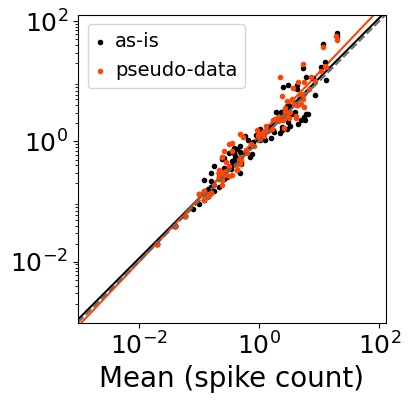

In [21]:
# Mean-variance plot across stimuli or across neurons (as-is & nb)

# rate_nb loading
method = 'resc_r'
n_samples = 50
use_rrep = False
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'
file_name = 'rate_nb_copula_ABO_sep_' + method + '_' + str(n_samples) + 'samples_realR_all.pickle' # r=inf when var_G=0 (500 samples), r=inf when var<mean (50 samples), r=inf when var<mean (500/50 samples, rcomb)
with open(file_name, 'rb') as f:
    rate_nb_copula_ABO = pickle.load(f)
    list_rate_nb2_rep = rate_nb_copula_ABO['list_rate_nb2'].copy()

save_file_name = 'slopes_an_nbpoiss_all.pickle' # nb (50 samples, rcomb), poiss (50 samples)
with open(save_file_name, 'rb') as f:
    slopes_an_nbpoiss_all = pickle.load(f)
    list_slopes_all_an_loglog_nb = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_nb'].copy()
    list_slopes_all_an_loglog_poiss_mean = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_poiss_mean'].copy()
    list_slopes_all_an_loglog_poiss_var = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_poiss_var'].copy()
    
# Scatterplot & Model Lines (ABO Neuropixels all neurons)

print('Mean vs. Variance (ABO Neuropixels)\n')

# Iterate over all sessions
num_sess = 32
num_trial_types = 119
list_target_slopes = [10, 1, 0]
shift_factor = 0
for sess_ind, rate in enumerate(list_rate_all):
    if sess_ind == 3:
        print(f'session index: {sess_ind}')

        rate_sorted = rate.sort_index(axis=1)
        stm = rate_sorted.columns.copy()

        # Multiply by delta t to convert to spike counts
        rate_sorted = rate_sorted * 0.25
        # print(rate_sorted.shape[0])

        # Create a counting dictionary for each stimulus
        all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
        stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

        # Compute mean & variance for each stimulus
        rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
        rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

        list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], \
                                    columns=rate_sorted_mean_coll.columns).copy()
        list_slopes_nb = pd.DataFrame(list_slopes_all_an_loglog_nb[sess_ind, 1], \
                                    columns=rate_sorted_mean_coll.columns).copy()

        for slope_ind, target_slope in enumerate(list_target_slopes):
            if slope_ind == 1:
                # print(f'target_slope {target_slope:.1f}')
        
                # sampled pseudo-data
                rate_nb = pd.DataFrame(list_rate_nb2_rep[sess_ind][slope_ind], columns=np.repeat(all_stm_unique, n_samples)).copy()
                rate_sorted_mean_coll_nb, rate_sorted_var_coll_nb = compute_mean_var_trial_collapse(stm_cnt_dict, rate_nb) # mean, var of sampled pseudo-data

                # scatterplot
                examp_tts = [17]

                fig, axes = plt.subplots(1, 1, figsize=(4, 4))
                axes = np.array(axes).flatten()
                for examp_ind, examp_tt in enumerate(examp_tts):
                    bool_mean_notzero = rate_sorted_mean_coll.loc[:, examp_tt] > 0
                    axes[examp_ind].set_aspect('equal')

                    axes[examp_ind].scatter(rate_sorted_mean_coll.loc[:, examp_tt], rate_sorted_var_coll.loc[:, examp_tt], c='k', marker='.', zorder=1, label='as-is') # as-is
                    axes[examp_ind].scatter(rate_sorted_mean_coll_nb.loc[:, examp_tt], rate_sorted_var_coll_nb.loc[:, examp_tt], c='orangered', marker='.', zorder=1, label='pseudo-data') # mean, var of sampled pseudo-data

                    # Range for x/y axes
                    x = np.concatenate([rate_sorted_mean_coll.loc[:, examp_tt].values, rate_sorted_var_coll.loc[:, examp_tt].values])
                    min_ = np.min(x[~np.isnan(x) & ~np.isinf(x)]) + 2**(-10) # add pseudo-value to avoid log 0
                    max_ = np.max(x[~np.isnan(x) & ~np.isinf(x)]) * 2
                    axes[examp_ind].set_xlim(min_, max_)
                    axes[examp_ind].set_ylim(min_, max_)
                    axes[examp_ind].set_xscale('log')
                    axes[examp_ind].set_yscale('log')
                    axes[examp_ind].set_xticks(np.logspace(-2, 2, 3, endpoint=True, base=10))
                    axes[examp_ind].set_yticks(np.logspace(-2, 2, 3, endpoint=True, base=10))

                    axes[examp_ind].set_xlabel('Mean (spike count)', fontsize=20)
                    # axes[examp_ind].set_ylabel('Variance (spike count$^2$)', fontsize=20)
                    axes[examp_ind].tick_params(axis='both', labelsize=18)
                    axes[examp_ind].legend(loc='upper left', prop={'size': 14}, handlelength=0.5, handletextpad=0.5)

                    # lines
                    x = np.linspace(min_, max_)
                    axes[examp_ind].plot(x, x, color='0.4', linestyle='--') # y = x line

                    slope, intcpt = list_slopes_dr.loc[:, examp_tt]
                    axes[examp_ind].plot(x, pow(10, slope * np.log10(x) + intcpt), color='k', zorder=0)
                    slope_nb, intcpt_nb = list_slopes_nb.loc[:, examp_tt]
                    axes[examp_ind].plot(x, pow(10, slope_nb * np.log10(x) + intcpt_nb), color='orangered', zorder=0)
                    # axes[examp_ind].annotate(f'slope {slope_nb:.2f}', xy=(0.5, 0.15), xycoords='axes fraction', color='orangered', fontsize=18)
                    # axes[examp_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.5, 0.05), xycoords='axes fraction', color='k', fontsize=18)
                    # axes[examp_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.3, 0.05), xycoords='axes fraction', color='k', fontsize=18)

                # plt.savefig('code_images\\svg\\negbinom_mvplot_nb.svg', bbox_inches='tight')
                # plt.savefig('code_images\\png\\negbinom_mvplot_nb.png', dpi=300, bbox_inches='tight')
                plt.show()

## Figure 5a Mean-matched Poisson

session index: 3


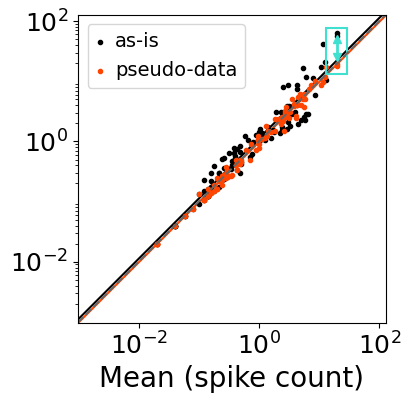

In [22]:
# Mean-variance plot across stimuli or across neurons (as-is & poiss)

n_samples = 50
method_poiss = 'rcomb'
file_name = 'rate_poiss_copula_ABO_sep_' + method_poiss + '_' + str(n_samples) + 'samples_realR_all3.pickle' # lam=mean for comb of neu/stim (500/50 samples)
with open(file_name, 'rb') as f:
    rate_poiss_copula_ABO = pickle.load(f)
    list_rate_poiss2_rep = rate_poiss_copula_ABO['list_rate_poiss2'].copy()
method = method_poiss

save_file_name = 'slopes_an_nbpoiss_all.pickle' # nb (50 samples, rcomb), poiss (50 samples)
with open(save_file_name, 'rb') as f:
    slopes_an_nbpoiss_all = pickle.load(f)
    list_slopes_all_an_loglog_nb = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_nb'].copy()
    list_slopes_all_an_loglog_poiss_mean = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_poiss_mean'].copy()
    list_slopes_all_an_loglog_poiss_var = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_poiss_var'].copy()

# Iterate over all sessions
num_sess = 32
num_trial_types = 119
for sess_ind, rate in enumerate(list_rate_all):
    if sess_ind == 3:
        print(f'session index: {sess_ind}')
        
        rate_sorted = rate.sort_index(axis=1)
        stm = rate_sorted.columns.copy()

        # Multiply by delta t to convert to spike counts
        rate_sorted = rate_sorted * 0.25
        # print(rate_sorted.shape[0])

        # Create a counting dictionary for each stimulus
        all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
        stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

        # Compute mean & variance for each stimulus
        rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
        rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

        list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], \
                                    columns=rate_sorted_mean_coll.columns).copy()
        list_slopes_poiss = pd.DataFrame(list_slopes_all_an_loglog_poiss_mean[sess_ind, 0], \
                                    columns=rate_sorted_mean_coll.columns).copy()

        # sampled pseudo-data
        rate_poiss = pd.DataFrame(list_rate_poiss2_rep[sess_ind], columns=np.repeat(all_stm_unique, n_samples)).copy()
        rate_sorted_mean_coll_poiss, rate_sorted_var_coll_poiss = compute_mean_var_trial_collapse(stm_cnt_dict, rate_poiss) # mean, var of sampled pseudo-data

        # scatterplot
        examp_tts = [17]

        fig, axes = plt.subplots(1, 1, figsize=(4, 4))
        axes = np.array(axes).flatten()
        for examp_ind, examp_tt in enumerate(examp_tts):
            bool_mean_notzero = rate_sorted_mean_coll.loc[:, examp_tt] > 0
            axes[examp_ind].set_aspect('equal')

            axes[examp_ind].scatter(rate_sorted_mean_coll.loc[:, examp_tt], rate_sorted_var_coll.loc[:, examp_tt], c='k', marker='.', zorder=1, label='as-is') # as-is
            axes[examp_ind].scatter(rate_sorted_mean_coll_poiss.loc[:, examp_tt], rate_sorted_var_coll_poiss.loc[:, examp_tt], c='orangered', marker='.', zorder=1, label='pseudo-data') # mean, var of sampled pseudo-data

            # Range for x/y axes
            x = np.concatenate([rate_sorted_mean_coll.loc[:, examp_tt].values, rate_sorted_var_coll.loc[:, examp_tt].values])
            min_ = np.min(x[~np.isnan(x) & ~np.isinf(x)]) + 2**(-10) # add pseudo-value to avoid log 0
            max_ = np.max(x[~np.isnan(x) & ~np.isinf(x)]) * 2
            axes[examp_ind].set_xlim(min_, max_)
            axes[examp_ind].set_ylim(min_, max_)
            axes[examp_ind].set_xscale('log')
            axes[examp_ind].set_yscale('log')
            axes[examp_ind].set_xticks(np.logspace(-2, 2, 3, endpoint=True, base=10))
            axes[examp_ind].set_yticks(np.logspace(-2, 2, 3, endpoint=True, base=10))

            axes[examp_ind].set_xlabel('Mean (spike count)', fontsize=20)
            # axes[examp_ind].set_ylabel('Variance (spike count$^2$)', fontsize=20)
            axes[examp_ind].tick_params(axis='both', labelsize=18)
            axes[examp_ind].legend(loc='upper left', prop={'size': 14}, handlelength=0.5, handletextpad=0.5)
            # axes[examp_ind].annotate(f'⬍', xy=(0.82, 0.9), xycoords='axes fraction', fontsize=14, color='orangered')

            # mean-matched poisson
            x_pos = 20
            y_top, y_bottom = 50, 25
            axes[examp_ind].plot([x_pos, x_pos], [y_bottom, y_top], color='turquoise', linewidth=2, zorder=3)
            axes[examp_ind].plot(x_pos, y_top, marker='^', color='turquoise', markersize=6, zorder=3)
            axes[examp_ind].plot(x_pos, y_bottom, marker='v', color='turquoise', markersize=6, zorder=3)

            x_min, x_max = 13, 29
            y_min, y_max = 13, 78          
            rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                                     linewidth=1.5, edgecolor='turquoise', facecolor='none', zorder=2)
            axes[examp_ind].add_patch(rect)

            # lines
            x = np.linspace(min_, max_)
            axes[examp_ind].plot(x, x, color='0.4', linestyle='--') # y = x line

            slope, intcpt = list_slopes_dr.loc[:, examp_tt]
            axes[examp_ind].plot(x, pow(10, slope * np.log10(x) + intcpt), color='k', zorder=0)
            slope_poiss, intcpt_poiss = list_slopes_poiss.loc[:, examp_tt]
            axes[examp_ind].plot(x, pow(10, slope_poiss * np.log10(x) + intcpt_poiss), color='orangered', zorder=0)
            # axes[examp_ind].annotate(f'slope {slope_poiss:.2f}', xy=(0.45, 0.15), xycoords='axes fraction', color='orangered', fontsize=18)
            # axes[examp_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.45, 0.05), xycoords='axes fraction', color='k', fontsize=18)
            # axes[examp_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.3, 0.05), xycoords='axes fraction', color='k', fontsize=18)

        # # plt.savefig('code_images\\svg\\negbinom_mvplot_poiss_mean.svg', bbox_inches='tight')
        # # plt.savefig('code_images\\png\\negbinom_mvplot_poiss_mean.png', dpi=300, bbox_inches='tight')
        # plt.savefig('code_images\\svg\\negbinom_mvplot_poiss_var.svg', bbox_inches='tight')
        # plt.savefig('code_images\\png\\negbinom_mvplot_poiss_var.png', dpi=300, bbox_inches='tight')
        plt.show()

## Figure 5a Variance-matched Poisson

session index: 3


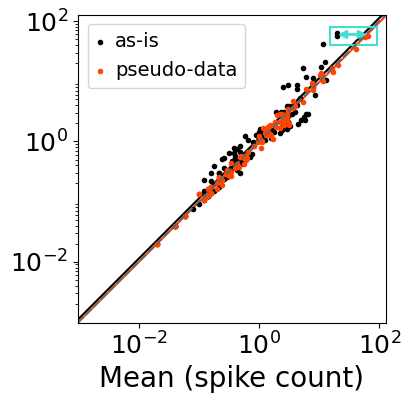

In [23]:
# Mean-variance plot across stimuli or across neurons (as-is & poiss)

n_samples = 50
method_poiss = 'rcomb'
file_name = 'rate_poiss_copula_ABO_sep_' + method_poiss + '_' + str(n_samples) + 'samples_realR_all4.pickle' # lam=var for comb of neu/stim (500/50 samples)
with open(file_name, 'rb') as f:
    rate_poiss_copula_ABO = pickle.load(f)
    list_rate_poiss2_rep = rate_poiss_copula_ABO['list_rate_poiss2'].copy()
method = method_poiss

save_file_name = 'slopes_an_nbpoiss_all.pickle' # nb (50 samples, rcomb), poiss (50 samples)
with open(save_file_name, 'rb') as f:
    slopes_an_nbpoiss_all = pickle.load(f)
    list_slopes_all_an_loglog_nb = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_nb'].copy()
    list_slopes_all_an_loglog_poiss_mean = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_poiss_mean'].copy()
    list_slopes_all_an_loglog_poiss_var = slopes_an_nbpoiss_all['list_slopes_all_an_loglog_poiss_var'].copy()

# Iterate over all sessions
num_sess = 32
num_trial_types = 119
for sess_ind, rate in enumerate(list_rate_all):
    if sess_ind == 3:
        print(f'session index: {sess_ind}')
        
        rate_sorted = rate.sort_index(axis=1)
        stm = rate_sorted.columns.copy()

        # Multiply by delta t to convert to spike counts
        rate_sorted = rate_sorted * 0.25
        # print(rate_sorted.shape[0])

        # Create a counting dictionary for each stimulus
        all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
        stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

        # Compute mean & variance for each stimulus
        rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
        rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

        list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], \
                                    columns=rate_sorted_mean_coll.columns).copy()
        list_slopes_poiss = pd.DataFrame(list_slopes_all_an_loglog_poiss_var[sess_ind, 0], \
                                    columns=rate_sorted_mean_coll.columns).copy()

        # sampled pseudo-data
        rate_poiss = pd.DataFrame(list_rate_poiss2_rep[sess_ind], columns=np.repeat(all_stm_unique, n_samples)).copy()
        rate_sorted_mean_coll_poiss, rate_sorted_var_coll_poiss = compute_mean_var_trial_collapse(stm_cnt_dict, rate_poiss) # mean, var of sampled pseudo-data

        # scatterplot
        examp_tts = [17]

        fig, axes = plt.subplots(1, 1, figsize=(4, 4))
        axes = np.array(axes).flatten()
        for examp_ind, examp_tt in enumerate(examp_tts):
            bool_mean_notzero = rate_sorted_mean_coll.loc[:, examp_tt] > 0
            axes[examp_ind].set_aspect('equal')

            axes[examp_ind].scatter(rate_sorted_mean_coll.loc[:, examp_tt], rate_sorted_var_coll.loc[:, examp_tt], c='k', marker='.', zorder=1, label='as-is') # as-is
            axes[examp_ind].scatter(rate_sorted_mean_coll_poiss.loc[:, examp_tt], rate_sorted_var_coll_poiss.loc[:, examp_tt], c='orangered', marker='.', zorder=1, label='pseudo-data') # mean, var of sampled pseudo-data

            # Range for x/y axes
            x = np.concatenate([rate_sorted_mean_coll.loc[:, examp_tt].values, rate_sorted_var_coll.loc[:, examp_tt].values])
            min_ = np.min(x[~np.isnan(x) & ~np.isinf(x)]) + 2**(-10) # add pseudo-value to avoid log 0
            max_ = np.max(x[~np.isnan(x) & ~np.isinf(x)]) * 2
            axes[examp_ind].set_xlim(min_, max_)
            axes[examp_ind].set_ylim(min_, max_)
            axes[examp_ind].set_xscale('log')
            axes[examp_ind].set_yscale('log')
            axes[examp_ind].set_xticks(np.logspace(-2, 2, 3, endpoint=True, base=10))
            axes[examp_ind].set_yticks(np.logspace(-2, 2, 3, endpoint=True, base=10))

            axes[examp_ind].set_xlabel('Mean (spike count)', fontsize=20)
            # axes[examp_ind].set_ylabel('Variance (spike count$^2$)', fontsize=20)
            axes[examp_ind].tick_params(axis='both', labelsize=18)
            axes[examp_ind].legend(loc='upper left', prop={'size': 14}, handlelength=0.5, handletextpad=0.5)
            # axes[examp_ind].annotate(f'⬍', xy=(0.82, 0.9), xycoords='axes fraction', fontsize=14, color='orangered')

            # var-matched poisson
            x_left, x_right = 25, 50
            y_pos = 60
            axes[examp_ind].plot([x_left, x_right], [y_pos, y_pos], color='turquoise', linewidth=2, zorder=3)
            axes[examp_ind].plot(x_left, y_pos, marker='<', color='turquoise', markersize=6, zorder=3)
            axes[examp_ind].plot(x_right, y_pos, marker='>', color='turquoise', markersize=6, zorder=3)

            x_min, x_max = 15, 90
            y_min, y_max = 40, 80
            rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                                     linewidth=1.5, edgecolor='turquoise', facecolor='none', zorder=2)
            axes[examp_ind].add_patch(rect)

            # lines
            x = np.linspace(min_, max_)
            axes[examp_ind].plot(x, x, color='0.4', linestyle='--') # y = x line

            slope, intcpt = list_slopes_dr.loc[:, examp_tt]
            axes[examp_ind].plot(x, pow(10, slope * np.log10(x) + intcpt), color='k', zorder=0)
            slope_poiss, intcpt_poiss = list_slopes_poiss.loc[:, examp_tt]
            axes[examp_ind].plot(x, pow(10, slope_poiss * np.log10(x) + intcpt_poiss), color='orangered', zorder=0)
            # axes[examp_ind].annotate(f'slope {slope_poiss:.2f}', xy=(0.45, 0.15), xycoords='axes fraction', color='orangered', fontsize=18)
            # axes[examp_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.45, 0.05), xycoords='axes fraction', color='k', fontsize=18)
            # axes[examp_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.3, 0.05), xycoords='axes fraction', color='k', fontsize=18)

        # # plt.savefig('code_images\\svg\\negbinom_mvplot_poiss_mean.svg', bbox_inches='tight')
        # # plt.savefig('code_images\\png\\negbinom_mvplot_poiss_mean.png', dpi=300, bbox_inches='tight')
        # plt.savefig('code_images\\svg\\negbinom_mvplot_poiss_var.svg', bbox_inches='tight')
        # plt.savefig('code_images\\png\\negbinom_mvplot_poiss_var.png', dpi=300, bbox_inches='tight')
        plt.show()

## Figure 5b

In [ ]:
# # Collect effective dimensionality for each session

# list_target_slopes = [10, 1, 0]
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# n_trial_sampling = 100

# method = 'resc_r'
# n_samples = 50
# use_rrep = False
# if not use_rrep: # one r for each combination of neuron and stimulus
#     method += '_rcomb'
# method = 'rcomb'

# list_dim_asis2 = np.full((num_sess, num_trial_types), np.nan)
# list_dim_global_asis2 = np.full((num_sess, 2), np.nan)
# list_dim_sam_asis2 = np.full((num_sess, n_trial_sampling), np.nan)
# list_dim_nb2 = np.full((num_sess, len(list_target_slopes), num_trial_types), np.nan)
# list_dim_global_nb2 = np.full((num_sess, len(list_target_slopes), 2), np.nan)
# list_dim_sam_nb2 = np.full((num_sess, len(list_target_slopes), n_trial_sampling), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'eff_dim_DC_ABO_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'
#     file_name = 'eff_dim_DC_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'
#     file_name = 'eff_dim_DC_ABO_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'

#     with open(file_name, 'rb') as f:
#         eff_dim_DC_ABO_nb = pickle.load(f)
#         list_dim_asis2[sess_ind] = eff_dim_DC_ABO_nb['list_dim_asis'].copy()
#         list_dim_global_asis2[sess_ind] = eff_dim_DC_ABO_nb['list_dim_global_asis'].copy()
#         list_dim_sam_asis2[sess_ind] = eff_dim_DC_ABO_nb['list_dim_sam_asis'].copy()        
#         list_dim_nb2[sess_ind] = eff_dim_DC_ABO_nb['list_dim_nb'].copy()
#         list_dim_global_nb2[sess_ind] = eff_dim_DC_ABO_nb['list_dim_global_nb'].copy()
#         list_dim_sam_nb2[sess_ind] = eff_dim_DC_ABO_nb['list_dim_sam_nb'].copy()

# save_file_name = 'eff_dim_DC_ABO_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_all2.pickle'
# save_file_name = 'eff_dim_DC_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all5.pickle'
# save_file_name = 'eff_dim_DC_ABO_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle'
# with open(save_file_name, 'wb') as f:
#     # pickle.dump({'tree_variables': 'list_dim_nb2', 'list_dim_nb2': list_dim_nb2}, f)
#     # pickle.dump({'tree_variables': ['list_dim_nb2', 'list_dim_global_nb2', 'list_dim_sam_nb2'],
#     #                 'list_dim_nb2': list_dim_nb2, 'list_dim_global_nb2': list_dim_global_nb2, 'list_dim_sam_nb2': list_dim_sam_nb2}, f)
#     pickle.dump({'tree_variables': ['list_dim_asis2', 'list_dim_nb2', 'list_dim_global_asis2', 'list_dim_global_nb2', 'list_dim_sam_asis2', 'list_dim_sam_nb2'],
#                 'list_dim_asis2': list_dim_asis2, 'list_dim_nb2': list_dim_nb2, 'list_dim_global_asis2': list_dim_global_asis2, 'list_dim_global_nb2': list_dim_global_nb2,
#                 'list_dim_sam_asis2': list_dim_sam_asis2, 'list_dim_sam_nb2': list_dim_sam_nb2}, f)
#     # pickle.dump({'tree_variables': ['list_dim_asis2', 'list_dim_global_asis2', 'list_dim_sam_asis2'],
#     #             'list_dim_asis2': list_dim_asis2, 'list_dim_global_asis2': list_dim_global_asis2,
#     #             'list_dim_sam_asis2': list_dim_sam_asis2}, f)

As-is vs. NB+P p=0.0606
As-is vs. Poisson
(mean) p=0.0006
As-is vs. Poisson
(var) p=0.0010
NB+P vs. Poisson
(mean) p=0.0000
NB+P vs. Poisson
(var) p=0.0017
Poisson
(mean) vs. Poisson
(var) p=0.0000


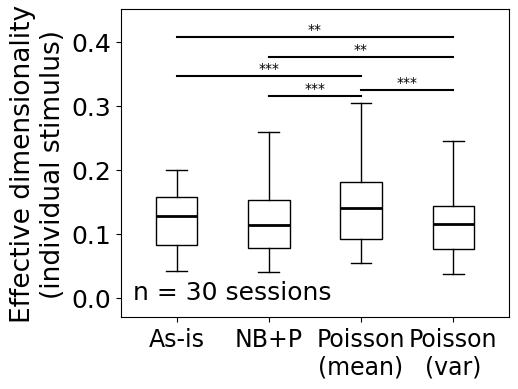

In [26]:
# Effective dimensionality (individual stimulus)

list_target_slopes = [10, 1, 0]
num_sess = 32
num_trial_types = 119
n_trial_sampling = 100
num_cond = 4
list_dim_nb_concat = np.full((num_sess, num_cond, num_trial_types), np.nan)
list_dim_global_nb_concat = np.full((num_sess, num_cond, 2), np.nan)

# as-is loading
save_filename = 'eff_dim_DC_ABO3.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with open(save_filename, 'rb') as f:
    eff_dim_DC_ABO = pickle.load(f)
    list_dim_nb_concat[:, 0] = eff_dim_DC_ABO['list_dim_asis'].copy()
    list_dim_global_nb_concat[:, 0] = dc(eff_dim_DC_ABO['list_dim_global_asis'])

n_samples = 50
method = 'resc_r'
use_rrep = False
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'
save_file_name = 'eff_dim_DC_ABO_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, all trials, centroids, sampled trials (500 samples) (50 samples, rcomb, math corrected)
with open(save_file_name, 'rb') as f:
    eff_dim_DC_ABO_nb_sep = pickle.load(f)
    list_dim_nb_concat[:, 1] = dc(eff_dim_DC_ABO_nb_sep['list_dim_nb2'][:, 1])
    list_dim_global_nb_concat[:, 1] = dc(eff_dim_DC_ABO_nb_sep['list_dim_global_nb2'][:, 1])

method = 'rcomb'
save_file_name = 'eff_dim_DC_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all3.pickle' # same as above, all trials, centroids, sampled trials (500 samples) (50 samples, rcomb, math corrected)
with open(save_file_name, 'rb') as f:
    eff_dim_DC_ABO_nb_sep = pickle.load(f)
    list_dim_nb_concat[:, 2] = dc(eff_dim_DC_ABO_nb_sep['list_dim_nb2'][:, 0])
    list_dim_global_nb_concat[:, 2] = dc(eff_dim_DC_ABO_nb_sep['list_dim_global_nb2'][:, 0])

save_file_name = 'eff_dim_DC_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all4.pickle' # same as above, all trials, centroids, sampled trials (500 samples) (50 samples, rcomb, math corrected)
with open(save_file_name, 'rb') as f:
    eff_dim_DC_ABO_nb_sep = pickle.load(f)
    list_dim_nb_concat[:, 3] = dc(eff_dim_DC_ABO_nb_sep['list_dim_nb2'][:, 0])
    list_dim_global_nb_concat[:, 3] = dc(eff_dim_DC_ABO_nb_sep['list_dim_global_nb2'][:, 0])

# exclude session 0, 6
mask_06 = ~np.isin(range(num_sess), [0, 6])
list_dim_nb_concat = list_dim_nb_concat[mask_06].copy()
list_dim_global_nb_concat = list_dim_global_nb_concat[mask_06].copy()

# box plot
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

list_dim_intv = np.nanmean(list_dim_nb_concat, axis=2)
glo_ind = 0
list_dim_global_intv = list_dim_global_nb_concat[:, :, glo_ind].copy()

num_cond = list_dim_intv.shape[1]

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = ['As-is', 'NB+P', 'Poisson\n(mean)', 'Poisson\n(var)']
d_x = 0
d_x_left = 0
d_x_right = 0.1

box = axes[0].boxplot([list_dim_intv[:, intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w') # box color
    median_.set(color='k', linewidth=2) # median line color

# significance
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_dim = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_dim[pair_ind] = list(wilcoxon(list_dim_intv[:, pair[0]], list_dim_intv[:, pair[1]]))[1]
list_pvals_dim = np.array(multipletests(list_pvals_dim, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_dim[pair_ind]:.4f}')

axes[0].set_ylim(-0.03, 0.45) # individual
whiskers = [get_upper_whisker(d) for d in list_dim_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.01]*num_cond, x_positions=center,
                      p_values=list_pvals_dim, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)

axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=17)

# height = (np.mean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
axes[0].annotate(f'n = {list_dim_intv.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\negbinom_effdim_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_effdim_interval.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_effdim_glo_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_effdim_glo_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5c

As-is vs. NB+P p=0.0221
As-is vs. Poisson
(mean) p=0.0011
As-is vs. Poisson
(var) p=0.0121
NB+P vs. Poisson
(mean) p=0.0121
NB+P vs. Poisson
(var) p=0.0002
Poisson
(mean) vs. Poisson
(var) p=0.0001


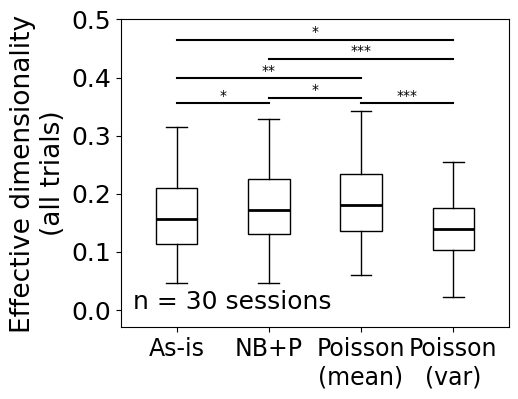

In [27]:
# Effective dimensionality (global)

list_target_slopes = [10, 1, 0]
num_sess = 32
num_trial_types = 119
n_trial_sampling = 100
num_cond = 4
list_dim_nb_concat = np.full((num_sess, num_cond, num_trial_types), np.nan)
list_dim_global_nb_concat = np.full((num_sess, num_cond, 2), np.nan)

# as-is loading
save_filename = 'eff_dim_DC_ABO3.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with open(save_filename, 'rb') as f:
    eff_dim_DC_ABO = pickle.load(f)
    list_dim_nb_concat[:, 0] = eff_dim_DC_ABO['list_dim_asis'].copy()
    list_dim_global_nb_concat[:, 0] = dc(eff_dim_DC_ABO['list_dim_global_asis'])

n_samples = 50
method = 'resc_r'
use_rrep = False
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'
save_file_name = 'eff_dim_DC_ABO_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, all trials, centroids, sampled trials (500 samples) (50 samples, rcomb, math corrected)
with open(save_file_name, 'rb') as f:
    eff_dim_DC_ABO_nb_sep = pickle.load(f)
    list_dim_nb_concat[:, 1] = dc(eff_dim_DC_ABO_nb_sep['list_dim_nb2'][:, 1])
    list_dim_global_nb_concat[:, 1] = dc(eff_dim_DC_ABO_nb_sep['list_dim_global_nb2'][:, 1])

method = 'rcomb'
save_file_name = 'eff_dim_DC_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all3.pickle' # same as above, all trials, centroids, sampled trials (500 samples) (50 samples, rcomb, math corrected)
with open(save_file_name, 'rb') as f:
    eff_dim_DC_ABO_nb_sep = pickle.load(f)
    list_dim_nb_concat[:, 2] = dc(eff_dim_DC_ABO_nb_sep['list_dim_nb2'][:, 0])
    list_dim_global_nb_concat[:, 2] = dc(eff_dim_DC_ABO_nb_sep['list_dim_global_nb2'][:, 0])

save_file_name = 'eff_dim_DC_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all4.pickle' # same as above, all trials, centroids, sampled trials (500 samples) (50 samples, rcomb, math corrected)
with open(save_file_name, 'rb') as f:
    eff_dim_DC_ABO_nb_sep = pickle.load(f)
    list_dim_nb_concat[:, 3] = dc(eff_dim_DC_ABO_nb_sep['list_dim_nb2'][:, 0])
    list_dim_global_nb_concat[:, 3] = dc(eff_dim_DC_ABO_nb_sep['list_dim_global_nb2'][:, 0])

# exclude session 0, 6
mask_06 = ~np.isin(range(num_sess), [0, 6])
list_dim_nb_concat = list_dim_nb_concat[mask_06].copy()
list_dim_global_nb_concat = list_dim_global_nb_concat[mask_06].copy()

# box plot
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

list_dim_intv = np.nanmean(list_dim_nb_concat, axis=2)
glo_ind = 0
list_dim_global_intv = list_dim_global_nb_concat[:, :, glo_ind].copy()

# global
list_dim_intv = list_dim_global_intv

num_cond = list_dim_intv.shape[1]

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = ['As-is', 'NB+P', 'Poisson\n(mean)', 'Poisson\n(var)']
d_x = 0
d_x_left = 0
d_x_right = 0.1

box = axes[0].boxplot([list_dim_intv[:, intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w') # box color
    median_.set(color='k', linewidth=2) # median line color

# significance
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_dim = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_dim[pair_ind] = list(wilcoxon(list_dim_intv[:, pair[0]], list_dim_intv[:, pair[1]]))[1]
list_pvals_dim = np.array(multipletests(list_pvals_dim, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_dim[pair_ind]:.4f}')

axes[0].set_ylim(-0.03, 0.5) # global
whiskers = [get_upper_whisker(d) for d in list_dim_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.01]*num_cond, x_positions=center,
                      p_values=list_pvals_dim, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)

axes[0].set_ylabel('Effective dimensionality\n(all trials)', fontsize=19)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=17)

# height = (np.mean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
axes[0].annotate(f'n = {list_dim_intv.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\negbinom_effdim_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_effdim_interval.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_effdim_glo_interval.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_effdim_glo_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5d

In [ ]:
# # Collect decoding for each session (SVM)

# decoder_type = 'SVM'

# list_target_slopes = [10, 1, 0]
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119

# method = 'resc_r'
# n_samples = 50
# use_rrep = True
# if not use_rrep: # one r for each combination of neuron and stimulus
#     method += '_rcomb'
# method = 'rcomb'

# list_mean_confusion_test = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy = np.full(num_sess, np.nan)
# list_mean_confusion_test_RRneuron2 = np.full((len(list_target_slopes), num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy_RRneuron2 = np.full((len(list_target_slopes), num_sess), np.nan)
# for sess_ind in range(num_sess):
#     file_name = decoder_type + '_decoding_ABO_allstim_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'
#     file_name = decoder_type + '_decoding_ABO_allstim_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'
#     file_name = decoder_type + '_decoding_ABO_allstim_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'

#     with open(file_name, 'rb') as f:
#         decoding_ABO = pickle.load(f)

#         list_mean_confusion_test[sess_ind] = decoding_ABO['mean_confusion_test_asis'].copy()
#         list_mean_accuracy[sess_ind] = decoding_ABO['mean_accuracy_asis']
#         list_mean_confusion_test_RRneuron2[:, sess_ind] = decoding_ABO['list_mean_confusion_test_RRneuron'].copy()
#         list_mean_accuracy_RRneuron2[:, sess_ind] = decoding_ABO['list_mean_accuracy_RRneuron'].copy()

# save_file_name = decoder_type + '_decoding_ABO_allstim_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_all.pickle'
# save_file_name = decoder_type + '_decoding_ABO_allstim_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all2.pickle'
# save_file_name = decoder_type + '_decoding_ABO_allstim_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_mean_confusion_test', 'list_mean_accuracy', 'list_mean_confusion_test_RRneuron2', 'list_mean_accuracy_RRneuron2'],
#                     'list_mean_confusion_test': list_mean_confusion_test, 'list_mean_accuracy': list_mean_accuracy,
#                     'list_mean_confusion_test_RRneuron2': list_mean_confusion_test_RRneuron2, 'list_mean_accuracy_RRneuron2': list_mean_accuracy_RRneuron2}, f)
#     # pickle.dump({'tree_variables': ['list_mean_confusion_test', 'list_mean_accuracy'],
#     #                 'list_mean_confusion_test': list_mean_confusion_test, 'list_mean_accuracy': list_mean_accuracy}, f)

As-is vs. NB+P p=0.0000
As-is vs. Poisson
(mean) p=0.0000
As-is vs. Poisson
(var) p=0.0000
NB+P vs. Poisson
(mean) p=0.0000
NB+P vs. Poisson
(var) p=0.0000
Poisson
(mean) vs. Poisson
(var) p=0.0000


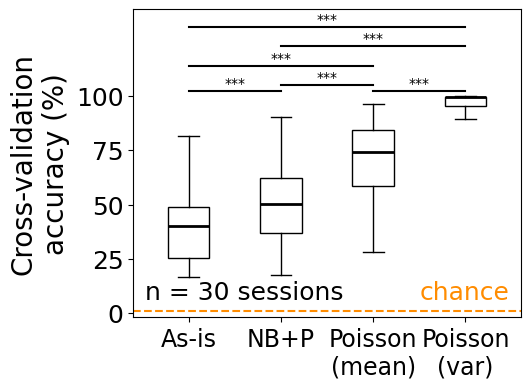

In [29]:
# decoding plot across slopes (ABO, SVM)
num_sess = 32
num_cond = 4
num_trial_types = 119
list_mean_accuracy_concat = np.full((num_cond, num_sess), np.nan)

decoder_type = 'SVM'

save_file_name = decoder_type + '_decoding_ABO_allstim_all.pickle' # randomness matched (slope 0~2), logit/SVM max_iter=1000/-1
# save_file_name = decoder_type + '_decoding_ABO_allstim_all2.pickle' # randomness matched (slope 0~2), logit/SVM max_iter=100
save_file_name = decoder_type + '_decoding_ABO_allstim_all3.pickle' # randomness matched (slope 0~2), SVM max_iter=1000
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)
    list_mean_accuracy_concat[0] = dc(decoding_ABO_all['list_mean_accuracy'])

n_samples = 50
method = 'resc_r'
use_rrep = False
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'
save_file_name = decoder_type + '_decoding_ABO_allstim_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_all.pickle' # same as above, (RRneuron SVM max_iter=1000, slope 10, 1, 0, r=inf when var_G=0), (SVM max_iter=1000, r=inf when var<mean) (500/50 samples, rcomb)
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)
    list_mean_accuracy_concat[1] = dc(decoding_ABO_all['list_mean_accuracy_RRneuron2'][1])

n_samples = 50
method = 'rcomb'
save_file_name = decoder_type + '_decoding_ABO_allstim_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all.pickle' # same as above, SVM max_iter=1000, lam=mean for comb of neu/stim (500/50 samples)
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)
    list_mean_accuracy_concat[2] = dc(decoding_ABO_all['list_mean_accuracy_RRneuron2'][0])

n_samples = 50
save_file_name = decoder_type + '_decoding_ABO_allstim_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, SVM max_iter=1000, lam=var for comb of neu/stim (500/50 samples)
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)
    list_mean_accuracy_concat[3] = dc(decoding_ABO_all['list_mean_accuracy_RRneuron2'][0])

# exclude session 0, 6
list_mean_accuracy_concat = np.stack(list_mean_accuracy_concat)
list_mean_accuracy_concat = np.concatenate([list_mean_accuracy_concat[:, 1:6], list_mean_accuracy_concat[:, 7:]], axis=1)
list_mean_accuracy_concat = 100 * list_mean_accuracy_concat

num_sess = list_mean_accuracy_concat.shape[1]

# As-is vs. RRneuron test accuracy bar graph (averaged across sessions)
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

list_accuracy_intv = list_mean_accuracy_concat.copy()
num_cond = list_accuracy_intv.shape[0]

# box plot
center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = ['As-is', 'NB+P', 'Poisson\n(mean)', 'Poisson\n(var)']
d_x = 0

box = axes[0].boxplot([list_accuracy_intv[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w') # box color
    median_.set(color='k', linewidth=2) # median line color

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], axes[0].get_ylim()[1])
axes[0].set_ylim(-2, 120)
axes[0].set_ylim(-2, 140)

comb_intv = list(combinations(range(num_cond), 2))
list_pvals_accuracy = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_accuracy[pair_ind] = list(wilcoxon(list_accuracy_intv[pair[0]], list_accuracy_intv[pair[1]]))[1]
list_pvals_accuracy = np.array(multipletests(list_pvals_accuracy, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_accuracy[pair_ind]:.4f}')
# print(list_pvals_accuracy)
whiskers = [get_upper_whisker(d) for d in list_accuracy_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)]*num_cond, x_positions=center,
                      p_values=list_pvals_accuracy, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)
axes[0].set_yticks(np.arange(0, 105, 25))

# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=17)

axes[0].annotate(f'n = {num_sess} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
axes[0].axhline(1/num_trial_types*100, c='darkorange', linestyle='--') # chance level
axes[0].annotate(f'chance', xy=(0.74, 0.06), xycoords='axes fraction', fontsize=18, color='darkorange')

# plt.savefig('code_images\\svg\\negbinom_decoding_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_decoding_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5e

In [ ]:
# # Collect overlap for each session (natural scenes)

# list_target_slopes = np.array([10, 1, 0])
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119

# method = 'resc_r'
# n_samples = 50
# use_rrep = False
# if not use_rrep: # one r for each combination of neuron and stimulus
#     method += '_rcomb'
# method = 'rcomb'

# list_overlap_asis2 = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_overlap_RRneuron3 = np.full((num_sess, len(list_target_slopes), num_trial_types, num_trial_types), np.nan)
# list_gap_asis2 = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_gap_RRneuron3 = np.full((num_sess, len(list_target_slopes), num_trial_types, num_trial_types), np.nan)
# list_size_scc_asis = np.full(num_sess, np.nan)
# list_size_scc_RRneuron2 = np.full((num_sess, len(list_target_slopes)), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'overlap_nbr_stimpairs_ABO_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
#     file_name = 'overlap_nbr_stimpairs_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
#     file_name = 'overlap_nbr_stimpairs_ABO_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
    
#     with open(file_name, 'rb') as f:
#         overlap_stimpairs_ABO = pickle.load(f)
#         list_overlap_asis2[sess_ind] = overlap_stimpairs_ABO['list_overlap_asis'].copy()
#         list_overlap_RRneuron3[sess_ind] = overlap_stimpairs_ABO['list_overlap_RRneuron2'].copy()
#         # list_gap_asis2[sess_ind] = overlap_stimpairs_ABO['list_gap_asis'].copy()
#         # list_gap_RRneuron3[sess_ind] = overlap_stimpairs_ABO['list_gap_RRneuron2'].copy()
#         list_size_scc_asis[sess_ind] = overlap_stimpairs_ABO['size_scc_asis']
#         list_size_scc_RRneuron2[sess_ind] = overlap_stimpairs_ABO['list_size_scc_RRneuron'].copy()

# save_file_name = 'overlap_nbr_stimpairs_ABO_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_all2.pickle'
# save_file_name = 'overlap_nbr_stimpairs_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all4.pickle'
# save_file_name = 'overlap_nbr_stimpairs_ABO_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle'
# with open(save_file_name, 'wb') as f:
#     # pickle.dump({'tree_variables': ['list_overlap_asis2', 'list_overlap_RRneuron3', 'list_gap_asis2', 'list_gap_RRneuron3'], \
#     #              'list_overlap_asis2': list_overlap_asis2, 'list_overlap_RRneuron3': list_overlap_RRneuron3,
#     #              'list_gap_asis2': list_gap_asis2, 'list_gap_RRneuron3': list_gap_RRneuron3}, f)
#     # pickle.dump({'tree_variables': ['list_overlap_asis2', 'list_overlap_RRneuron3'], \
#     #              'list_overlap_asis2': list_overlap_asis2, 'list_overlap_RRneuron3': list_overlap_RRneuron3}, f)
#     pickle.dump({'tree_variables': ['list_overlap_asis2', 'list_overlap_RRneuron3', 'list_size_scc_asis', 'list_size_scc_RRneuron2'], \
#                  'list_overlap_asis2': list_overlap_asis2, 'list_overlap_RRneuron3': list_overlap_RRneuron3,
#                  'list_size_scc_asis': list_size_scc_asis, 'list_size_scc_RRneuron2': list_size_scc_RRneuron2}, f)

As-is vs. NB+P p=0.3173
As-is vs. Poisson
(mean) p=0.2037
As-is vs. Poisson
(var) p=0.0000
NB+P vs. Poisson
(mean) p=0.2037
NB+P vs. Poisson
(var) p=0.0000
Poisson
(mean) vs. Poisson
(var) p=0.0000


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


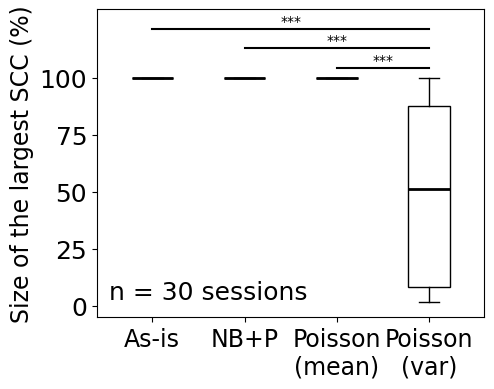

In [31]:
# connected component

num_sess = 32
num_cond = 4
num_trial_types = 119
list_size_scc_concat = np.full((num_sess, num_cond), np.nan)

method = 'resc_r'
n_samples = 50
use_rrep = False
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'

save_file_name = 'overlap_nbr_stimpairs_ABO_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, slope 10, 1, 0 (500 samples), slope 1 (50 samples, rcomb, use cpu)
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    list_size_scc_concat[:, 0] = dc(overlap_stimpairs_ABO_all['list_size_scc_asis'])
    list_size_scc_concat[:, 1] = dc(overlap_stimpairs_ABO_all['list_size_scc_RRneuron2'][:, 1])

method = 'rcomb'
save_file_name = 'overlap_nbr_stimpairs_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all3.pickle' # lam=mean for comb of neu/stim, slope 0 (50 samples, use cpu)
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    list_size_scc_concat[:, 2] = dc(overlap_stimpairs_ABO_all['list_size_scc_RRneuron2'][:, 0])
save_file_name = 'overlap_nbr_stimpairs_ABO_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all4.pickle' # lam=var for comb of neu/stim, slope 0 (50 samples, use cpu)
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    list_size_scc_concat[:, 3] = dc(overlap_stimpairs_ABO_all['list_size_scc_RRneuron2'][:, 0])
      
# exclude session 0, 6
bool_sess = ~np.isin(range(num_sess), [0, 6])
list_size_scc_concat = list_size_scc_concat[bool_sess]
list_size_scc_concat = list_size_scc_concat / num_trial_types * 100

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# box plot
center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = ['As-is', 'NB+P', 'Poisson\n(mean)', 'Poisson\n(var)']
d_x = 0

# Remove NaN
list_size_scc_intv = list_size_scc_concat
list_size_scc_intv_temp = np.empty(num_cond, dtype=object)
for intv_ind in range(num_cond):
    intv_temp = list_size_scc_intv[:, intv_ind].copy()
    list_size_scc_intv_temp[intv_ind] = intv_temp[~np.isnan(intv_temp)].copy()
box = axes[0].boxplot([list_size_scc_intv_temp[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w') # box color
    median_.set(color='k', linewidth=2) # median line color
    
# significance
axes[0].set_ylim(-5, 130)
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_size_scc = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_size_scc[pair_ind] = list(wilcoxon(list_size_scc_intv[:, pair[0]], list_size_scc_intv[:, pair[1]], nan_policy='omit'))[1]
list_pvals_size_scc = np.array(multipletests(list_pvals_size_scc, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_size_scc[pair_ind]:.4f}')
whiskers = [get_upper_whisker(d) for d in list_size_scc_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.02]*num_cond, x_positions=center,
                      p_values=list_pvals_size_scc, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)
# axes[0].set_yticks(np.arange(-0.2, 0.7, 0.2))

axes[0].set_yticks(np.arange(0, 101, 25))
# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel(f'Size of the largest SCC (%)', fontsize=17)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=17)

# axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 12})

# height = (np.mean(list_size_scc_asis[:, 0])-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='r')
axes[0].annotate(f'n = {list_size_scc_intv.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\negbinom_scc_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_scc_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5f

In [32]:
# # Collect correlation for each session (within session)
# similarity_type = 'cos_sim'

# method = 'resc_r'
# n_samples = 50
# use_rrep = True
# if not use_rrep: # one r for each combination of neuron and stimulus
#     method += '_rcomb'
# method = 'rcomb'

# list_target_slopes = np.array([10, 1, 0])
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# n_neu_sampling = 10

# list_RSM_neu1_all2 = np.full((num_sess, n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu2_all2 = np.full((num_sess, n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu1_RRneuron_all2 = np.full((num_sess, len(list_target_slopes), n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu2_RRneuron_all2 = np.full((num_sess, len(list_target_slopes), n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_corr_withinsess_asis2 = np.zeros((num_sess, n_neu_sampling, 3))
# list_corr_withinsess3 = np.zeros((num_sess, len(list_target_slopes), n_neu_sampling, 3))
# for sess_ind in range(num_sess):
#     file_name = 'RSM_corr_withinsess_ABO_nb_sep_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
#     file_name = 'RSM_corr_withinsess_ABO_poiss_sep_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
#     file_name = 'RSM_corr_withinsess_ABO_katz_indep_sep_RRneuron_' + similarity_type + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
    
#     with open(file_name, 'rb') as f:
#         RSM_corr_withinsess_ABO = pickle.load(f)
#         list_RSM_neu1_all2[sess_ind] = RSM_corr_withinsess_ABO['list_RSM_neu1_all'].copy()
#         list_RSM_neu2_all2[sess_ind] = RSM_corr_withinsess_ABO['list_RSM_neu2_all'].copy()
#         list_RSM_neu1_RRneuron_all2[sess_ind] = RSM_corr_withinsess_ABO['list_RSM_neu1_RRneuron_all'].copy()
#         list_RSM_neu2_RRneuron_all2[sess_ind] = RSM_corr_withinsess_ABO['list_RSM_neu2_RRneuron_all'].copy()
#         list_corr_withinsess_asis2[sess_ind] = RSM_corr_withinsess_ABO['list_corr_withinsess_asis'].copy()
#         list_corr_withinsess3[sess_ind] = RSM_corr_withinsess_ABO['list_corr_withinsess2'].copy()

# save_file_name = 'RSM_corr_withinsess_ABO_nb_sep_all_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR.pickle'
# save_file_name = 'RSM_corr_withinsess_ABO_poiss_sep_all_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR2.pickle'
# save_file_name = 'RSM_corr_withinsess_ABO_katz_indep_sep_RRneuron_all_' + similarity_type + '_' + str(n_samples) + 'samples_realR3.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_RSM_neu1_all2', 'list_RSM_neu2_all2', 'list_RSM_neu1_RRneuron_all2', 'list_RSM_neu2_RRneuron_all2', 'list_corr_withinsess_asis2', 'list_corr_withinsess3'], \
#                 'list_RSM_neu1_all2': list_RSM_neu1_all2, 'list_RSM_neu2_all2': list_RSM_neu2_all2,
#                 'list_RSM_neu1_RRneuron_all2': list_RSM_neu1_RRneuron_all2, 'list_RSM_neu2_RRneuron_all2': list_RSM_neu2_RRneuron_all2,
#                 'list_corr_withinsess_asis2': list_corr_withinsess_asis2, 'list_corr_withinsess3': list_corr_withinsess3}, f)
#     # pickle.dump({'tree_variables': ['list_RSM_neu1_all2', 'list_RSM_neu2_all2', 'list_corr_withinsess_asis2'], \
#     #             'list_RSM_neu1_all2': list_RSM_neu1_all2, 'list_RSM_neu2_all2': list_RSM_neu2_all2,
#     #             'list_corr_withinsess_asis2': list_corr_withinsess_asis2}, f)

As-is vs. NB+P p=0.5978
As-is vs. Poisson
(mean) p=0.2410
As-is vs. Poisson
(var) p=0.0000
NB+P vs. Poisson
(mean) p=0.2410
NB+P vs. Poisson
(var) p=0.0000
Poisson
(mean) vs. Poisson
(var) p=0.0000


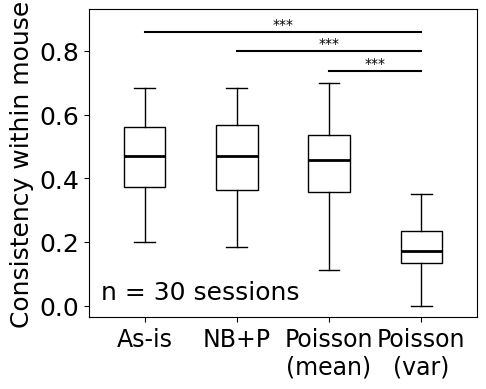

In [34]:
# RSA within session
num_sess = 32
num_cond = 4
n_neu_sampling = 10
list_corr_withinsess_concat = np.full((num_sess, num_cond, n_neu_sampling, 3), np.nan)

similarity_type = 'cos_sim'

method = 'resc_r'
n_samples = 500
use_rrep = True
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'

save_file_name = 'RSM_corr_withinsess_ABO_nb_sep_all_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR3.pickle' # same as above, slope 10, 1, 0, r=inf when var<mean, ignore median r if mu=0
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_concat[:, 0] = RSM_corr_withinsess_ABO_all['list_corr_withinsess_asis2'].copy()

n_samples = 50
use_rrep = False
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'
save_file_name = 'RSM_corr_withinsess_ABO_nb_sep_all_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR.pickle' # same as above, (slope 10, 1, 0, r=inf when var_G=0), (slope_ind 1 이외에는 nan, r=inf when var<mean) (500/50 samples, rcomb)
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_concat[:, 1] = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'][:, 1].copy()

method = 'rcomb'
save_file_name = 'RSM_corr_withinsess_ABO_poiss_sep_all_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR.pickle' # same as above, slope_ind 0 이외에는 nan, lam=mean for comb of neu/stim (500/50 samples)
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_concat[:, 2] = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'][:, 0].copy()

save_file_name = 'RSM_corr_withinsess_ABO_poiss_sep_all_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR2.pickle' # same as above, slope_ind 0 이외에는 nan, lam=var for comb of neu/stim (500/50 samples)
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_concat[:, 3] = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'][:, 0].copy()

# exclude session 0, 6
mask_06 = ~np.isin(range(num_sess), [0, 6])
list_corr_withinsess_concat = list_corr_withinsess_concat[mask_06].copy()

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

num_cond = list_corr_withinsess_concat.shape[1]

# box plot
center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = ['As-is', 'NB+P', 'Poisson\n(mean)', 'Poisson\n(var)']
d_x = 0

# Remove NaN
list_corr_withinsess_intv = list_corr_withinsess_concat[:, :, :, corr_ind].mean(axis=2)
list_corr_withinsess_intv_temp = np.empty(num_cond, dtype=object)
for intv_ind in range(num_cond):
    intv_temp = list_corr_withinsess_intv[:, intv_ind].copy()
    list_corr_withinsess_intv_temp[intv_ind] = intv_temp[~np.isnan(intv_temp)].copy()
box = axes[0].boxplot([list_corr_withinsess_intv_temp[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w') # box color
    median_.set(color='k', linewidth=2) # median line color

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], 0.9)
axes[0].set_ylim(axes[0].get_ylim()[0], 1.2)
axes[0].set_ylim(axes[0].get_ylim()[0], 0.71)
axes[0].set_ylim(axes[0].get_ylim()[0], 0.93)
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_corr_withinsess = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_corr_withinsess[pair_ind] = list(wilcoxon(list_corr_withinsess_intv[:, pair[0]], list_corr_withinsess_intv[:, pair[1]], nan_policy='omit'))[1]
    # print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_corr_withinsess[pair_ind]:.4f}')
list_pvals_corr_withinsess = np.array(multipletests(list_pvals_corr_withinsess, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_corr_withinsess[pair_ind]:.4f}')
whiskers = [get_upper_whisker(d) for d in list_corr_withinsess_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*num_cond, x_positions=center,
                      p_values=list_pvals_corr_withinsess, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)

# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
# axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=17)

axes[0].annotate(f'n = {list_corr_withinsess_intv.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\negbinom_RSA_within_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_RSA_within_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5g

In [35]:
# # Collect RSM for each session (across session pairs)
# similarity_type = 'cos_sim'

# method = 'resc_r'
# n_samples = 50
# use_rrep = True
# if not use_rrep: # one r for each combination of neuron and stimulus
#     method += '_rcomb'
# method = 'rcomb'

# list_target_slopes = [10, 1, 0]
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# list_RSM_mean_asis_ABO = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_RSM_mean_RRneuron2 = np.full((num_sess, len(list_target_slopes), num_trial_types, num_trial_types), np.nan)
# list_rate_RRneuron_dr2 = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     file_name = 'RSM_ABO_allneu_nb_sep_' + similarity_type  + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
#     file_name = 'RSM_ABO_allneu_poiss_sep_' + similarity_type  + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
#     file_name = 'RSM_ABO_allneu_katz_indep_sep_RRneuron_' + similarity_type  + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) +  '.pickle'
    
#     with open(file_name, 'rb') as f:
#         RSM_ABO = pickle.load(f)
#         list_RSM_mean_asis_ABO[sess_ind] = RSM_ABO['list_RSM_mean_asis'].copy()
#         list_RSM_mean_RRneuron2[sess_ind] = RSM_ABO['list_RSM_mean_RRneuron'].copy()
#         list_rate_RRneuron_dr2[sess_ind] = RSM_ABO['list_rate_RRneuron_dr'].copy()

# # Spearman correlation across session pairs
# sess_pairs = list(combinations(range(num_sess), 2))
# list_corr_sesspair_asis_ABO = np.zeros((len(sess_pairs), 3))
# list_corr_sesspair2 = np.zeros((len(sess_pairs), len(list_target_slopes), 3))
# for pair_ind, pair in enumerate(sess_pairs):
#     RSM_mean_neu1 = list_RSM_mean_asis_ABO[pair[0]].copy()
#     RSM_mean_neu2 = list_RSM_mean_asis_ABO[pair[1]].copy()

#     list_corr_sesspair_asis_ABO[pair_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#     bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#     list_corr_sesspair_asis_ABO[pair_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#     list_corr_sesspair_asis_ABO[pair_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())
    
#     for slope_ind, target_slope in enumerate(list_target_slopes):
#         RSM_mean_neu1 = list_RSM_mean_RRneuron2[pair[0], slope_ind].copy()
#         RSM_mean_neu2 = list_RSM_mean_RRneuron2[pair[1], slope_ind].copy()

#         list_corr_sesspair2[pair_ind, slope_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#         bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#         list_corr_sesspair2[pair_ind, slope_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#         list_corr_sesspair2[pair_ind, slope_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())

# save_file_name = 'RSM_ABO_all_allneu_nb_sep_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR.pickle'
# save_file_name = 'RSM_ABO_all_allneu_poiss_sep_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR2.pickle'
# save_file_name = 'RSM_ABO_all_allneu_katz_indep_sep_RRneuron_' + similarity_type + '_' + str(n_samples) + 'samples_realR3.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_RSM_mean_asis_ABO', 'list_corr_sesspair_asis_ABO', 'list_rate_RRneuron_dr2', 'list_RSM_mean_RRneuron2', 'list_corr_sesspair2'], \
#                  'list_RSM_mean_asis_ABO': list_RSM_mean_asis_ABO, 'list_corr_sesspair_asis_ABO': list_corr_sesspair_asis_ABO,
#                  'list_rate_RRneuron_dr2': list_rate_RRneuron_dr2, 'list_RSM_mean_RRneuron2': list_RSM_mean_RRneuron2, 'list_corr_sesspair2': list_corr_sesspair2}, f)
#     # pickle.dump({'tree_variables': ['list_RSM_mean_asis_ABO', 'list_corr_sesspair_asis_ABO', 'list_RSM_mean_RRneuron2', 'list_corr_sesspair2'], \
#     #              'list_RSM_mean_asis_ABO': list_RSM_mean_asis_ABO, 'list_corr_sesspair_asis_ABO': list_corr_sesspair_asis_ABO,
#     #              'list_RSM_mean_RRneuron2': list_RSM_mean_RRneuron2, 'list_corr_sesspair2': list_corr_sesspair2}, f)
#     # pickle.dump({'tree_variables': ['list_RSM_mean_asis_ABO', 'list_corr_sesspair_asis_ABO'], \
#     #              'list_RSM_mean_asis_ABO': list_RSM_mean_asis_ABO, 'list_corr_sesspair_asis_ABO': list_corr_sesspair_asis_ABO}, f)

As-is vs. NB+P p=0.3557188048243355
As-is vs. Poisson
(mean) p=1.5960417515691465e-10
As-is vs. Poisson
(var) p=3.5491748036349755e-72
NB+P vs. Poisson
(mean) p=1.5960417515691465e-10
NB+P vs. Poisson
(var) p=3.5491748036349755e-72
Poisson
(mean) vs. Poisson
(var) p=3.5491748036349755e-72


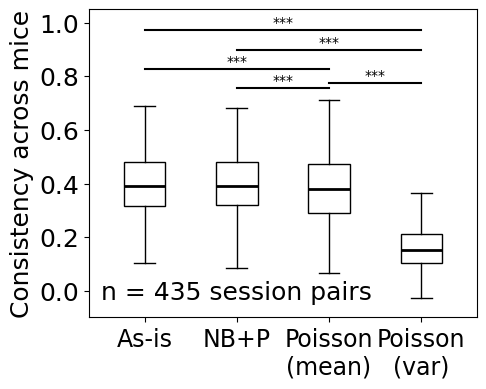

In [37]:
# RSA across sessions
num_sess = 32
num_cond = 4
list_corr_sesspair_concat = np.full((math.comb(num_sess, 2), num_cond, 3), np.nan)

similarity_type = 'cos_sim'

method = 'resc_r'
n_samples = 500
use_rrep = True
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'
save_file_name = 'RSM_ABO_all_allneu_nb_sep_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR3.pickle' # same as above, slope 10, 1, 0, r=inf when var<mean, ignore median r if mu=0
with open(save_file_name, 'rb') as f:
    RSM_ABO_all = pickle.load(f)
    list_corr_sesspair_concat[:, 0] = RSM_ABO_all['list_corr_sesspair_asis_ABO'].copy()

n_samples = 50
use_rrep = False
if not use_rrep: # one r for each combination of neuron and stimulus
    method += '_rcomb'
save_file_name = 'RSM_ABO_all_allneu_nb_sep_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR.pickle' # same as above, slope 10, 1, 0, r=inf when var_G=0, r=inf when var<mean (500/50 samples, rcomb)
with open(save_file_name, 'rb') as f:
    RSM_ABO_all = pickle.load(f)
    list_corr_sesspair_concat[:, 1] = RSM_ABO_all['list_corr_sesspair2'][:, 1].copy()

n_samples = 50
method = 'rcomb'
save_file_name = 'RSM_ABO_all_allneu_poiss_sep_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR.pickle' # same as above, slope_ind 0 이외에는 nan, lam=mean for comb of neu/stim (500/50 samples)
with open(save_file_name, 'rb') as f:
    RSM_ABO_all = pickle.load(f)
    list_corr_sesspair_concat[:, 2] = RSM_ABO_all['list_corr_sesspair2'][:, 0].copy()

n_samples = 50
save_file_name = 'RSM_ABO_all_allneu_poiss_sep_' + similarity_type + method + '_' + str(n_samples) + 'samples_realR2.pickle' # same as above, slope_ind 0 이외에는 nan, lam=var for comb of neu/stim (500/50 samples)
with open(save_file_name, 'rb') as f:
    RSM_ABO_all = pickle.load(f)
    list_corr_sesspair_concat[:, 3] = RSM_ABO_all['list_corr_sesspair2'][:, 0].copy()

# exclude session 0, 6
sess_pairs = np.array(list(combinations(range(num_sess), 2)))
mask_06 = ~np.any(np.isin(sess_pairs, [0, 6]), axis=1)
list_corr_sesspair_concat = list_corr_sesspair_concat[mask_06].copy()

corr_ind = 0

# fig, axes = plt.subplots(1, 1, figsize=(11, 4))
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

num_cond = list_corr_sesspair_concat.shape[1]

# box plot
center = np.arange(0.5, 0.5*num_cond+0.1, 0.5)
xticklabels = ['As-is', 'NB+P', 'Poisson\n(mean)', 'Poisson\n(var)']
d_x = 0

# Remove NaN
list_corr_sesspair_intv = list_corr_sesspair_concat[:, :, corr_ind].copy()
list_corr_sesspair_intv_temp = np.empty(num_cond, dtype=object)
for intv_ind in range(num_cond):
    intv_temp = list_corr_sesspair_intv[:, intv_ind].copy()
    list_corr_sesspair_intv_temp[intv_ind] = intv_temp[~np.isnan(intv_temp)].copy()
box = axes[0].boxplot([list_corr_sesspair_intv_temp[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True)
for box_, median_ in zip(box['boxes'], box['medians']):
    box_.set(facecolor='w') # box color
    median_.set(color='k', linewidth=2) # median line color
    
# significance
axes[0].set_ylim(axes[0].get_ylim()[0], 0.95)
axes[0].set_ylim(-0.1, 1.05)
# axes[0].set_ylim(-0.07, 0.85)
comb_intv = list(combinations(range(num_cond), 2))
list_pvals_corr_sesspair = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_corr_sesspair[pair_ind] = list(wilcoxon(list_corr_sesspair_intv[:, pair[0]], list_corr_sesspair_intv[:, pair[1]], nan_policy='omit'))[1]
list_pvals_corr_sesspair = np.array(multipletests(list_pvals_corr_sesspair, method='holm')[1]) # multiple comparisons correction
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_corr_sesspair[pair_ind]}')
whiskers = [get_upper_whisker(d) for d in list_corr_sesspair_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*num_cond, x_positions=center,
                      p_values=list_pvals_corr_sesspair, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)
# axes[0].set_yticks(np.arange(-0.2, 0.7, 0.2))

# axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
# axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=17)

axes[0].annotate(f'n = {list_corr_sesspair_concat.shape[0]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\negbinom_RSA_across_interval.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_RSA_across_interval.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 1a-c

In [38]:
# # Collecct model parameters for each session

# num_sess = 32

# list_r_estim_neu2 = np.empty(num_sess, dtype=object)
# list_p_estim_neu2 = np.empty(num_sess, dtype=object)
# list_rp_estim_neu2 = np.empty(num_sess, dtype=object)
# list_lll_estim_neu2 = np.empty(num_sess, dtype=object)

# list_nll_neu2 = np.empty(num_sess, dtype=object)
# list_aic_neu2 = np.empty(num_sess, dtype=object)
# list_rmse_neu2 = np.empty(num_sess, dtype=object)
# list_nll_neu_cv2 = np.empty(num_sess, dtype=object)
# list_aic_neu_cv2 = np.empty(num_sess, dtype=object)
# list_rmse_neu_cv2 = np.empty(num_sess, dtype=object)
# list_nll_neu_cv2_ns2sg = np.empty(num_sess, dtype=object)
# list_aic_neu_cv2_ns2sg = np.empty(num_sess, dtype=object)
# list_rmse_neu_cv2_ns2sg = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     file_name = 'poisson_fit_rp_sep_ABO_' + str(sess_ind) + '.pickle'
#     file_name = 'poisson_fit_rp_semipool_ABO_' + str(sess_ind) + '.pickle'
#     file_name = 'poisson_fit_lll_nbp_ABO_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         poisson_fit_rs_ABO = pickle.load(f)

#         # list_r_estim_neu2[sess_ind] = poisson_fit_rs_ABO['list_r_estim_neu'].copy()
#         # list_p_estim_neu2[sess_ind] = poisson_fit_rs_ABO['list_p_estim_neu'].copy()
#         # list_rp_estim_neu2[sess_ind] = poisson_fit_rs_ABO['list_rp_estim_neu'].copy()
#         list_lll_estim_neu2[sess_ind] = poisson_fit_rs_ABO['list_lll_estim_neu'].copy()
        
#         list_nll_neu2[sess_ind] = poisson_fit_rs_ABO['list_nll_neu'].copy()
#         list_aic_neu2[sess_ind] = poisson_fit_rs_ABO['list_aic_neu'].copy()
#         list_rmse_neu2[sess_ind] = poisson_fit_rs_ABO['list_rmse_neu'].copy()
#         list_nll_neu_cv2[sess_ind] = poisson_fit_rs_ABO['list_nll_neu_cv'].copy()
#         list_aic_neu_cv2[sess_ind] = poisson_fit_rs_ABO['list_aic_neu_cv'].copy()
#         list_rmse_neu_cv2[sess_ind] = poisson_fit_rs_ABO['list_rmse_neu_cv'].copy()
#         list_nll_neu_cv2_ns2sg[sess_ind] = poisson_fit_rs_ABO['list_nll_neu_cv_ns2sg'].copy()
#         list_aic_neu_cv2_ns2sg[sess_ind] = poisson_fit_rs_ABO['list_aic_neu_cv_ns2sg'].copy()
#         list_rmse_neu_cv2_ns2sg[sess_ind] = poisson_fit_rs_ABO['list_rmse_neu_cv_ns2sg'].copy()

# save_file_name = 'poisson_fit_rp_sep_ABO_all7.pickle'
# save_file_name = 'poisson_fit_rp_semipool_ABO_all12.pickle'
# save_file_name = 'poisson_fit_lll_nbp_ABO_all8.pickle'
# with open(save_file_name, 'wb') as f:
#     # pickle.dump({'tree_variables': ['list_r_estim_neu2', 'list_p_estim_neu2'],
#     #                 'list_r_estim_neu2': list_r_estim_neu2, 'list_p_estim_neu2': list_p_estim_neu2}, f)
#     # pickle.dump({'tree_variables': ['list_rp_estim_neu2', 'list_nll_neu2', 'list_aic_neu2', 'list_rmse_neu2', 'list_nll_neu_cv2', 'list_aic_neu_cv2', 'list_rmse_neu_cv2',
#     #                                 'list_nll_neu_cv2_ns2sg', 'list_aic_neu_cv2_ns2sg', 'list_rmse_neu_cv2_ns2sg'],
#     #              'list_rp_estim_neu2': list_rp_estim_neu2, 'list_nll_neu2': list_nll_neu2, 'list_aic_neu2': list_aic_neu2, 'list_rmse_neu2': list_rmse_neu2,
#     #              'list_nll_neu_cv2': list_nll_neu_cv2, 'list_aic_neu_cv2': list_aic_neu_cv2, 'list_rmse_neu_cv2': list_rmse_neu_cv2,
#     #              'list_nll_neu_cv2_ns2sg': list_nll_neu_cv2_ns2sg, 'list_aic_neu_cv2_ns2sg': list_aic_neu_cv2_ns2sg, 'list_rmse_neu_cv2_ns2sg': list_rmse_neu_cv2_ns2sg}, f)
#     pickle.dump({'tree_variables': ['list_lll_estim_neu2', 'list_nll_neu2', 'list_aic_neu2', 'list_rmse_neu2', 'list_nll_neu_cv2', 'list_aic_neu_cv2', 'list_rmse_neu_cv2',
#                                     'list_nll_neu_cv2_ns2sg', 'list_aic_neu_cv2_ns2sg', 'list_rmse_neu_cv2_ns2sg'],
#                  'list_lll_estim_neu2': list_lll_estim_neu2, 'list_nll_neu2': list_nll_neu2, 'list_aic_neu2': list_aic_neu2, 'list_rmse_neu2': list_rmse_neu2,
#                  'list_nll_neu_cv2': list_nll_neu_cv2, 'list_aic_neu_cv2': list_aic_neu_cv2, 'list_rmse_neu_cv2': list_rmse_neu_cv2,
#                  'list_nll_neu_cv2_ns2sg': list_nll_neu_cv2_ns2sg, 'list_aic_neu_cv2_ns2sg': list_aic_neu_cv2_ns2sg, 'list_rmse_neu_cv2_ns2sg': list_rmse_neu_cv2_ns2sg}, f)

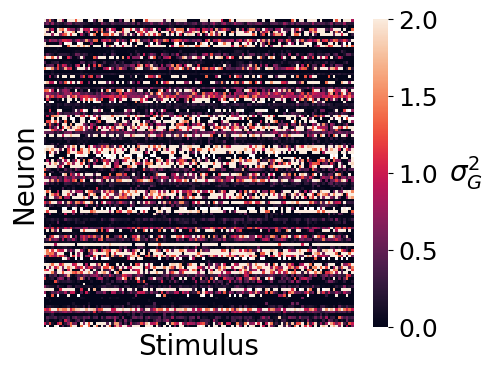

p = 3.851293617690939e-207


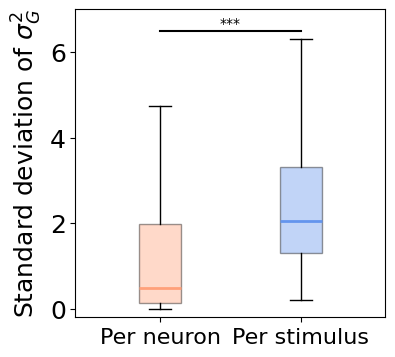

n = 1922 (per neuron), n = 3570 (per stimulus)
mean: 0.6029583832410436
std: 0.8466513472596313
median: 0.294314625671443
mean: 0.2545466946628391
std: 0.1530851591030131
median: 0.24366040958539445


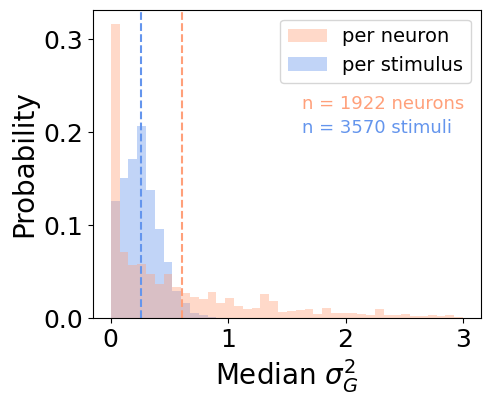

In [41]:
# sigma G across tt vs. across neurons (as-is) (individual trial type fitting) (heatmap, histogram)

save_file_name = 'poisson_fit_rp_sep_ABO_all2.pickle' # GLM, bfgs, r=inf when var<mean
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_r_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_r_estim_neu2'])
    list_p_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_p_estim_neu2'])
list_var_G_estim_neu2 = 1 / list_r_estim_neu2
num_sess = 32

list_var_G_estim_concat_asis = []
list_var_G_estim_acrtt_asis = np.zeros(0)
list_var_G_estim_acrneu_asis = np.zeros(0)
list_var_G_estim_std_acrtt_asis = np.zeros(0)
list_var_G_estim_std_acrneu_asis = np.zeros(0)
for sess_ind in range(num_sess):
    if sess_ind != 0 and sess_ind != 6:
        # heatmap
        list_var_G_estim_concat_asis.append(list_var_G_estim_neu2[sess_ind])

        # median
        list_var_G_estim_acrtt_asis = np.concatenate([list_var_G_estim_acrtt_asis, np.nanmedian(list_var_G_estim_neu2[sess_ind], axis=1)])
        list_var_G_estim_acrneu_asis = np.concatenate([list_var_G_estim_acrneu_asis, np.nanmedian(list_var_G_estim_neu2[sess_ind], axis=0)])

        # std
        var_G_estim_temp = list_var_G_estim_neu2[sess_ind].copy()
        list_var_G_estim_std_acrtt_asis = np.concatenate([list_var_G_estim_std_acrtt_asis, np.nanstd(var_G_estim_temp, axis=1, ddof=1)]) # across tt
        var_G_estim_temp = list_var_G_estim_neu2[sess_ind].copy()
        list_var_G_estim_std_acrneu_asis = np.concatenate([list_var_G_estim_std_acrneu_asis, np.nanstd(var_G_estim_temp, axis=0, ddof=1)]) # across neurons

list_var_G_estim_concat_asis = np.concatenate(list_var_G_estim_concat_asis)

# 1. heatmap
sess_ind = 3
cbar = True
figsize = (5, 4) if cbar else (4, 4)
vmin, vmax= (0, 2)
if cbar:
    fig, ax_hm, ax_cb = heatmap_cbar(list_var_G_estim_neu2[sess_ind],
                                     vmin=vmin, vmax=vmax,
                                    )
    ax_cb.tick_params(labelsize=18, rotation=0)
    ax_cb.set_ylabel('$\sigma^2_G$', fontsize=20, rotation=0, labelpad=20, y=0.5, va='center')

ax_hm.set_xlabel('Stimulus', fontsize=20)
ax_hm.set_ylabel('Neuron', fontsize=20)
# ax_hm.xaxis.set_label_position('top')
ax_hm.set_xticks([])
ax_hm.set_yticks([])

# # plt.savefig('code_images\\svg\\negbinom_sigmag_heatmap.svg', bbox_inches='tight', dpi=300)
# plt.savefig('code_images\\png\\negbinom_sigmag_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. boxplot of cv, std
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes = np.array(axes).flatten()

y = dc([list_var_G_estim_std_acrtt_asis[~np.isnan(list_var_G_estim_std_acrtt_asis)], list_var_G_estim_std_acrneu_asis[~np.isnan(list_var_G_estim_std_acrneu_asis)]])
n_box = len(y)
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)
xticklabels = ['Per neuron', 'Per stimulus']
d_x = np.full(n_box, 0)

box = axes[0].boxplot([y[intv_ind] for intv_ind in range(n_box)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
list_colors = ['lightsalmon', 'cornflowerblue']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2, alpha=1) # median line color

# significance
axes[0].set_ylim(-0.2, 7) # std
comb_intv = list(combinations(range(n_box), 2))
list_pvals_cv = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_cv[pair_ind] = list(mannwhitneyu(y[pair[0]], y[pair[1]]))[1]
list_pvals_cv = np.array(multipletests(list_pvals_cv, method='holm')[1]) # multiple comparisons correction
print(f'p = {list_pvals_cv[0]}')
whiskers = [get_upper_whisker(d) for d in y]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.01]*n_box, x_positions=center,
                      p_values=list_pvals_cv, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
axes[0].set_ylabel('Standard deviation of $\sigma_G^2$', fontsize=18)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=16)
axes[0].set_yticks(np.arange(0, 5, 2)) # cv
axes[0].set_yticks(np.arange(0, 7, 2)) # std

# # plt.savefig('code_images\\svg\\negbinom_sigmag_std_boxplot_asis.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_sigmag_std_boxplot_asis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'n = {len(list_var_G_estim_std_acrtt_asis[~np.isnan(list_var_G_estim_std_acrtt_asis)])} (per neuron), n = {len(list_var_G_estim_std_acrneu_asis[~np.isnan(list_var_G_estim_std_acrneu_asis)])} (per stimulus)')

# 3. histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# across tt
list_var_G_estim_acrtt = np.zeros(0)
for sess_ind in range(num_sess):
    if sess_ind != 0 and sess_ind != 6:
        list_var_G_estim_acrtt = np.concatenate([list_var_G_estim_acrtt, np.nanmedian(list_var_G_estim_neu2[sess_ind], axis=1)])

# print(list_var_G_estim_acrtt.shape) # number of total neurons across all sessions

weights = np.ones_like(list_var_G_estim_acrtt) / list_var_G_estim_acrtt.shape[0]
ax.hist(list_var_G_estim_acrtt, bins=40, range=(0, 3), weights=weights, color='lightsalmon', alpha=0.4, label='per neuron', zorder=2)
ax.axvline(np.nanmean(list_var_G_estim_acrtt), color='lightsalmon', linestyle='--')

print(f'mean: {np.nanmean(list_var_G_estim_acrtt)}\nstd: {np.nanstd(list_var_G_estim_acrtt, ddof=1)}\nmedian: {np.nanmedian(list_var_G_estim_acrtt)}')

# plt.show()

# across neurons
list_var_G_estim_acrneu = np.zeros(0)
for sess_ind in range(num_sess):
    if sess_ind != 0 and sess_ind != 6:
        list_var_G_estim_acrneu = np.concatenate([list_var_G_estim_acrneu, np.nanmedian(list_var_G_estim_neu2[sess_ind], axis=0)])

# print(list_var_G_estim_acrneu.shape) # num_trial_types x num_sessions

weights = np.ones_like(list_var_G_estim_acrneu) / list_var_G_estim_acrneu.shape[0]
ax.hist(list_var_G_estim_acrneu, bins=40, range=(0, 3), weights=weights, color='cornflowerblue', histtype='stepfilled', alpha=0.4, label='per stimulus', zorder=1)
ax.axvline(np.nanmean(list_var_G_estim_acrneu), color='cornflowerblue', linestyle='--')

ax.set_xlabel('Median $\sigma_G^2$', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.tick_params('both', labelsize=18)

ax.legend(prop={'size': 14})
ax.annotate(f'n = {list_var_G_estim_acrtt.shape[0]} neurons', xy=(0.54, 0.68), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_var_G_estim_acrneu.shape[0]} stimuli', xy=(0.54, 0.6), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

print(f'mean: {np.nanmean(list_var_G_estim_acrneu)}\nstd: {np.nanstd(list_var_G_estim_acrneu, ddof=1)}\nmedian: {np.nanmedian(list_var_G_estim_acrneu)}')

# # plt.savefig('code_images\\svg\\negbinom_sigmag_med_histogram_asis_2cond.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_sigmag_med_histogram_asis_2cond.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 1e left

session index: 3


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\pandas\core\internals\blocks.py:351: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
C:\Users\USER\AppData\Local\Temp\ipykernel_66692\4280365124.py:103: RuntimeWarning: divide by zero encountered in log10
  axes[examp_ind].plot(x, pow(10, slope_nb * np.log10(x) + intcpt_nb), color='g', linewidth=2.5, label='LLL', zorder=0)


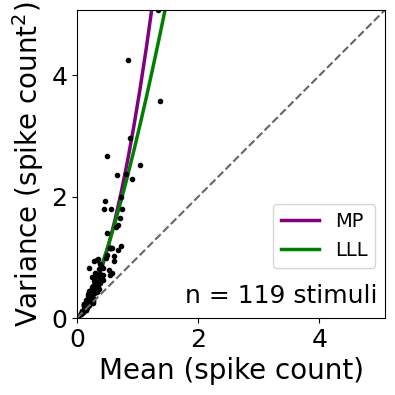

In [51]:
# Mean-variance plot across stimuli or across neurons (as-is & nb) (MP vs. LLL)

# MP
save_file_name = 'poisson_fit_rp_semipool_ABO_all6.pickle' # minimize_scalar (bounded Brent), nbp (var > mean), bounds 1e-3, 1e+3, use full/correct nll (use nansum)
save_file_name = 'poisson_fit_rp_semipool_ABO_all12.pickle' # same as save6, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_rp_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_rp_estim_neu2'])

# LLL
save_file_name = 'poisson_fit_lll_nbp_ABO_all3.pickle' # l-bfgs-b, log10(mean/var), use nansum in nll
save_file_name = 'poisson_fit_lll_nbp_ABO_all8.pickle' # same as save3, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_lll_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_lll_estim_neu2'])

# Iterate over all sessions
num_sess = 32
num_trial_types = 119
list_target_slopes = [10, 1, 0]
for sess_ind, rate in enumerate(list_rate_all):
    if sess_ind == 3:
        print(f'session index: {sess_ind}')
        
        rate_sorted = rate.sort_index(axis=1)
        stm = rate_sorted.columns.copy()

        # Multiply by delta t to convert to spike counts
        rate_sorted = rate_sorted * 0.25
        # print(rate_sorted.shape[0])

        # Create a counting dictionary for each stimulus
        all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
        stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

        # Compute mean & variance for each stimulus
        rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
        rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

        list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], \
                                    columns=rate_sorted_mean_coll.columns).copy()
                
        # MP
        r_estim_neu = list_rp_estim_neu2[sess_ind][:, 0]
        rescaled_r = r_estim_neu.copy() # num_neurons
        if rescaled_r.ndim == 1: # if rescaled_r's shape is (num_neurons,)
            rescaled_r = rescaled_r[:, np.newaxis]
        new_p = list_rp_estim_neu2[sess_ind][:, 1:].copy()

        # LLL
        list_lll_estim = list_lll_estim_neu2[sess_ind]
        list_a_estim, list_b_estim = list_lll_estim[:, 0], list_lll_estim[:, 1]
        list_a_estim, list_b_estim = list_a_estim[:, np.newaxis], list_b_estim[:, np.newaxis]
        rate_sorted_mean_coll_new = rate_sorted_mean_coll.values
        rate_sorted_var_coll_new = pow(10, list_a_estim * np.log10(rate_sorted_mean_coll) + list_b_estim).values

        # common
        rate_sorted_var_coll_new[np.isnan(rate_sorted_var_coll_new)] = rate_sorted_mean_coll.values[np.isnan(rate_sorted_var_coll_new)].copy()
        rate_sorted_var_coll_new = pd.DataFrame(rate_sorted_var_coll_new, columns=rate_sorted_var_coll.columns)
        rate_sorted_mean_coll_new[np.isnan(rate_sorted_mean_coll_new)] = rate_sorted_mean_coll.values[np.isnan(rate_sorted_mean_coll_new)].copy()
        rate_sorted_mean_coll_new = pd.DataFrame(rate_sorted_mean_coll_new, columns=rate_sorted_mean_coll.columns)
        
        # scatterplot
        examp_neus = [9]
        
        for examp_ind, examp_neu in enumerate(examp_neus):
            fig, axes = plt.subplots(1, 1, figsize=(4, 4))
            axes = np.array(axes).flatten()
            examp_ind = 0

            axes[examp_ind].set_aspect('equal')

            axes[examp_ind].scatter(rate_sorted_mean_coll.loc[examp_neu], rate_sorted_var_coll.loc[examp_neu], c='k', marker='.', zorder=1) # as-is

            # Range for x/y axes
            x = np.array([rate_sorted_mean_coll.loc[examp_neu], rate_sorted_var_coll.loc[examp_neu]])
            
            # # loglog
            # min_ = np.min(x[~np.isnan(x) & ~np.isinf(x)]) + 2**(-10)  # add pseudo-value to avoid log 0
            # max_ = np.max(x[~np.isnan(x) & ~np.isinf(x)]) * 2
            # axes[examp_ind].set_xscale('log')
            # axes[examp_ind].set_yscale('log')

            # arithmetic
            min_ = 0
            max_ = np.max(x[~np.isnan(x) & ~np.isinf(x)])
            axes[examp_ind].set_xticks(np.arange(0, 5, 2))
            axes[examp_ind].set_yticks(np.arange(0, 5, 2))
            
            axes[examp_ind].set_xlim(min_, max_)
            axes[examp_ind].set_ylim(min_, max_)

            # axes[examp_ind].set_title(f'Neuron {examp_neu}', fontsize=20)
            axes[examp_ind].set_xlabel('Mean (spike count)', fontsize=20)
            axes[examp_ind].set_ylabel('Variance (spike count$^2$)', fontsize=20)
            axes[examp_ind].tick_params(axis='both', labelsize=18)

            # lines
            x = np.linspace(min_, max_)
            axes[examp_ind].plot(x, x, color='0.4', linestyle='--') # y = x line
            axes[examp_ind].plot(x, (1/rescaled_r[examp_neu, 0])*x**2 + x, color='purple', linewidth=2.5, label='MP', zorder=0)
            slope_nb, intcpt_nb = list_lll_estim[examp_neu]
            axes[examp_ind].plot(x, pow(10, slope_nb * np.log10(x) + intcpt_nb), color='g', linewidth=2.5, label='LLL', zorder=0)
            # axes[examp_ind].plot(x, np.exp(slope_nb * np.log(x) + intcpt_nb), color='orangered', linestyle='--')
            # axes[examp_ind].annotate(f'slope {slope_nb:.2f}', xy=(0.5, 0.15), xycoords='axes fraction', color='orangered', fontsize=18)

            axes[examp_ind].annotate(f'n = {rate_sorted_mean_coll.shape[1]} stimuli', xy=(0.35, 0.05), xycoords='axes fraction', color='k', fontsize=18)
            axes[examp_ind].legend(loc='upper right', bbox_to_anchor=(1, 0.4), prop={'size': 14})
            
            # # plt.savefig(f'code_images\\svg\\negbinom_mvplot_mplll_neu{examp_neu}.svg', bbox_inches='tight')
            # # plt.savefig(f'code_images\\png\\negbinom_mvplot_mplll_neu{examp_neu}.png', dpi=300, bbox_inches='tight')
            # plt.savefig(f'code_images\\svg\\negbinom_mvplot_arith_mplll_neu{examp_neu}.svg', bbox_inches='tight')
            # plt.savefig(f'code_images\\png\\negbinom_mvplot_arith_mplll_neu{examp_neu}.png', dpi=300, bbox_inches='tight')
            plt.show()

## Supplementary Figure 1e right

session index: 3


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\pandas\core\internals\blocks.py:351: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
C:\Users\USER\AppData\Local\Temp\ipykernel_66692\4280365124.py:103: RuntimeWarning: divide by zero encountered in log10
  axes[examp_ind].plot(x, pow(10, slope_nb * np.log10(x) + intcpt_nb), color='g', linewidth=2.5, label='LLL', zorder=0)


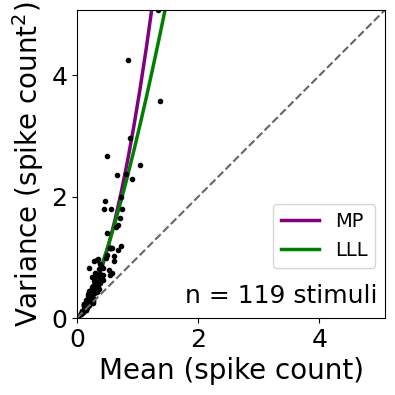

In [52]:
# Mean-variance plot across stimuli or across neurons (as-is & nb) (MP vs. LLL)

# MP
save_file_name = 'poisson_fit_rp_semipool_ABO_all6.pickle' # minimize_scalar (bounded Brent), nbp (var > mean), bounds 1e-3, 1e+3, use full/correct nll (use nansum)
save_file_name = 'poisson_fit_rp_semipool_ABO_all12.pickle' # same as save6, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_rp_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_rp_estim_neu2'])

# LLL
save_file_name = 'poisson_fit_lll_nbp_ABO_all3.pickle' # l-bfgs-b, log10(mean/var), use nansum in nll
save_file_name = 'poisson_fit_lll_nbp_ABO_all8.pickle' # same as save3, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_lll_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_lll_estim_neu2'])

# Iterate over all sessions
num_sess = 32
num_trial_types = 119
list_target_slopes = [10, 1, 0]
for sess_ind, rate in enumerate(list_rate_all):
    if sess_ind == 3:
        print(f'session index: {sess_ind}')
        
        rate_sorted = rate.sort_index(axis=1)
        stm = rate_sorted.columns.copy()

        # Multiply by delta t to convert to spike counts
        rate_sorted = rate_sorted * 0.25
        # print(rate_sorted.shape[0])

        # Create a counting dictionary for each stimulus
        all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
        stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

        # Compute mean & variance for each stimulus
        rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
        rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

        list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], \
                                    columns=rate_sorted_mean_coll.columns).copy()
                
        # MP
        r_estim_neu = list_rp_estim_neu2[sess_ind][:, 0]
        rescaled_r = r_estim_neu.copy() # num_neurons
        if rescaled_r.ndim == 1: # if rescaled_r's shape is (num_neurons,)
            rescaled_r = rescaled_r[:, np.newaxis]
        new_p = list_rp_estim_neu2[sess_ind][:, 1:].copy()

        # LLL
        list_lll_estim = list_lll_estim_neu2[sess_ind]
        list_a_estim, list_b_estim = list_lll_estim[:, 0], list_lll_estim[:, 1]
        list_a_estim, list_b_estim = list_a_estim[:, np.newaxis], list_b_estim[:, np.newaxis]
        rate_sorted_mean_coll_new = rate_sorted_mean_coll.values
        rate_sorted_var_coll_new = pow(10, list_a_estim * np.log10(rate_sorted_mean_coll) + list_b_estim).values

        # common
        rate_sorted_var_coll_new[np.isnan(rate_sorted_var_coll_new)] = rate_sorted_mean_coll.values[np.isnan(rate_sorted_var_coll_new)].copy()
        rate_sorted_var_coll_new = pd.DataFrame(rate_sorted_var_coll_new, columns=rate_sorted_var_coll.columns)
        rate_sorted_mean_coll_new[np.isnan(rate_sorted_mean_coll_new)] = rate_sorted_mean_coll.values[np.isnan(rate_sorted_mean_coll_new)].copy()
        rate_sorted_mean_coll_new = pd.DataFrame(rate_sorted_mean_coll_new, columns=rate_sorted_mean_coll.columns)
        
        # scatterplot
        examp_neus = [9]
        
        for examp_ind, examp_neu in enumerate(examp_neus):
            fig, axes = plt.subplots(1, 1, figsize=(4, 4))
            axes = np.array(axes).flatten()
            examp_ind = 0

            axes[examp_ind].set_aspect('equal')

            axes[examp_ind].scatter(rate_sorted_mean_coll.loc[examp_neu], rate_sorted_var_coll.loc[examp_neu], c='k', marker='.', zorder=1) # as-is

            # Range for x/y axes
            x = np.array([rate_sorted_mean_coll.loc[examp_neu], rate_sorted_var_coll.loc[examp_neu]])
            
            # # loglog
            # min_ = np.min(x[~np.isnan(x) & ~np.isinf(x)]) + 2**(-10)  # add pseudo-value to avoid log 0
            # max_ = np.max(x[~np.isnan(x) & ~np.isinf(x)]) * 2
            # axes[examp_ind].set_xscale('log')
            # axes[examp_ind].set_yscale('log')

            # arithmetic
            min_ = 0
            max_ = np.max(x[~np.isnan(x) & ~np.isinf(x)])
            axes[examp_ind].set_xticks(np.arange(0, 5, 2))
            axes[examp_ind].set_yticks(np.arange(0, 5, 2))
            
            axes[examp_ind].set_xlim(min_, max_)
            axes[examp_ind].set_ylim(min_, max_)

            # axes[examp_ind].set_title(f'Neuron {examp_neu}', fontsize=20)
            axes[examp_ind].set_xlabel('Mean (spike count)', fontsize=20)
            axes[examp_ind].set_ylabel('Variance (spike count$^2$)', fontsize=20)
            axes[examp_ind].tick_params(axis='both', labelsize=18)

            # lines
            x = np.linspace(min_, max_)
            axes[examp_ind].plot(x, x, color='0.4', linestyle='--') # y = x line
            axes[examp_ind].plot(x, (1/rescaled_r[examp_neu, 0])*x**2 + x, color='purple', linewidth=2.5, label='MP', zorder=0)
            slope_nb, intcpt_nb = list_lll_estim[examp_neu]
            axes[examp_ind].plot(x, pow(10, slope_nb * np.log10(x) + intcpt_nb), color='g', linewidth=2.5, label='LLL', zorder=0)
            # axes[examp_ind].plot(x, np.exp(slope_nb * np.log(x) + intcpt_nb), color='orangered', linestyle='--')
            # axes[examp_ind].annotate(f'slope {slope_nb:.2f}', xy=(0.5, 0.15), xycoords='axes fraction', color='orangered', fontsize=18)

            axes[examp_ind].annotate(f'n = {rate_sorted_mean_coll.shape[1]} stimuli', xy=(0.35, 0.05), xycoords='axes fraction', color='k', fontsize=18)
            axes[examp_ind].legend(loc='upper right', bbox_to_anchor=(1, 0.4), prop={'size': 14})
            
            # # plt.savefig(f'code_images\\svg\\negbinom_mvplot_mplll_neu{examp_neu}.svg', bbox_inches='tight')
            # # plt.savefig(f'code_images\\png\\negbinom_mvplot_mplll_neu{examp_neu}.png', dpi=300, bbox_inches='tight')
            # plt.savefig(f'code_images\\svg\\negbinom_mvplot_arith_mplll_neu{examp_neu}.svg', bbox_inches='tight')
            # plt.savefig(f'code_images\\png\\negbinom_mvplot_arith_mplll_neu{examp_neu}.png', dpi=300, bbox_inches='tight')
            plt.show()

## Supplementary Figure 1f left

MP nan 83/1877 neurons
LLL nan 0/1877 neurons
MP nan 83 neurons
LLL nan 0 neurons
MP vs. LLL ns p = 1.0226924255844355e-15, ns2sg p = 5.829527231322753e-51


C:\Users\USER\AppData\Local\Temp\ipykernel_66692\122439917.py:14: RuntimeWarning: Mean of empty slice
  list_nll_neu2_mp = [np.nanmean(list_nll_neu_cv2_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
C:\Users\USER\AppData\Local\Temp\ipykernel_66692\122439917.py:94: RuntimeWarning: Mean of empty slice
  list_nll_neu2_mp = [np.nanmean(list_nll_neu_cv2_ns2sg_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]


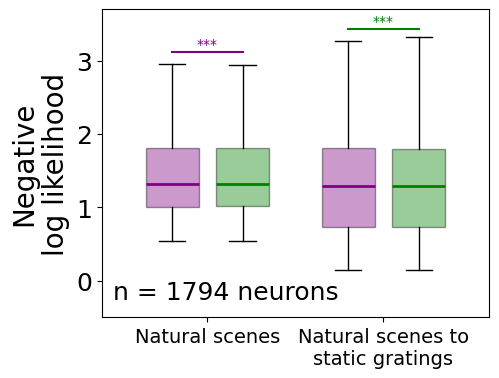

In [53]:
# Compare per-neuron mean-var model (nll)

# 1. natural scenes to natural scenes
num_sess = 32
n_splits = 10

save_file_name = 'poisson_fit_rp_semipool_ABO_all12.pickle' # same as save6, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_rp_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_rp_estim_neu2'])
    # list_nll_neu2_mp = dc(poisson_fit_rp_ABO_all['list_nll_neu2'])
    list_nll_neu_cv2_mp = dc(poisson_fit_rp_ABO_all['list_nll_neu_cv2'])
    list_nll_neu_cv2_ns2sg_mp = dc(poisson_fit_rp_ABO_all['list_nll_neu_cv2_ns2sg'])
list_nll_neu2_mp = [np.nanmean(list_nll_neu_cv2_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_nll_neu2_mp = np.array(list_nll_neu2_mp, dtype=object)

save_file_name = 'poisson_fit_lll_nbp_ABO_all8.pickle' # same as save3, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_lll_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_lll_estim_neu2'])
    # list_nll_neu2_lll = dc(poisson_fit_rp_ABO_all['list_nll_neu2'])
    list_nll_neu_cv2_lll = dc(poisson_fit_rp_ABO_all['list_nll_neu_cv2'])
    list_nll_neu_cv2_ns2sg_lll = dc(poisson_fit_rp_ABO_all['list_nll_neu_cv2_ns2sg'])
list_nll_neu2_lll = [np.nanmean(list_nll_neu_cv2_lll[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_nll_neu2_lll = np.array(list_nll_neu2_lll, dtype=object)

# negative log likelihood
bool_sess = ~np.isin(range(num_sess), [0, 6, 7])
list_nll_mp_flattened = np.concatenate(list_nll_neu2_mp[bool_sess])
list_nll_lll_flattened = np.concatenate(list_nll_neu2_lll[bool_sess])
list_nll_intv = np.stack([list_nll_mp_flattened, list_nll_lll_flattened])

num_cond = len(list_nll_intv)

# Remove NaN (only neurons with no NaN in both MP and LLL)
list_nll_intv_temp = np.empty(num_cond, dtype=object)
bool_notnan = ~np.isnan(list_nll_intv[0])
print(f'MP nan {np.sum(np.isnan(list_nll_intv[0]))}/{len(list_nll_intv[0])} neurons')
for intv_ind in range(num_cond):
    if intv_ind > 0:
        bool_notnan = bool_notnan & ~np.isnan(list_nll_intv[intv_ind])
        print(f'LLL nan {np.sum(np.isnan(list_nll_intv[intv_ind]))}/{len(list_nll_intv[intv_ind])} neurons')
for intv_ind in range(num_cond):
    intv_temp = list_nll_intv[intv_ind].copy()
    list_nll_intv_temp[intv_ind] = intv_temp[bool_notnan]
list_nll_intv = list_nll_intv_temp

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# box plot
center = np.full(num_cond, 0.5) # no subplots & subplots
xticklabels = ['Natural scenes', 'Natural scenes to\nstatic gratings'] # no subplots
d_x = [-0.1, 0.1]

box = axes[0].boxplot([list_nll_intv[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, label='ns')
list_colors = ['purple', 'green']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2) # median line color


# significance
axes[0].set_ylim(-0.5, 3.7) # test data, sg test all trials, likelihood mean

comb_intv = list(combinations(range(num_cond), 2))
list_pvals_nll = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_nll[pair_ind] = list(wilcoxon(list_nll_intv[pair[0]], list_nll_intv[pair[1]]))[1]
# list_pvals_nll = np.array(multipletests(list_pvals_nll, method='holm')[1]) # multiple comparisons correction
# for pair_ind, pair in enumerate(comb_intv):
#     # print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_nll[pair_ind]}')
#     print(f'MP vs. LLL p={list_pvals_nll[pair_ind]}')    
# # print(list_pvals_nll)
# whiskers = [get_upper_whisker(d) for d in list_nll_intv]
# add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*num_cond, x_positions=center+d_x,
#                       p_values=list_pvals_nll, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['purple'])

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)

axes[0].set_ylabel('Negative\nlog likelihood', fontsize=20)
axes[0].tick_params('both', labelsize=18)

# axes[0].annotate(f'n = {len(list_nll_intv[0])} neurons', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {len(list_nll_intv[0])} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.show()

# 2. natural scenes to static gratings
list_nll_neu2_mp = [np.nanmean(list_nll_neu_cv2_ns2sg_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_nll_neu2_mp = np.array(list_nll_neu2_mp, dtype=object)

list_nll_neu2_lll = [np.nanmean(list_nll_neu_cv2_ns2sg_lll[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_nll_neu2_lll = np.array(list_nll_neu2_lll, dtype=object)

# negative log likelihood
bool_sess = ~np.isin(range(num_sess), [0, 6, 7])
list_nll_mp_flattened = np.concatenate(list_nll_neu2_mp[bool_sess])
list_nll_lll_flattened = np.concatenate(list_nll_neu2_lll[bool_sess])
list_nll_intv_ns2sg = np.stack([list_nll_mp_flattened, list_nll_lll_flattened])

num_cond = len(list_nll_intv_ns2sg)

# Remove NaN (only neurons with no NaN in both MP and LLL)
list_nll_intv_ns2sg_temp = np.empty(num_cond, dtype=object)
bool_notnan = ~np.isnan(list_nll_intv_ns2sg[0])
print(f'MP nan {np.sum(np.isnan(list_nll_intv_ns2sg[0]))} neurons')
for intv_ind in range(num_cond):
    if intv_ind > 0:
        bool_notnan = bool_notnan & ~np.isnan(list_nll_intv_ns2sg[intv_ind])
        print(f'LLL nan {np.sum(np.isnan(list_nll_intv_ns2sg[intv_ind]))} neurons')
for intv_ind in range(num_cond):
    intv_temp = list_nll_intv_ns2sg[intv_ind].copy()
    list_nll_intv_ns2sg_temp[intv_ind] = intv_temp[bool_notnan]
list_nll_intv_ns2sg = list_nll_intv_ns2sg_temp

# fig, axes = plt.subplots(1, 1, figsize=(5, 4))
# axes = np.array(axes).flatten()

# box plot
center = np.full(num_cond, 1) # no subplots
xticklabels = ['Natural scenes', 'Natural scenes to\nstatic gratings'] # no subplots
d_x = [-0.1, 0.1]

box = axes[0].boxplot([list_nll_intv_ns2sg[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, label='ns2sg')
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4,
            #  hatch='///',
             ) # box color
    median_.set(color=color, linewidth=2) # median line color

# significance
axes[0].set_ylim(-0.5, 3.7) # test data, sg test all trials, likelihood mean

comb_intv = list(combinations(range(num_cond), 2))
list_pvals_nll_ns2sg = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_nll_ns2sg[pair_ind] = list(wilcoxon(list_nll_intv_ns2sg[pair[0]], list_nll_intv_ns2sg[pair[1]]))[1]
# list_pvals_nll_ns2sg = np.array(multipletests(list_pvals_nll_ns2sg, method='holm')[1]) # multiple comparisons correction
# for pair_ind, pair in enumerate(comb_intv):
#     # print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_nll_ns2sg[pair_ind]}')
#     print(f'MP vs. LLL p={list_pvals_nll_ns2sg[pair_ind]}')
# # print(list_pvals_nll_ns2sg)
list_pvals_nll_concat = np.concatenate([list_pvals_nll, list_pvals_nll_ns2sg])
list_pvals_nll_concat = np.array(multipletests(list_pvals_nll_concat, method='holm')[1]) # multiple comparisons correction
print(f'MP vs. LLL ns p = {list_pvals_nll_concat[0]}, ns2sg p = {list_pvals_nll_concat[1]}')

center_ns = np.full(num_cond, 0.5) # no subplots & subplots
whiskers = [get_upper_whisker(d) for d in list_nll_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*num_cond, x_positions=center_ns+d_x,
                      p_values=[list_pvals_nll_concat[0]], gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['purple'])
whiskers = [get_upper_whisker(d) for d in list_nll_intv_ns2sg]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.01]*num_cond, x_positions=center+d_x,
                      p_values=[list_pvals_nll_concat[1]], gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['green'])

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5) # no subplots
axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)

axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=14)

# legend_elements = [patches.Patch(facecolor='lightgray', edgecolor='black', label='ns'),
#                    patches.Patch(facecolor='lightgray', edgecolor='black', hatch='//', label='ns2sg')]
# axes[0].legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})

axes[0].annotate(f'n = {len(list_nll_intv_ns2sg[0])} neurons', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {len(list_nll_intv_ns2sg[0])} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\negbinom_nll_mplll.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_nll_mplll.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 1f middle

C:\Users\USER\AppData\Local\Temp\ipykernel_66692\25274444.py:14: RuntimeWarning: Mean of empty slice
  list_aic_neu2_mp = [np.nanmean(list_aic_neu_cv2_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
C:\Users\USER\AppData\Local\Temp\ipykernel_66692\25274444.py:93: RuntimeWarning: Mean of empty slice
  list_aic_neu2_mp = [np.nanmean(list_aic_neu_cv2_ns2sg_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]


MP nan 83/1877 neurons
LLL nan 0/1877 neurons
MP nan 83 neurons
LLL nan 0 neurons
MP vs. LLL ns p = 2.4273108413166102e-294, ns2sg p = 2.9147636156613764e-51


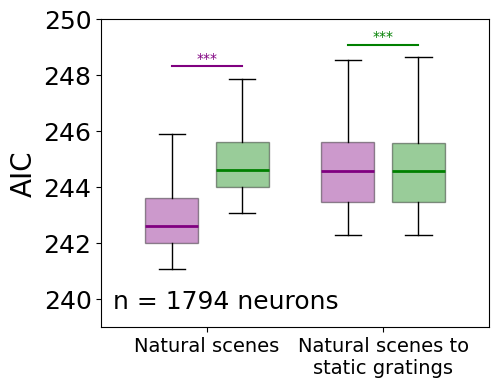

In [54]:
# Compare per-neuron mean-var model (aic)

# 1. natural scenes to natural scenes
num_sess = 32
n_splits = 10

save_file_name = 'poisson_fit_rp_semipool_ABO_all12.pickle' # same as save6, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_rp_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_rp_estim_neu2'])
    # list_aic_neu2_mp = dc(poisson_fit_rp_ABO_all['list_aic_neu2'])
    list_aic_neu_cv2_mp = dc(poisson_fit_rp_ABO_all['list_aic_neu_cv2'])
    list_aic_neu_cv2_ns2sg_mp = dc(poisson_fit_rp_ABO_all['list_aic_neu_cv2_ns2sg'])
list_aic_neu2_mp = [np.nanmean(list_aic_neu_cv2_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_aic_neu2_mp = np.array(list_aic_neu2_mp, dtype=object)

save_file_name = 'poisson_fit_lll_nbp_ABO_all8.pickle' # same as save3, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_lll_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_lll_estim_neu2'])
    # list_aic_neu2_lll = dc(poisson_fit_rp_ABO_all['list_aic_neu2'])
    list_aic_neu_cv2_lll = dc(poisson_fit_rp_ABO_all['list_aic_neu_cv2'])
    list_aic_neu_cv2_ns2sg_lll = dc(poisson_fit_rp_ABO_all['list_aic_neu_cv2_ns2sg'])
list_aic_neu2_lll = [np.nanmean(list_aic_neu_cv2_lll[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_aic_neu2_lll = np.array(list_aic_neu2_lll, dtype=object)

# negative log likelihood
bool_sess = ~np.isin(range(num_sess), [0, 6, 7])
list_aic_mp_flattened = np.concatenate(list_aic_neu2_mp[bool_sess])
list_aic_lll_flattened = np.concatenate(list_aic_neu2_lll[bool_sess])
list_aic_intv = np.stack([list_aic_mp_flattened, list_aic_lll_flattened])

num_cond = len(list_aic_intv)

# Remove NaN (only neurons with no NaN in both MP and LLL)
list_aic_intv_temp = np.empty(num_cond, dtype=object)
bool_notnan = ~np.isnan(list_aic_intv[0])
print(f'MP nan {np.sum(np.isnan(list_aic_intv[0]))}/{len(list_aic_intv[0])} neurons')
for intv_ind in range(num_cond):
    if intv_ind > 0:
        bool_notnan = bool_notnan & ~np.isnan(list_aic_intv[intv_ind])
        print(f'LLL nan {np.sum(np.isnan(list_aic_intv[intv_ind]))}/{len(list_aic_intv[intv_ind])} neurons')
for intv_ind in range(num_cond):
    intv_temp = list_aic_intv[intv_ind].copy()
    list_aic_intv_temp[intv_ind] = intv_temp[bool_notnan]
list_aic_intv = list_aic_intv_temp

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# box plot
center = np.full(num_cond, 0.5) # no subplots & subplots
xticklabels = ['Natural scenes', 'Natural scenes to\nstatic gratings'] # no subplots
d_x = [-0.1, 0.1]

box = axes[0].boxplot([list_aic_intv[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, label='ns')
list_colors = ['purple', 'green']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2) # median line color

# significance
axes[0].set_ylim(239, 250) # test data, sg test all trials, likelihood mean

comb_intv = list(combinations(range(num_cond), 2))
list_pvals_aic = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_aic[pair_ind] = list(wilcoxon(list_aic_intv[pair[0]], list_aic_intv[pair[1]]))[1]
# list_pvals_aic = np.array(multipletests(list_pvals_aic, method='holm')[1]) # multiple comparisons correction
# for pair_ind, pair in enumerate(comb_intv):
#     # print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_aic[pair_ind]}')
#     print(f'MP vs. LLL p={list_pvals_aic[pair_ind]}')    
# # print(list_pvals_aic)
# whiskers = [get_upper_whisker(d) for d in list_aic_intv]
# add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.001]*num_cond, x_positions=center+d_x,
#                       p_values=list_pvals_aic, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['purple'])

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)

axes[0].set_ylabel('AIC', fontsize=20)
axes[0].tick_params('both', labelsize=18)

# axes[0].annotate(f'n = {len(list_aic_intv[0])} neurons', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {len(list_aic_intv[0])} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.show()

# 2. natural scenes to static gratings
list_aic_neu2_mp = [np.nanmean(list_aic_neu_cv2_ns2sg_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_aic_neu2_mp = np.array(list_aic_neu2_mp, dtype=object)

list_aic_neu2_lll = [np.nanmean(list_aic_neu_cv2_ns2sg_lll[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_aic_neu2_lll = np.array(list_aic_neu2_lll, dtype=object)

# negative log likelihood
bool_sess = ~np.isin(range(num_sess), [0, 6, 7])
list_aic_mp_flattened = np.concatenate(list_aic_neu2_mp[bool_sess])
list_aic_lll_flattened = np.concatenate(list_aic_neu2_lll[bool_sess])
list_aic_intv_ns2sg = np.stack([list_aic_mp_flattened, list_aic_lll_flattened])

num_cond = len(list_aic_intv_ns2sg)

# Remove NaN (only neurons with no NaN in both MP and LLL)
list_aic_intv_ns2sg_temp = np.empty(num_cond, dtype=object)
bool_notnan = ~np.isnan(list_aic_intv_ns2sg[0])
print(f'MP nan {np.sum(np.isnan(list_aic_intv_ns2sg[0]))} neurons')
for intv_ind in range(num_cond):
    if intv_ind > 0:
        bool_notnan = bool_notnan & ~np.isnan(list_aic_intv_ns2sg[intv_ind])
        print(f'LLL nan {np.sum(np.isnan(list_aic_intv_ns2sg[intv_ind]))} neurons')
for intv_ind in range(num_cond):
    intv_temp = list_aic_intv_ns2sg[intv_ind].copy()
    list_aic_intv_ns2sg_temp[intv_ind] = intv_temp[bool_notnan]
list_aic_intv_ns2sg = list_aic_intv_ns2sg_temp

# fig, axes = plt.subplots(1, 1, figsize=(5, 4))
# axes = np.array(axes).flatten()

# box plot
center = np.full(num_cond, 1) # no subplots
xticklabels = ['Natural scenes', 'Natural scenes to\nstatic gratings']
d_x = [-0.1, 0.1]

box = axes[0].boxplot([list_aic_intv_ns2sg[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, label='ns2sg')
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4,
            #  hatch='///',
             ) # box color
    median_.set(color=color, linewidth=2) # median line color

# significance
axes[0].set_ylim(239, 250) # test data, sg test all trials, likelihood mean

comb_intv = list(combinations(range(num_cond), 2))
list_pvals_aic_ns2sg = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_aic_ns2sg[pair_ind] = list(wilcoxon(list_aic_intv_ns2sg[pair[0]], list_aic_intv_ns2sg[pair[1]]))[1]
# list_pvals_aic_ns2sg = np.array(multipletests(list_pvals_aic_ns2sg, method='holm')[1]) # multiple comparisons correction
# for pair_ind, pair in enumerate(comb_intv):
#     # print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_aic_ns2sg[pair_ind]}')
#     print(f'MP vs. LLL p={list_pvals_aic_ns2sg[pair_ind]}')
# # print(list_pvals_aic_ns2sg)

list_pvals_aic_concat = np.concatenate([list_pvals_aic, list_pvals_aic_ns2sg])
list_pvals_aic_concat = np.array(multipletests(list_pvals_aic_concat, method='holm')[1]) # multiple comparisons correction
print(f'MP vs. LLL ns p = {list_pvals_aic_concat[0]}, ns2sg p = {list_pvals_aic_concat[1]}')
center_ns = np.full(num_cond, 0.5) # no subplots & subplots
whiskers = [get_upper_whisker(d) for d in list_aic_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.001]*num_cond, x_positions=center_ns+d_x,
                      p_values=[list_pvals_aic_concat[0]], gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['purple'])
whiskers = [get_upper_whisker(d) for d in list_aic_intv_ns2sg]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.001]*num_cond, x_positions=center+d_x,
                      p_values=[list_pvals_aic_concat[1]], gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['green'])

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5) # no subplots
axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=14)

# legend_elements = [patches.Patch(facecolor='lightgray', edgecolor='black', label='ns'),
#                    patches.Patch(facecolor='lightgray', edgecolor='black', hatch='//', label='ns2sg')]
# axes[0].legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})

axes[0].annotate(f'n = {len(list_aic_intv_ns2sg[0])} neurons', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {len(list_aic_intv_ns2sg[0])} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\negbinom_aic_mplll.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_aic_mplll.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 1f right

MP vs. LLL ns p = 4.297799649691269e-158, ns2sg p = 5.452376371546738e-52


C:\Users\USER\AppData\Local\Temp\ipykernel_66692\153106240.py:14: RuntimeWarning: Mean of empty slice
  list_rmse_neu2_mp = [np.nanmean(list_rmse_neu_cv2_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
C:\Users\USER\AppData\Local\Temp\ipykernel_66692\153106240.py:90: RuntimeWarning: Mean of empty slice
  list_rmse_neu2_mp = [np.nanmean(list_rmse_neu_cv2_ns2sg_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]


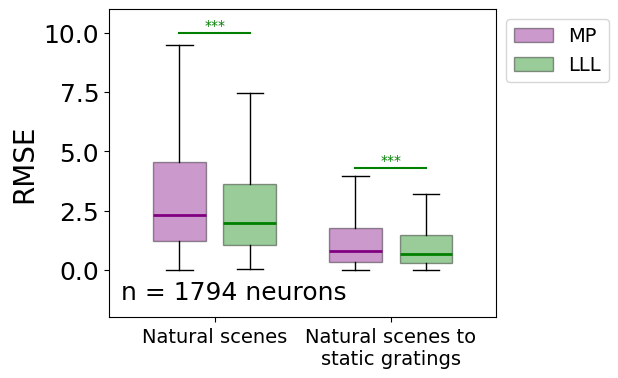

In [56]:
# Compare per-neuron mean-var model (rmse)

# 1. natural scenes to natural scenes
num_sess = 32
n_splits = 10

save_file_name = 'poisson_fit_rp_semipool_ABO_all12.pickle' # same as save6, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_rp_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_rp_estim_neu2'])
    # list_rmse_neu2_mp = dc(poisson_fit_rp_ABO_all['list_rmse_neu2'])
    list_rmse_neu_cv2_mp = dc(poisson_fit_rp_ABO_all['list_rmse_neu_cv2'])
    list_rmse_neu_cv2_ns2sg_mp = dc(poisson_fit_rp_ABO_all['list_rmse_neu_cv2_ns2sg'])
list_rmse_neu2_mp = [np.nanmean(list_rmse_neu_cv2_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_rmse_neu2_mp = np.array(list_rmse_neu2_mp, dtype=object)

save_file_name = 'poisson_fit_lll_nbp_ABO_all8.pickle' # same as save3, include cv, include ns2sg, sg test all trials, use likelihood mean, ns2sg num_params=num_params_sg
with open(save_file_name, 'rb') as f:
    poisson_fit_rp_ABO_all = pickle.load(f)
    list_lll_estim_neu2 = dc(poisson_fit_rp_ABO_all['list_lll_estim_neu2'])
    # list_rmse_neu2_lll = dc(poisson_fit_rp_ABO_all['list_rmse_neu2'])
    list_rmse_neu_cv2_lll = dc(poisson_fit_rp_ABO_all['list_rmse_neu_cv2'])
    list_rmse_neu_cv2_ns2sg_lll = dc(poisson_fit_rp_ABO_all['list_rmse_neu_cv2_ns2sg'])
list_rmse_neu2_lll = [np.nanmean(list_rmse_neu_cv2_lll[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_rmse_neu2_lll = np.array(list_rmse_neu2_lll, dtype=object)

# RMSE
bool_sess = ~np.isin(range(num_sess), [0, 6])
list_rmse_mp_flattened = np.concatenate(list_rmse_neu2_mp[bool_sess])
list_rmse_lll_flattened = np.concatenate(list_rmse_neu2_lll[bool_sess])
list_rmse_intv = np.stack([list_rmse_mp_flattened, list_rmse_lll_flattened])

num_cond = len(list_rmse_intv)

# Remove NaN (only neurons with no NaN in both MP and LLL)
list_rmse_intv_temp = np.empty(num_cond, dtype=object)
bool_nan = ~np.isnan(list_rmse_intv[0])
for intv_ind in range(num_cond):
    if intv_ind > 0:
        bool_nan = bool_nan & ~np.isnan(list_rmse_intv[intv_ind])
for intv_ind in range(num_cond):
    intv_temp = list_rmse_intv[intv_ind].copy()
    list_rmse_intv_temp[intv_ind] = intv_temp[bool_nan]
list_rmse_intv = list_rmse_intv_temp

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# box plot
center = np.full(num_cond, 0.5)
xticklabels = ['Natural scenes', 'Natural scenes to\nstatic gratings']
d_x = [-0.1, 0.1]

box = axes[0].boxplot([list_rmse_intv[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True)
list_colors = ['purple', 'green']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2) # median line color

# significance
axes[0].set_ylim(-2, 11) # test data, sg test all trials, no subplots

comb_intv = list(combinations(range(num_cond), 2))
list_pvals_rmse = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_rmse[pair_ind] = list(wilcoxon(list_rmse_intv[pair[0]], list_rmse_intv[pair[1]]))[1]
# list_pvals_rmse = np.array(multipletests(list_pvals_rmse, method='holm')[1]) # multiple comparisons correction
# for pair_ind, pair in enumerate(comb_intv):
#     print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_rmse[pair_ind]}')
# # print(list_pvals_rmse)
# whiskers = [get_upper_whisker(d) for d in list_rmse_intv]
# add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*num_cond, x_positions=center+d_x,
#                       p_values=list_pvals_rmse, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['green'])

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)

axes[0].set_ylabel('RMSE', fontsize=20)
axes[0].tick_params('both', labelsize=18)

# axes[0].annotate(f'n = {len(list_rmse_intv[0])} neurons', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# # axes[0].annotate(f'n = {len(list_rmse_intv[0])} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.show()

# 2. natural scenes to static gratings
list_rmse_neu2_mp = [np.nanmean(list_rmse_neu_cv2_ns2sg_mp[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_rmse_neu2_mp = np.array(list_rmse_neu2_mp, dtype=object)

list_rmse_neu2_lll = [np.nanmean(list_rmse_neu_cv2_ns2sg_lll[sess_ind], axis=1) for sess_ind in range(num_sess)]
list_rmse_neu2_lll = np.array(list_rmse_neu2_lll, dtype=object)

# RMSE
bool_sess = ~np.isin(range(num_sess), [0, 6, 7])
list_rmse_mp_flattened = np.concatenate(list_rmse_neu2_mp[bool_sess])
list_rmse_lll_flattened = np.concatenate(list_rmse_neu2_lll[bool_sess])
list_rmse_intv_ns2sg = np.stack([list_rmse_mp_flattened, list_rmse_lll_flattened])

num_cond = len(list_rmse_intv_ns2sg)

# Remove NaN (only neurons with no NaN in both MP and LLL)
list_rmse_intv_ns2sg_temp = np.empty(num_cond, dtype=object)
bool_nan = ~np.isnan(list_rmse_intv_ns2sg[0])
for intv_ind in range(num_cond):
    if intv_ind > 0:
        bool_nan = bool_nan & ~np.isnan(list_rmse_intv_ns2sg[intv_ind])
for intv_ind in range(num_cond):
    intv_temp = list_rmse_intv_ns2sg[intv_ind].copy()
    list_rmse_intv_ns2sg_temp[intv_ind] = intv_temp[bool_nan]
list_rmse_intv_ns2sg = list_rmse_intv_ns2sg_temp

# fig, axes = plt.subplots(1, 1, figsize=(5, 4))
# axes = np.array(axes).flatten()

# box plot
center = np.full(num_cond, 1)
xticklabels = ['Natural scenes', 'Natural scenes to\nstatic gratings']
d_x = [-0.1, 0.1]

box = axes[0].boxplot([list_rmse_intv_ns2sg[intv_ind] for intv_ind in range(num_cond)], positions=center+d_x,
                      showfliers=False, patch_artist=True, label=['MP', 'LLL'])
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4,
            #  hatch='///',
             ) # box color
    median_.set(color=color, linewidth=2) # median line color

# significance
axes[0].set_ylim(-2, 11) # test data, sg test all trials, no subplots

comb_intv = list(combinations(range(num_cond), 2))
list_pvals_rmse_ns2sg = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    list_pvals_rmse_ns2sg[pair_ind] = list(wilcoxon(list_rmse_intv_ns2sg[pair[0]], list_rmse_intv_ns2sg[pair[1]]))[1]
# list_pvals_rmse_ns2sg = np.array(multipletests(list_pvals_rmse_ns2sg, method='holm')[1]) # multiple comparisons correction
# for pair_ind, pair in enumerate(comb_intv):
#     print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_rmse_ns2sg[pair_ind]}')
# # print(list_pvals_rmse_ns2sg)
list_pvals_rmse_concat = np.concatenate([list_pvals_rmse, list_pvals_rmse_ns2sg])
list_pvals_rmse_concat = np.array(multipletests(list_pvals_rmse_concat, method='holm')[1]) # multiple comparisons correction
print(f'MP vs. LLL ns p = {list_pvals_rmse_concat[0]}, ns2sg p = {list_pvals_rmse_concat[1]}')

center_ns = np.full(num_cond, 0.5)
whiskers = [get_upper_whisker(d) for d in list_rmse_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*num_cond, x_positions=center_ns+d_x,
                      p_values=[list_pvals_rmse_concat[0]], gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['green'])
whiskers = [get_upper_whisker(d) for d in list_rmse_intv_ns2sg]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*num_cond, x_positions=center+d_x,
                      p_values=[list_pvals_rmse_concat[1]], gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1, colors=['green'])

center = np.arange(0.5, 0.5*num_cond+0.1, 0.5) # no subplots
axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels, rotation=0)
axes[0].tick_params('both', labelsize=18)
axes[0].tick_params('x', labelsize=14)
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})

# legend_elements = [patches.Patch(facecolor='lightgray', edgecolor='black', label='ns'),
#                    patches.Patch(facecolor='lightgray', edgecolor='black', hatch='//', label='ns2sg')]
# axes[0].legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})

axes[0].annotate(f'n = {len(list_rmse_intv_ns2sg[0])} neurons', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {len(list_rmse_intv_ns2sg[0])} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\negbinom_rmse_mplll.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_rmse_mplll.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 11a

rng_seed 64
sess_ind 16
trial_type_ind 112
neu_ind 43


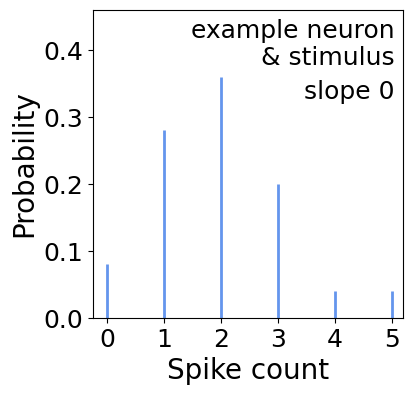

In [58]:
# spike count needle plot
n_samples = 50
file_name = 'rate_katz_indep_ABO_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(file_name, 'rb') as f:
    rate_nb_copula_ABO = pickle.load(f)
    list_rate_katz_RRneuron2 = rate_nb_copula_ABO['list_rate_katz_RRneuron2'].copy()

fig, ax = plt.subplots(figsize=(4, 4))

rng = np.random.default_rng()
rng_seed = rng.choice(range(100), 1)[0]
rng_seed = 64 # katz50, single stimulus
print(f'rng_seed {rng_seed}')
rng = np.random.default_rng(rng_seed)

num_sess = 32
sess_ind = rng.choice(range(num_sess), 1)[0]
print(f'sess_ind {sess_ind}')
slope_ind = 0
num_trial_types = 119
trial_type_ind = rng.choice(range(num_trial_types), 1)[0]
print(f'trial_type_ind {trial_type_ind}')

spkcnt = list_rate_katz_RRneuron2[sess_ind][slope_ind][:, trial_type_ind*n_samples:(trial_type_ind+1)*n_samples]

num_neurons = spkcnt.shape[0]
neu_ind = rng.choice(range(num_neurons), 1)[0]
print(f'neu_ind {neu_ind}')

spkcnt = spkcnt[neu_ind].astype(int).copy()
counts = np.bincount(spkcnt)
x = np.arange(len(counts))
y = counts / spkcnt.shape[0]
ax.vlines(x=x, ymin=0, ymax=y, linewidth=2, color='cornflowerblue')

ax.set_xlim(ax.get_xlim()[0], np.max(x)+0.2) # katz50, single stimulus
ax.set_xticks(np.arange(0, ax.get_xlim()[1], 1))
ax.set_ylim(0, np.max(y)+0.1) # katz50, single stimulus
ax.set_yticks(np.arange(0, ax.get_ylim()[1]+0.01, 0.1))

ax.set_xlabel('Spike count', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.tick_params('both', labelsize=18)

ax.annotate(f'example neuron\n& stimulus', xy=(0.315, 0.82), xycoords='axes fraction', fontsize=18, color='k', multialignment='right') # figsize (4, 4)
ax.annotate(f'slope 0', xy=(0.68, 0.71), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\negbinom_nbp_needleplot.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_nbp_needleplot.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_katz_needleplot.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_katz_needleplot.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\negbinom_katz_indep_needleplot.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_katz_indep_needleplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 11b

session index: 3
target_slope 0.0


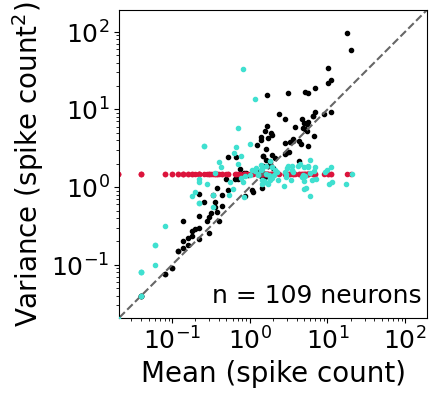

target_slope 1.0


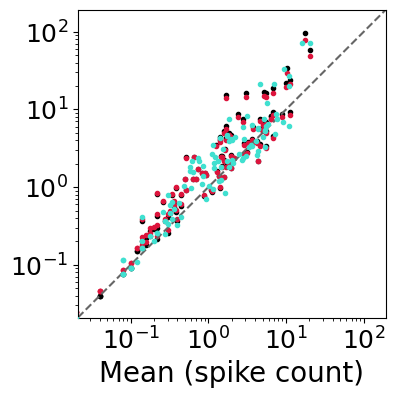

target_slope 2.0


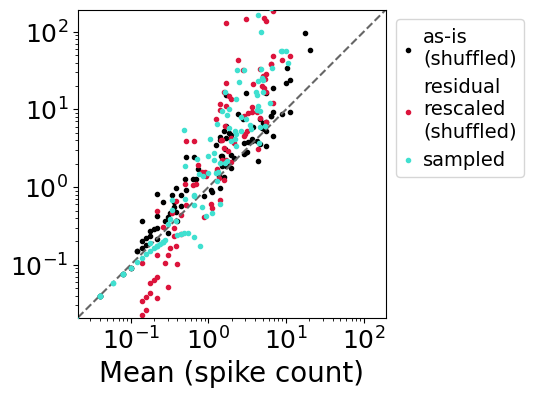

In [ ]:
# Mean-variance plot across stimuli or across neurons (as-is & nb)

n_samples = 50
file_name = 'rate_katz_indep_ABO_sep_RRneuron_' + str(n_samples) + 'samples_realR_all.pickle' # slope 0-2, poiss margin 0.05, binom n>=1 (50 samples)
file_name = 'rate_katz_indep_ABO_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(file_name, 'rb') as f:
    rate_nb_copula_ABO = pickle.load(f)
    list_rate_katz_asis_rep = rate_nb_copula_ABO['list_rate_katz_asis'].copy()
    list_rate_katz_RRneuron2_rep = rate_nb_copula_ABO['list_rate_katz_RRneuron2'].copy()

# Iterate over all sessions
num_sess = 32
num_trial_types = 119
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
for sess_ind, rate in enumerate(list_rate_all):
    if sess_ind == 3:
        print(f'session index: {sess_ind}')
        rng = np.random.default_rng(sess_ind)
        
        rate_sorted = rate.sort_index(axis=1)
        stm = rate_sorted.columns.copy()

        # Multiply by delta t to convert to spike counts
        rate_sorted = rate_sorted * 0.25
        # print(rate_sorted.shape[0])

        # Create a counting dictionary for each stimulus
        all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
        stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

        # trial shuffling
        rate_shuf = pd.DataFrame(np.zeros_like(rate_sorted), columns=rate_sorted.columns)
        for neu_ind in range(rate_sorted.shape[0]):
            for trial_type_ind, trial_type in enumerate(all_stm_unique):
                shuf_inds = rng.permutation(rate_sorted.loc[:, trial_type].shape[1])
                rate_shuf.loc[neu_ind, trial_type] = rate_sorted.loc[neu_ind, trial_type].iloc[shuf_inds]
        rate_sorted = rate_shuf.copy()

        # Compute mean & variance for each stimulus
        rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
        rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

        list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], \
                                    columns=rate_sorted_mean_coll.columns).copy()

        for slope_ind, target_slope in enumerate(list_target_slopes):
            if slope_ind in [0, 10, 20]:
                print(f'target_slope {target_slope:.1f}')

                # Convert 0 to NaN (verified that cases of mean=0 and var=0 coincide exactly)
                rate_sorted_mean_coll[rate_sorted_mean_coll == 0] = np.nan
                rate_sorted_var_coll[rate_sorted_var_coll == 0] = np.nan

                # calculate target variance
                var_estim_dr = pd.DataFrame(np.zeros((1, rate_sorted_var_coll.shape[1])), \
                                        columns=rate_sorted_var_coll.columns)
                for trial_type in rate_sorted_var_coll.columns:
                    var_estim_dr.loc[:, trial_type] = \
                        np.nanmean(rate_sorted_var.loc[:, trial_type].values.flatten()) # nanmean
                # var_estim_dr = np.repeat(var_estim_dr, all_stm_counts, axis=1)
                # print(var_estim_dr)

                # offset = var_estim_dr.div(rate_sorted_var_coll.pow(target_slope/list_slopes_dr.iloc[0, :], axis=1).mean(axis=0))\
                # .mul(pow(10, target_slope * list_slopes_dr.iloc[1, :] / list_slopes_dr.iloc[0, :])) # collapsed
                offset = pow(10, (list_slopes_dr.iloc[0, :]-target_slope) * np.nanmean(np.log10(rate_sorted_mean_coll), axis=0) + list_slopes_dr.iloc[1, :])

                var_rs_noisy = \
                    pow(10, np.log10(rate_sorted_var_coll).sub(list_slopes_dr.iloc[1, :], axis=1)\
                        .div(list_slopes_dr.iloc[0, :], axis=1).mul(target_slope).add(np.log10(np.array(offset)), axis=1)) # collapsed
                var_rs_noisy = np.repeat(np.array(var_rs_noisy), all_stm_counts, axis=1)

                # Compute changed residual and add back to the mean            
                rate_sorted_resid_dr = rate_sorted - rate_sorted_mean
                # rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
                #     .mul(np.sqrt(rate_sorted_mean)).mul(np.sqrt(FF_estim_dr), axis=1)
                rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
                    .mul(np.sqrt(var_rs_noisy))
                # print(rate_resid_RRneuron_dr)
                rate_RRneuron_dr = rate_sorted_mean + rate_resid_RRneuron_dr
                rate_RRneuron_dr[rate_RRneuron_dr.isna()] = 0 # convert NaN to 0!

                # Compute mean and variance of slope-changed data
                rate_mean_RRneuron_coll, rate_var_RRneuron_coll = \
                    compute_mean_var_trial_collapse(stm_cnt_dict, rate_RRneuron_dr)
        
                # sampled pseudo-data
                rate_nb_asis = pd.DataFrame(list_rate_katz_asis_rep[sess_ind], columns=np.repeat(all_stm_unique, n_samples)).copy()
                rate_nb_RRneuron = pd.DataFrame(list_rate_katz_RRneuron2_rep[sess_ind][slope_ind], columns=np.repeat(all_stm_unique, n_samples)).copy()
                rate_sorted_mean_coll_nb_asis, rate_sorted_var_coll_nb_asis = compute_mean_var_trial_collapse(stm_cnt_dict, rate_nb_asis) # mean, var of sampled pseudo-data
                rate_sorted_mean_coll_nb_RRneuron, rate_sorted_var_coll_nb_RRneuron = compute_mean_var_trial_collapse(stm_cnt_dict, rate_nb_RRneuron) # mean, var of sampled pseudo-data

                # scatterplot
                examp_tts = [85]

                # fig, axes = plt.subplots(2, 2, figsize=(12, 12))
                fig, axes = plt.subplots(1, 1, figsize=(4, 4))
                axes = np.array(axes).flatten()
                for examp_ind, examp_tt in enumerate(examp_tts):
                    bool_mean_notzero = rate_sorted_mean_coll.loc[:, examp_tt] > 0
                    axes[examp_ind].set_aspect('equal')
                    # axes[examp_ind].set_title(f'Stimulus {examp_tt}', fontsize=20)

                    axes[examp_ind].scatter(rate_sorted_mean_coll.loc[:, examp_tt], rate_sorted_var_coll.loc[:, examp_tt], c='k', marker='.', zorder=1, label='as-is\n(shuffled)') # as-is
                    axes[examp_ind].scatter(rate_mean_RRneuron_coll.loc[:, examp_tt], rate_var_RRneuron_coll.loc[:, examp_tt], c='crimson', marker='.', zorder=1, label='residual\nrescaled\n(shuffled)') # RRneuron
                    axes[examp_ind].scatter(rate_sorted_mean_coll_nb_RRneuron.loc[:, examp_tt], rate_sorted_var_coll_nb_RRneuron.loc[:, examp_tt], c='turquoise', marker='.', zorder=3, label='sampled') # mean, var of sampled pseudo-data

                    # Range for x/y axes
                    x = np.concatenate([rate_sorted_mean_coll.loc[:, examp_tt].values, rate_sorted_var_coll.loc[:, examp_tt].values])
                    min_ = np.min(x[~np.isnan(x) & ~np.isinf(x)]) + 2**(-10) # add pseudo-value to avoid log 0
                    max_ = np.max(x[~np.isnan(x) & ~np.isinf(x)]) * 2
                    axes[examp_ind].set_xlim(min_, max_)
                    axes[examp_ind].set_ylim(min_, max_)
                    axes[examp_ind].set_xscale('log')
                    axes[examp_ind].set_yscale('log')
                    # axes[examp_ind].set_xticks(np.logspace(-2, 2, 3, endpoint=True, base=10))
                    # axes[examp_ind].set_yticks(np.logspace(-2, 2, 3, endpoint=True, base=10))

                    axes[examp_ind].set_xlabel('Mean (spike count)', fontsize=20)
                    if slope_ind == 0:
                        axes[examp_ind].set_ylabel('Variance (spike count$^2$)', fontsize=20)
                    axes[examp_ind].tick_params(axis='both', labelsize=18)

                    # lines
                    x = np.linspace(min_, max_)
                    axes[examp_ind].plot(x, x, color='0.4', linestyle='--') # y = x line

                    if target_slope == 0:
                        axes[examp_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.3, 0.05), xycoords='axes fraction', color='k', fontsize=18)
                    if target_slope == 2:
                        # axes[examp_ind].legend(loc='upper left', prop={'size': 13}, handlelength=0.5, handletextpad=0.5)
                        axes[examp_ind].legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14}, handlelength=0.5, handletextpad=0.5)
                        # axes[examp_ind].legend(loc='lower right', prop={'size': 14}, handlelength=0.5, handletextpad=0.5)
                    
                # plt.subplots_adjust(wspace=0.4, hspace=0.4)
                # plt.tight_layout()

                # # plt.savefig(f'code_images\\svg\\negbinom_nbp_mvplot_slope{target_slope:.0f}.svg', bbox_inches='tight')
                # # plt.savefig(f'code_images\\png\\negbinom_nbp_mvplot_slope{target_slope:.0f}.png', dpi=300, bbox_inches='tight')
                # # plt.savefig(f'code_images\\svg\\negbinom_katz_mvplot_slope{target_slope:.0f}.svg', bbox_inches='tight')
                # # plt.savefig(f'code_images\\png\\negbinom_katz_mvplot_slope{target_slope:.0f}.png', dpi=300, bbox_inches='tight')
                # plt.savefig(f'code_images\\svg\\negbinom_katz_indep_mvplot_slope{target_slope:.0f}.svg', bbox_inches='tight')
                # plt.savefig(f'code_images\\png\\negbinom_katz_indep_mvplot_slope{target_slope:.0f}.png', dpi=300, bbox_inches='tight')
                plt.show()

## Supplementary Figure 11c

In [60]:
# # Collect slope/intercept for each session
# num_sess = 32
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_trial_types = 119
# n_samples = 50

# list_slopes_all_an_loglog_nbpb_asis = np.full((num_sess, 2, num_trial_types), np.nan)
# list_slopes_all_an_loglog_nbpb = np.full((num_sess, len(list_target_slopes), 2, num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'slopes_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         slopes_katz_sep_RRneuron = pickle.load(f)
#         list_slopes_all_an_loglog_nbpb_asis[sess_ind] = slopes_katz_sep_RRneuron['list_slopes_all_an_loglog_nbpb_asis'].copy()
#         list_slopes_all_an_loglog_nbpb[sess_ind] = slopes_katz_sep_RRneuron['list_slopes_all_an_loglog_nbpb'].copy()

# save_file_name = 'slopes_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all3.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_slopes_all_an_loglog_nbpb_asis', 'list_slopes_all_an_loglog_nbpb'],
#                  'list_slopes_all_an_loglog_nbpb_asis': list_slopes_all_an_loglog_nbpb_asis, 'list_slopes_all_an_loglog_nbpb': list_slopes_all_an_loglog_nbpb}, f)

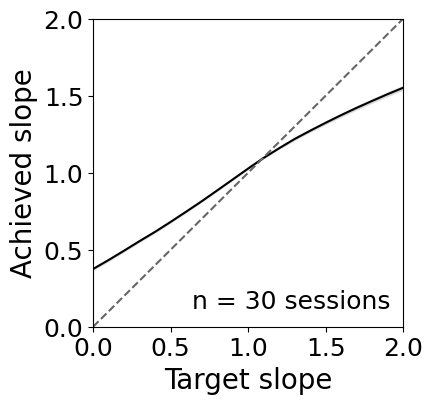

In [ ]:
# Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (sampled pseudo-data) (~15 min)

file_name = 'slopes_an_RRneuron_nbp_all.pickle'
with open(file_name, 'rb') as f:
    slopes_an_RRneuron_nbp_all = joblib.load(f)
    list_slopes_all_an_loglog_RRneuron = slopes_an_RRneuron_nbp_all['list_slopes_all_an_loglog_RRneuron'].copy()
    list_slopes_all_an_loglog_nbp50 = slopes_an_RRneuron_nbp_all['list_slopes_all_an_loglog_nbp50'].copy()
    list_slopes_all_an_loglog_nbp500 = slopes_an_RRneuron_nbp_all['list_slopes_all_an_loglog_nbp500'].copy()

n_samples = 50
file_name = 'slopes_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all.pickle' # poiss margin 0.05, binom n>=1 (50 samples)
file_name = 'slopes_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(file_name, 'rb') as f:
    slopes_an_RRneuron_nbp_all = joblib.load(f)
    list_slopes_all_an_loglog_nbpb = slopes_an_RRneuron_nbp_all['list_slopes_all_an_loglog_nbpb'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
bool_sess = ~np.isin(np.arange(num_sess), [0, 6])
list_slopes_all_an_loglog_RRneuron_temp = list_slopes_all_an_loglog_RRneuron[bool_sess]
list_slopes_all_an_loglog_nbp50_temp = list_slopes_all_an_loglog_nbpb[bool_sess] # katz50
num_sess = list_slopes_all_an_loglog_RRneuron_temp.shape[0]

x = list_slopes_all_an_loglog_RRneuron_temp[:, :, 0].flatten()
y = list_slopes_all_an_loglog_nbp50_temp[:, :, 0].flatten()

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(x, y, marker='.', color='k')

list_means_slope_fit = np.nanmean(list_slopes_all_an_loglog_nbp50_temp[:, :, 0], axis=(0, 2))
list_errs_slope_fit = sem(np.nanmean(list_slopes_all_an_loglog_nbp50_temp[:, :, 0], axis=2), axis=0, nan_policy='omit')
ax.plot(list_target_slopes, list_means_slope_fit, color='k')
ax.fill_between(list_target_slopes, list_means_slope_fit-list_errs_slope_fit, list_means_slope_fit+list_errs_slope_fit, color='k', alpha=0.1)
ax.plot(list_target_slopes, list_target_slopes, color='0.4', ls='--')

ax.set_xlabel('Target slope', fontsize=20)
ax.set_ylabel('Achieved slope', fontsize=20)
ax.tick_params('both', labelsize=18)

ax.set_xlim(0, 2)
ax.set_ylim(ax.get_xlim())
ax.set_xticks(np.arange(0, 2.1, 0.5))
ax.annotate(f'n = {num_sess} sessions', xy=(0.32, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\nbp_slope_scatter.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\nbp_slope_scatter.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_nbp_slope.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_nbp_slope.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_katz_slope.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_katz_slope.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\negbinom_katz_indep_slope.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_katz_indep_slope.png', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
# with open('resp_matrix_ep_RS_all_32sess_allensdk.pickle', 'rb') as f:
#     resp_matrix_ep_RS_all = pickle.load(f)

#     list_rate_RS = resp_matrix_ep_RS_all['list_rate_RS'].copy()
#     list_rate_RS_dr = resp_matrix_ep_RS_all['list_rate_RS_dr'].copy()
#     list_rate_all = resp_matrix_ep_RS_all['list_rate_all'].copy()
#     list_rate_all_dr = resp_matrix_ep_RS_all['list_rate_all_dr'].copy()
#     list_slopes_RS_an_loglog = resp_matrix_ep_RS_all['list_slopes_RS_an_loglog'].copy()
#     list_slopes_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_all_att_loglog'].copy()
#     list_slopes_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_all_an_loglog'].copy()
#     list_slopes_stat_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_stat_all_an_loglog'].copy()
#     list_slopes_mov_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_mov_all_an_loglog'].copy()
#     list_slopes_all_att_loglog_RRneuron = resp_matrix_ep_RS_all['list_slopes_all_att_loglog_RRneuron'].copy()

#     sess_inds_qual_RS = resp_matrix_ep_RS_all['sess_inds_qual_RS'].copy()
#     sess_inds_qual_RS_dr = resp_matrix_ep_RS_all['sess_inds_qual_RS_dr'].copy()
#     sess_inds_qual_all = resp_matrix_ep_RS_all['sess_inds_qual_all'].copy()
#     sess_inds_qual_all_dr = resp_matrix_ep_RS_all['sess_inds_qual_all_dr'].copy()

#     # print(resp_matrix_ep_RS_all['tree_variables'])

# with open('resp_matrix_ep_RS_all_32sess_allensdk.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_RS', 'list_rate_RS_dr', 'list_rate_all', 'list_rate_all_dr', 'list_slopes_RS_an_loglog', 'list_slopes_all_att_loglog', 'list_slopes_all_an_loglog',
#                                     'list_slopes_all_att_loglog_RRneuron', 'list_slopes_all_an_loglog_RRneuron', 'list_slopes_stat_all_an_loglog', 'list_slopes_mov_all_an_loglog',
#                                     'sess_inds_qual_RS', 'sess_inds_qual_RS_dr', 'sess_inds_qual_all', 'sess_inds_qual_all_dr'],
#                                     'list_rate_RS': list_rate_RS, 'list_rate_RS_dr': list_rate_RS_dr, 'list_rate_all': list_rate_all, 'list_rate_all_dr': list_rate_all_dr,
#                                     'list_slopes_RS_an_loglog': list_slopes_RS_an_loglog, 'list_slopes_all_att_loglog': list_slopes_all_att_loglog, 'list_slopes_all_an_loglog': list_slopes_all_an_loglog,
#                                     'list_slopes_all_att_loglog_RRneuron': list_slopes_all_att_loglog_RRneuron, 'list_slopes_all_an_loglog_RRneuron': list_slopes_all_an_loglog_RRneuron,
#                                     'list_slopes_stat_all_an_loglog': list_slopes_stat_all_an_loglog, 'list_slopes_mov_all_an_loglog': list_slopes_mov_all_an_loglog,
#                                     'sess_inds_qual_RS': sess_inds_qual_RS, 'sess_inds_qual_RS_dr': sess_inds_qual_RS_dr, 'sess_inds_qual_all': sess_inds_qual_all, 'sess_inds_qual_all_dr': sess_inds_qual_all_dr}, f)    

## Supplementary Figure 11d

In [65]:
# # Collect total variance for each session
# num_sess = 32
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# list_target_slopes = [0, 1, 2]
# num_trial_types = 119

# method = 'resc_r'
# use_rrep = False
# if not use_rrep: # one r for each combination of neuron and stimulus
#     method += '_rcomb'
# n_samples = 50
# # method = 'rcomb'

# list_totvar_asis = np.full((num_sess, num_trial_types), np.nan)
# list_totvar_RRneuron = np.full((num_sess, len(list_target_slopes), num_trial_types), np.nan)
# list_totvar_nbp = np.full((num_sess, len(list_target_slopes), num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'totvar_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'
#     file_name = 'totvar_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'
#     # file_name = 'totvar_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         slopes_katz_sep_RRneuron = pickle.load(f)
#         list_totvar_asis[sess_ind] = slopes_katz_sep_RRneuron['list_totvar_asis'].copy()
#         list_totvar_RRneuron[sess_ind] = slopes_katz_sep_RRneuron['list_totvar_RRneuron'].copy()
#         list_totvar_nbp[sess_ind] = slopes_katz_sep_RRneuron['list_totvar_nbp'].copy()

# save_file_name = 'totvar_katz_sep_RRneuron_' + str(n_samples) + 'samples_realR_all.pickle'
# save_file_name = 'totvar_nbp_sep_RRneuron_' + str(n_samples) + 'samples_realR_all.pickle'
# save_file_name = 'totvar_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all3.pickle'
# save_file_name = 'totvar_nb_sep_' + method + '_' + str(n_samples) + 'samples_realR_all.pickle'
# # save_file_name = 'totvar_poiss_sep_' + method + '_' + str(n_samples) + 'samples_realR_all2.pickle'
# with open(save_file_name, 'wb') as f:
#     # pickle.dump({'tree_variables': ['list_totvar_RRneuron', 'list_totvar_nbp'],
#     #              'list_totvar_RRneuron': list_totvar_RRneuron, 'list_totvar_nbp': list_totvar_nbp}, f)
#     pickle.dump({'tree_variables': ['list_totvar_asis', 'list_totvar_RRneuron', 'list_totvar_nbp'],
#                     'list_totvar_asis': list_totvar_asis, 'list_totvar_RRneuron': list_totvar_RRneuron, 'list_totvar_nbp': list_totvar_nbp}, f)

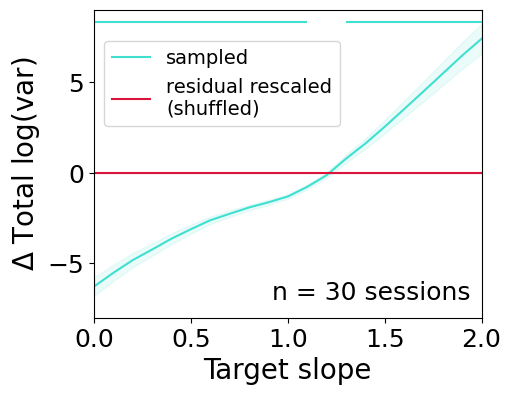

In [67]:
# RRneuron vs. RRneuron moment matching (total variance)

n_samples = 50
file_name = 'totvar_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
file_name = 'totvar_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all3.pickle' # same as above, shuffled (same as save2) (50 samples)
with open(file_name, 'rb') as f:
    totvar_katz_sep_RRneuron = pickle.load(f)
    list_totvar_asis = totvar_katz_sep_RRneuron['list_totvar_asis'].copy()
    list_totvar_RRneuron = totvar_katz_sep_RRneuron['list_totvar_RRneuron'].copy()
    list_totvar_nbp = totvar_katz_sep_RRneuron['list_totvar_nbp'].copy()

num_sess = 32
num_trial_types = 119
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
target_sess_ind = 13

# line plot of average pairwise noise correlation

list_totvar_asis_temp = list_totvar_asis
list_totvar_nbp_temp = list_totvar_nbp
list_totvar_RRneuron_temp = list_totvar_RRneuron
# subtract as-is
list_totvar_nbp_temp = list_totvar_nbp_temp - list_totvar_asis_temp[:, np.newaxis]
list_totvar_RRneuron_temp = list_totvar_RRneuron_temp - list_totvar_asis_temp[:, np.newaxis]

# exclude invalid sessions
num_sess = 32
bool_sess = ~np.isin(np.arange(num_sess), [0, 6])
list_totvar_nbp_temp = list_totvar_nbp_temp[bool_sess]
list_totvar_RRneuron_temp = list_totvar_RRneuron_temp[bool_sess]
num_sess = list_totvar_nbp_temp.shape[0]

fig, axes = plt.subplots(figsize=(5, 4))
axes = np.array(axes).flatten()

list_means_totvar = np.nanmean(list_totvar_nbp_temp, axis=(0, 2))
list_errs_totvar = sem(np.nanmean(list_totvar_nbp_temp, axis=2), axis=0, nan_policy='omit')
axes[0].plot(list_target_slopes, list_means_totvar, color='turquoise', label=f'sampled')
axes[0].fill_between(list_target_slopes, list_means_totvar-list_errs_totvar, list_means_totvar+list_errs_totvar, color='turquoise', alpha=0.1)

list_means_totvar = np.nanmean(list_totvar_RRneuron_temp, axis=(0, 2))
list_errs_totvar = sem(np.nanmean(list_totvar_RRneuron_temp, axis=2), axis=0, nan_policy='omit')
axes[0].plot(list_target_slopes, list_means_totvar, color='crimson', label=f'residual rescaled\n(shuffled)')
axes[0].fill_between(list_target_slopes, list_means_totvar-list_errs_totvar, list_means_totvar+list_errs_totvar, color='crimson', alpha=0.1)

# significance
axes[0].set_ylim(-8, 9) # katz50, sum
list_pvals_totvar = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_totvar[slope_ind] = list(wilcoxon(np.nanmean(list_totvar_nbp_temp[:, slope_ind], axis=1),
                                                 np.nanmean(list_totvar_RRneuron_temp[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_totvar = np.array(multipletests(list_pvals_totvar, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_totvar = list_target_slopes[list_pvals_totvar < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_totvar, axes=axes, ax_ind=0, line_height_ratio=0.96, color='turquoise')

axes[0].set_xlabel('Target slope', fontsize=20)
axes[0].set_ylabel(f'$\Delta$ Total log(var)', fontsize=20)
axes[0].tick_params('both', labelsize=18)
axes[0].annotate(f'n = {num_sess} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

axes[0].legend(loc='upper left', bbox_to_anchor=(0, 0.93), prop={'size': 14})
axes[0].set_xlim(0, 2)

# # plt.savefig(f'code_images\\svg\\negbinom_nbp_totvar.svg', bbox_inches='tight')
# # plt.savefig(f'code_images\\png\\negbinom_nbp_totvar.png', dpi=300, bbox_inches='tight')
# # plt.savefig(f'code_images\\svg\\negbinom_katz_totvar.svg', bbox_inches='tight')
# # plt.savefig(f'code_images\\png\\negbinom_katz_totvar.png', dpi=300, bbox_inches='tight')
# plt.savefig(f'code_images\\svg\\negbinom_katz_indep_totvar.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\negbinom_katz_indep_totvar.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 11e

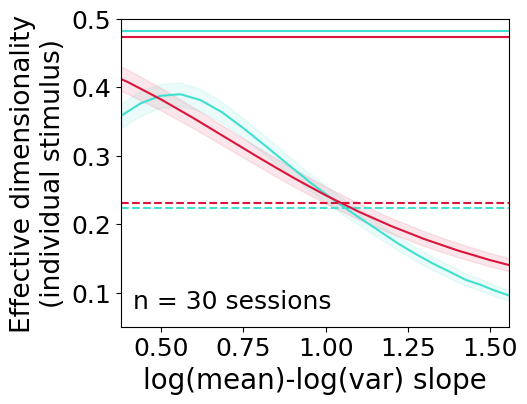

In [ ]:
# Effective dimensionality (RRneuron moment matching)

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_trial_types = 119
n_trial_sampling = 100
num_cond = 4

n_samples = 50
save_file_name = 'eff_dim_DC_ABO_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(save_file_name, 'rb') as f:
    eff_dim_DC_ABO_nb_sep = pickle.load(f)
    list_dim_asis = dc(eff_dim_DC_ABO_nb_sep['list_dim_asis2'])
    list_dim_RRneuron2 = dc(eff_dim_DC_ABO_nb_sep['list_dim_nb2'])
    list_dim_global_asis = dc(eff_dim_DC_ABO_nb_sep['list_dim_global_asis2'])
    list_dim_global_RRneuron2 = dc(eff_dim_DC_ABO_nb_sep['list_dim_global_nb2'])
    list_dim_sam_asis = dc(eff_dim_DC_ABO_nb_sep['list_dim_sam_asis2'])
    list_dim_sam_RRneuron2 = dc(eff_dim_DC_ABO_nb_sep['list_dim_sam_nb2'])

n_samples = 50
file_name = 'slopes_katz_indep_sep_RRneuron_' + str(n_samples) +  'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(file_name, 'rb') as f:
    slopes_katz_sep_RRneuron = joblib.load(f)
    list_slopes_all_an_loglog_nbp = slopes_katz_sep_RRneuron['list_slopes_all_an_loglog_nbpb'].copy()
list_slopes_all_an_loglog_nbp = np.nanmean(list_slopes_all_an_loglog_nbp[:, :, 0], axis=(0, 2)) # average across sessions and stimuli

# shuffled
save_filename = 'eff_dim_DC_ABO_shuf2.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis_shuf = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2_shuf = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis_shuf = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2_shuf = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis_shuf = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2_shuf = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

# exclude session 0, 6
mask_06 = ~np.isin(range(num_sess), [0, 6])
list_dim_asis = list_dim_asis[mask_06].copy()
list_dim_RRneuron2 = list_dim_RRneuron2[mask_06].copy()
list_dim_global_asis = list_dim_global_asis[mask_06].copy()
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[mask_06].copy()
list_dim_sam_asis = list_dim_sam_asis[mask_06].copy()
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[mask_06].copy()
list_dim_asis_shuf = list_dim_asis_shuf[mask_06].copy()
list_dim_RRneuron2_shuf = list_dim_RRneuron2_shuf[mask_06].copy()
list_dim_global_asis_shuf = list_dim_global_asis_shuf[mask_06].copy()
list_dim_global_RRneuron2_shuf = list_dim_global_RRneuron2_shuf[mask_06].copy()
list_dim_sam_asis_shuf = list_dim_sam_asis_shuf[mask_06].copy()
list_dim_sam_RRneuron2_shuf = list_dim_sam_RRneuron2_shuf[mask_06].copy()

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# 1. sampled pseudo-data

# individual manifold
list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

x = list_target_slopes
x = list_slopes_all_an_loglog_nbp
axes[0].plot(x, list_means_dim, color='turquoise', label='sampled')
axes[0].fill_between(x, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='turquoise', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis), color='turquoise', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0.05, 0.33) # individual + global (katz50)
list_pvals_dim = np.zeros(len(x))
for slope_ind, target_slope in enumerate(x):
    list_pvals_dim[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                              np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_dim = np.array(multipletests(list_pvals_dim, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim = x[list_pvals_dim < 0.05].copy()
# annotate_lineplot_significance(list_sig_slopes_dim, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')
# height = (np.mean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
# axes[0].annotate('NB fit to as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')

xlim_ = (np.min(x), np.max(x))
axes[0].set_xlim(xlim_)

# 2. shuffled

# individual manifold
list_means_dim = np.nanmean(list_dim_RRneuron2_shuf, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2_shuf, axis=2), axis=0)

x = list_target_slopes
axes[0].plot(x, list_means_dim, color='crimson', label='residual rescaled\n(shuffled)')
axes[0].fill_between(x, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='crimson', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis_shuf), color='crimson', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0.05, 0.5) # individual + global (katz50)
list_pvals_dim_shuf = np.zeros(len(x))
for slope_ind, target_slope in enumerate(x):
    list_pvals_dim_shuf[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis_shuf, axis=1),
                                              np.nanmean(list_dim_RRneuron2_shuf[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_dim_shuf = np.array(multipletests(list_pvals_dim_shuf, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim_shuf = x[list_pvals_dim_shuf < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim_shuf, axes=axes, ax_ind=0, line_height_ratio=0.94, color='crimson')
annotate_lineplot_significance(list_sig_slopes_dim, axes=axes, ax_ind=0, line_height_ratio=0.96, color='turquoise')
# height_shuf = (np.mean(list_dim_asis_shuf)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
# axes[0].annotate('as-is shuffled', xy=(0.03, height_shuf-0.08), xycoords='axes fraction', fontsize=18, color='crimson')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality', fontsize=19)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 13})
# axes[0].legend(loc='upper right', bbox_to_anchor=(1, 0.93), prop={'size': 13})

# # plt.savefig('code_images\\svg\\negbinom_nbp_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_nbp_effdim.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_nbp_effdim_indglocen.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_nbp_effdim_indglocen.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_nbp_effdim_indglo.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_nbp_effdim_indglo.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_katz_effdim_indglo.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_katz_effdim_indglo.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\negbinom_katz_indep_shuf_effdim.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_katz_indep_shuf_effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 11f

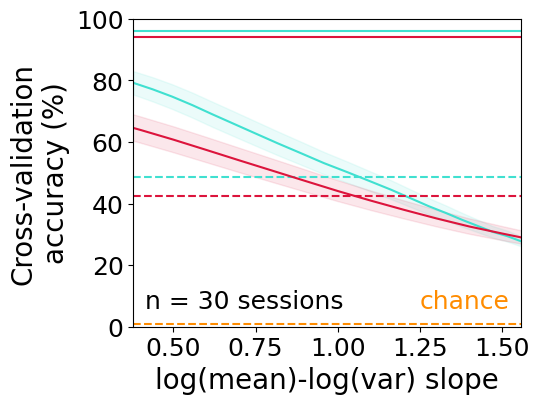

In [ ]:
# decoding plot across slopes (ABO, SVM) (RRneuron moment matching)
num_sess = 32
num_cond = 4
num_trial_types = 119
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

decoder_type = 'SVM'

n_samples = 50
save_file_name = decoder_type + '_decoding_ABO_allstim_katz_indep_sep_RRneuron_' + str(n_samples) + 'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)
    list_mean_accuracy = decoding_ABO_all['list_mean_accuracy']
    list_mean_accuracy_RRneuron2 = decoding_ABO_all['list_mean_accuracy_RRneuron2'].copy()

n_samples = 50
file_name = 'slopes_katz_indep_sep_RRneuron_' + str(n_samples) +  'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(file_name, 'rb') as f:
    slopes_katz_sep_RRneuron = joblib.load(f)
    list_slopes_all_an_loglog_nbp = slopes_katz_sep_RRneuron['list_slopes_all_an_loglog_nbpb'].copy()
list_slopes_all_an_loglog_nbp = np.nanmean(list_slopes_all_an_loglog_nbp[:, :, 0], axis=(0, 2)) # average across sessions and stimuli

# shuffled
save_file_name = decoder_type + '_decoding_ABO_allstim_shuf_all.pickle' # shuffled, trial order matched (slope 0~2), logit/SVM max_iter=1000/-1
# save_file_name = decoder_type + '_decoding_ABO_allstim_shuf_all2.pickle' # shuffled, trial order matched (slope 0~2), SVM max_iter=100
save_file_name = decoder_type + '_decoding_ABO_allstim_shuf_all3.pickle' # shuffled, trial order matched (slope 0~2), SVM max_iter=1000
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)

    # list_mean_confusion_test = dc(decoding_ABO_all['list_mean_confusion_test'])
    list_mean_accuracy_shuf = dc(decoding_ABO_all['list_mean_accuracy'])
    # list_mean_confusion_test_RRneuron2 = dc(decoding_ABO_all['list_mean_confusion_test_RRneuron2'])
    list_mean_accuracy_RRneuron2_shuf = dc(decoding_ABO_all['list_mean_accuracy_RRneuron2'])

# exclude session 0, 6
bool_sess = ~np.isin(np.arange(num_sess), [0, 6])
list_mean_accuracy = list_mean_accuracy[bool_sess] * 100
list_mean_accuracy_RRneuron2 = list_mean_accuracy_RRneuron2[:, bool_sess] * 100
list_mean_accuracy_shuf = list_mean_accuracy_shuf[bool_sess] * 100
list_mean_accuracy_RRneuron2_shuf = list_mean_accuracy_RRneuron2_shuf[:, bool_sess] * 100

num_sess = list_mean_accuracy.shape[0]

# As-is vs. RRneuron test accuracy bar graph (averaged across sessions)
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# 1. sampled pseudo-data
list_means_accuracy = np.mean(list_mean_accuracy_RRneuron2, axis=1)
list_errs_accuracy = sem(list_mean_accuracy_RRneuron2, axis=1)

x = list_target_slopes
x = list_slopes_all_an_loglog_nbp
axes[0].plot(x, list_means_accuracy, color='turquoise', label='sampled')
axes[0].fill_between(x, list_means_accuracy-list_errs_accuracy, \
                     list_means_accuracy+list_errs_accuracy, color='turquoise', alpha=0.1)

axes[0].axhline(np.mean(list_mean_accuracy), c='turquoise', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0, 100) # katz
list_pvals_RRneuron2 = np.zeros(len(x)) # test accuracy
for slope_ind, slope in enumerate(x):
    list_pvals_RRneuron2[slope_ind] = list(wilcoxon(list_mean_accuracy, list_mean_accuracy_RRneuron2[slope_ind]))[1]
list_pvals_RRneuron2 = np.array(multipletests(list_pvals_RRneuron2, method='holm')[1]) # multiple comparisons correction
# annotate_lineplot_significance(x[list_pvals_RRneuron2 < 0.05], axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

xlim_ = (np.min(x), np.max(x))
axes[0].set_xlim(xlim_)

# 2. shuffled
list_means_accuracy = np.mean(list_mean_accuracy_RRneuron2_shuf, axis=1)
list_errs_accuracy = sem(list_mean_accuracy_RRneuron2_shuf, axis=1)

x = list_target_slopes
axes[0].plot(x, list_means_accuracy, color='crimson', label='residual rescaled\n(shuffled)')
axes[0].fill_between(x, list_means_accuracy-list_errs_accuracy, \
                     list_means_accuracy+list_errs_accuracy, color='crimson', alpha=0.1)

axes[0].axhline(np.mean(list_mean_accuracy_shuf), c='crimson', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0, 100) # katz
list_pvals_RRneuron2_shuf = np.zeros(len(x)) # test accuracy
for slope_ind, slope in enumerate(x):
    list_pvals_RRneuron2_shuf[slope_ind] = list(wilcoxon(list_mean_accuracy_shuf, list_mean_accuracy_RRneuron2_shuf[slope_ind]))[1]
list_pvals_RRneuron2_shuf = np.array(multipletests(list_pvals_RRneuron2_shuf, method='holm')[1]) # multiple comparisons correction
annotate_lineplot_significance(x[list_pvals_RRneuron2_shuf < 0.05], axes=axes, ax_ind=0, line_height_ratio=0.94, color='crimson')
annotate_lineplot_significance(x[list_pvals_RRneuron2 < 0.05], axes=axes, ax_ind=0, line_height_ratio=0.96, color='turquoise')

# xlim_ = (np.min(x), np.max(x))
# axes[0].set_xlim(xlim_)
# axes[0].set_yticks(np.arange(0, 101, 25))

# height_shuf = (np.mean(list_mean_accuracy)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
# axes[0].annotate('as-is shuffled', xy=(0.03, height_shuf-0.08), xycoords='axes fraction', fontsize=18, color='crimson')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {num_sess} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
axes[0].axhline(1/num_trial_types*100, c='darkorange', linestyle='--') # chance level
axes[0].annotate(f'chance', xy=(0.74, 0.06), xycoords='axes fraction', fontsize=18, color='darkorange')
# axes[0].legend(loc='upper right', bbox_to_anchor=(1, 0.93), prop={'size': 13})

# # plt.savefig('code_images\\svg\\negbinom_nbp_decoding.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_nbp_decoding.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_katz_decoding.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_katz_decoding.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\negbinom_katz_indep_shuf_decoding.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_katz_indep_shuf_decoding.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 11g

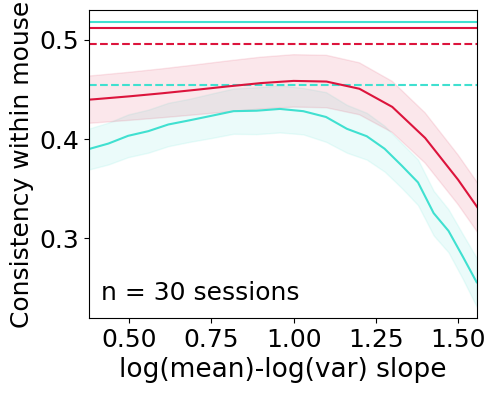

In [ ]:
# RSA within session (RRneuron moment matching)
num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_cond = 4
n_neu_sampling = 10

similarity_type = 'cos_sim'
# similarity_type = 'geodesic'
# similarity_type = 'euclidean'

n_samples = 50
save_file_name = 'RSM_corr_withinsess_ABO_katz_indep_sep_RRneuron_all_' + similarity_type + '_' + str(n_samples) + 'samples_realR2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_ABO_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3 = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'].copy()

n_samples = 50
file_name = 'slopes_katz_indep_sep_RRneuron_' + str(n_samples) +  'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(file_name, 'rb') as f:
    slopes_katz_sep_RRneuron = joblib.load(f)
    list_slopes_all_an_loglog_nbp = slopes_katz_sep_RRneuron['list_slopes_all_an_loglog_nbpb'].copy()
list_slopes_all_an_loglog_nbp = np.nanmean(list_slopes_all_an_loglog_nbp[:, :, 0], axis=(0, 2)) # average across sessions and stimuli

# shuffled
similarity_type = 'cos_sim'
save_file_name = 'RSM_corr_withinsess_ABO_shuf_all_' + similarity_type + '.pickle' # slope 0~2, including as-is, trial combination, neuron partioning matched
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_asis2_shuf = RSM_corr_withinsess_ABO_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3_shuf = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'].copy()

# exclude session 0, 6
mask_06 = ~np.isin(range(num_sess), [0, 6])
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[mask_06].copy()
list_corr_withinsess3 = list_corr_withinsess3[mask_06].copy()
list_corr_withinsess_asis2_shuf = list_corr_withinsess_asis2_shuf[mask_06].copy()
list_corr_withinsess3_shuf = list_corr_withinsess3_shuf[:, mask_06].copy()
list_corr_withinsess3_shuf = list_corr_withinsess3_shuf.transpose((1, 0, 2, 3))

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# 1. sampled pseudo-data
list_means_corr_withinsess = np.mean(list_corr_withinsess3[:, :, :, corr_ind], axis=(0, 2))
list_errs_corr_withinsess = sem(np.mean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=0)

x = list_target_slopes
x = list_slopes_all_an_loglog_nbp
axes[0].plot(x, list_means_corr_withinsess, color='turquoise', label='sampled')
axes[0].fill_between(x, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color='turquoise', alpha=0.1)

# as-is
axes[0].axhline(np.mean(list_corr_withinsess_asis2[:, :, corr_ind]), c='turquoise', linestyle='--')

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], 0.5)
list_pvals_corr_withinsess_ABO = np.full((3, len(x)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[:, slope_ind, :, corr_ind].mean(axis=1)))[1]\
                  for slope_ind in range(len(x))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess_ABO[corr_ind] = pvals_temp.copy()

corr_ind = 0
list_sig_slopes_corr_withinsess = x[list_pvals_corr_withinsess_ABO[corr_ind] < 0.05].copy()
# annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96, color='k')

xlim_ = (np.min(x), np.max(x))
axes[0].set_xlim(xlim_)

# 2. shuffled
list_means_corr_withinsess = np.mean(list_corr_withinsess3_shuf[:, :, :, corr_ind], axis=(0, 2))
list_errs_corr_withinsess = sem(np.mean(list_corr_withinsess3_shuf[:, :, :, corr_ind], axis=2), axis=0)

x = list_target_slopes
axes[0].plot(x, list_means_corr_withinsess, color='crimson', label='residual rescaled\n(shuffled)')
axes[0].fill_between(x, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color='crimson', alpha=0.1)

# as-is
axes[0].axhline(np.mean(list_corr_withinsess_asis2_shuf[:, :, corr_ind]), c='crimson', linestyle='--')

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], 0.53)
list_pvals_corr_withinsess_ABO_shuf = np.full((3, len(x)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2_shuf[:, :, corr_ind].mean(axis=1), list_corr_withinsess3_shuf[:, slope_ind, :, corr_ind].mean(axis=1)))[1]\
                  for slope_ind in range(len(x))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess_ABO_shuf[corr_ind] = pvals_temp.copy()

corr_ind = 0
list_sig_slopes_corr_withinsess_shuf = x[list_pvals_corr_withinsess_ABO_shuf[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_withinsess_shuf, axes=axes, ax_ind=0, line_height_ratio=0.94, color='crimson')
annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96, color='turquoise')

# xlim_ = (np.min(x), np.max(x))
# axes[0].set_xlim(xlim_)
# height_shuf = (np.nanmean(list_corr_withinsess_asis2_shuf[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is shuffled', xy=(0.03, height_shuf+0.03), xycoords='axes fraction', fontsize=18, color='b')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
# axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)

# axes[0].legend(loc='upper left', bbox_to_anchor=(0, 0.45), prop={'size': 13})
axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\negbinom_nbp_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_nbp_RSA_within.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_katz_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_katz_RSA_within.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\negbinom_katz_indep_shuf_RSA_within.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_katz_indep_shuf_RSA_within.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 11h

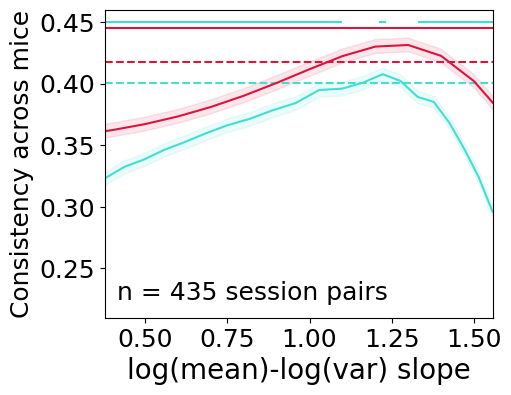

In [ ]:
# RSA across sessions (RRneuron moment matching)

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_cond = 4

similarity_type = 'cos_sim'

n_samples = 50
save_file_name = 'RSM_ABO_all_allneu_katz_indep_sep_RRneuron_' + similarity_type + '_' + str(n_samples) + 'samples_realR2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(save_file_name, 'rb') as f:
    RSM_ABO_all = pickle.load(f)
    list_corr_sesspair_asis_ABO = RSM_ABO_all['list_corr_sesspair_asis_ABO'].copy()
    list_corr_sesspair2 = RSM_ABO_all['list_corr_sesspair2'].copy()

n_samples = 50
file_name = 'slopes_katz_indep_sep_RRneuron_' + str(n_samples) +  'samples_realR_all2.pickle' # same as above, use random_state for session x neuron x stimulus (50 samples)
with open(file_name, 'rb') as f:
    slopes_katz_sep_RRneuron = joblib.load(f)
    list_slopes_all_an_loglog_nbp = slopes_katz_sep_RRneuron['list_slopes_all_an_loglog_nbpb'].copy()
list_slopes_all_an_loglog_nbp = np.nanmean(list_slopes_all_an_loglog_nbp[:, :, 0], axis=(0, 2)) # average across sessions and stimuli

# shuffled
similarity_type = 'cos_sim'
save_file_name = 'RSM_corr_sesspair_ABO_all_allneu_shuf_' + similarity_type + '.pickle' # trial order matched (slope 0~2)
with open(save_file_name, 'rb') as f:
    RSM_corr_sesspair_ABO_all = pickle.load(f)
    list_corr_sesspair_asis_ABO_shuf = RSM_corr_sesspair_ABO_all['list_corr_sesspair_asis_ABO_shuf'].copy()
    list_corr_sesspair2_shuf = RSM_corr_sesspair_ABO_all['list_corr_sesspair2_shuf'].copy()

# exclude session 0, 6
sess_pairs = np.array(list(combinations(range(num_sess), 2)))
mask_06 = ~np.any(np.isin(sess_pairs, [0, 6]), axis=1)
list_corr_sesspair_asis_ABO = list_corr_sesspair_asis_ABO[mask_06].copy()
list_corr_sesspair2 = list_corr_sesspair2[mask_06].copy()
list_corr_sesspair_asis_ABO_shuf = list_corr_sesspair_asis_ABO_shuf[mask_06].copy()
list_corr_sesspair2_shuf = list_corr_sesspair2_shuf[:, mask_06].copy()
list_corr_sesspair2_shuf = list_corr_sesspair2_shuf.transpose((1, 0, 2))

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# 1. sampled pseudo-data
list_means_corr_sesspair = np.mean(list_corr_sesspair2[:, :, corr_ind], axis=0)
list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=0)

x = list_target_slopes
x = list_slopes_all_an_loglog_nbp
axes[0].plot(x, list_means_corr_sesspair, color='turquoise', label='sampled')
axes[0].fill_between(x, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color='turquoise', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind]), c='turquoise', linestyle='--')

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], 0.43)
list_pvals_corr_sesspair_ABO = np.full((3, len(x)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_sesspair_asis_ABO[:, corr_ind], list_corr_sesspair2[:, slope_ind, corr_ind]))[1]\
                  for slope_ind in range(len(x))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_sesspair_ABO[corr_ind] = pvals_temp.copy()

corr_ind = 0
list_sig_slopes_corr_sesspair = x[list_pvals_corr_sesspair_ABO[corr_ind] < 0.05].copy()
# annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

xlim_ = (np.min(x), np.max(x))
axes[0].set_xlim(xlim_)

# 2. shuffled
list_means_corr_sesspair = np.mean(list_corr_sesspair2_shuf[:, :, corr_ind], axis=0)
list_errs_corr_sesspair = sem(list_corr_sesspair2_shuf[:, :, corr_ind], axis=0)

x = list_target_slopes
axes[0].plot(x, list_means_corr_sesspair, color='crimson', label='residual rescaled\n(shuffled)')
axes[0].fill_between(x, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color='crimson', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis_ABO_shuf[:, corr_ind]), c='crimson', linestyle='--')

# significance
axes[0].set_ylim(0.21, 0.46)
list_pvals_corr_sesspair_ABO_shuf = np.full((3, len(x)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_sesspair_asis_ABO_shuf[:, corr_ind], list_corr_sesspair2_shuf[:, slope_ind, corr_ind]))[1]\
                  for slope_ind in range(len(x))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_sesspair_ABO_shuf[corr_ind] = pvals_temp.copy()

corr_ind = 0
list_sig_slopes_corr_sesspair_shuf = x[list_pvals_corr_sesspair_ABO_shuf[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_sesspair_shuf, axes=axes, ax_ind=0, line_height_ratio=0.94, color='crimson')
annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96, color='turquoise')

# xlim_ = (np.min(x), np.max(x))
# axes[0].set_xlim(xlim_)
# axes[0].set_yticks(np.arange(0.2, 0.42, 0.1))
# axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 15})
# height_shuf = (np.nanmean(list_corr_sesspair_asis_ABO_shuf[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is shuffled', xy=(0.03, height_shuf+0.03), xycoords='axes fraction', fontsize=18, color='crimson')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
# axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)

# axes[0].legend(loc='upper left', bbox_to_anchor=(0, 0.45), prop={'size': 13})
axes[0].annotate(f'n = {list_corr_sesspair2.shape[0]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\negbinom_nbp_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_nbp_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\negbinom_katz_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\negbinom_katz_RSA_across.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\negbinom_katz_indep_shuf_RSA_across.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\negbinom_katz_indep_shuf_RSA_across.png', dpi=300, bbox_inches='tight')
plt.show()